In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt
import openml
import yaml
import tqdm
from pymoo.indicators.hv import HV
import warnings
from multiprocessing import Pool
from joblib import Parallel, delayed
from utility import compute_min_max, get_pareto_front, compute_ranks, compute_extremes, get_all_dataframes, get_group_task_ids
from colors import COLORS
from itertools import product
import gc
from concurrent.futures import ProcessPoolExecutor

COLOR_LIST = list(COLORS.values())

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
USE_CACHED_RESULTS = False
DPI = 300

# Frequency Scaling

In [3]:
data_bm = pd.read_csv('./data/base_model_pools.csv', index_col=0)
data_ens = pd.read_csv('./data/base_ensemble_pools.csv', index_col=0)

data_ens = data_ens[data_ens["filter"].isin(["nd_50_silo", "none"])]
data_ens = data_ens[data_ens["frequency"] == "no-boost"]
data_bm = data_bm[data_bm["frequency"] == "no-boost"]
data_bm = data_bm[data_bm["time"] < 0]

gc.collect()

data_fs_allotment = pd.read_csv('./data/frequency_scaling_alloted_eps.csv', index_col=0)
data_meta_fs = pd.read_csv('./data/frequency_scaling_alloted_meta.csv')


In [4]:
print(data_bm.head(n=3))
print(data_ens.head(n=3))
print(data_fs_allotment.head(n=3))

          RMSE  inference_time  energy_consumption  ensemble_size  avg_gap  task_id  seed bmg_method  pool_index   RMSE_ens  inference_time_ens  energy_consumption_ens frequency  time  Log Loss  Log Loss_ens  1 - ROC AUC  1 - ROC AUC_ens
0.0  24.667723        0.022210            0.044937            1.0      0.0   167210     1     random          35  24.366625            0.031025                0.053830  no-boost  -1.0       NaN           NaN          NaN              NaN
1.0  38.015138        0.012781            0.030975            1.0      0.0   167210     1     random          35  32.101327            0.014349                0.033884  no-boost  -1.0       NaN           NaN          NaN              NaN
2.0  27.501323        0.018855            0.041260            1.0      0.0   167210     1     random          35  25.655072            0.022069                0.045343  no-boost  -1.0       NaN           NaN          NaN              NaN
          RMSE  inference_time  energy_consumpti

In [5]:
with open("./data/classification_meta.yaml", "r") as f:
    meta = yaml.safe_load(f)
with open("./data/regression_meta.yaml", "r") as f:
    meta.update(yaml.safe_load(f))
TASK_IDS = list(meta.keys())
SEEDS = [1, 2, 3, 4, 5]

In [6]:
BMG_METHODS_DICT = {
    "random" : "Random Search",
    "nsga2" : "NSGA-II",
    "so-smac" : "SO-SMAC",
    "mo-smac" : "MO-SMAC",
    "so-asha" : "SO-ASHA",
    "mo-asha" : "MO-ASHA",
}
BMG_METHODS = list(BMG_METHODS_DICT.keys())

ENSEMBLING_METHODS_DICT = {
    "ges" : "GES",
    "mo-ges" : "MO-GES",
    "qdo-es" : "QDO-ES",
    "infer-qdo-es" : "Infer-QDO-ES",
    "size-qdo-es" : "Size-QDO-ES",
    "energy-qdo-es" : "Energy-QDO-ES",
}
ENSEMBLING_METHODS = list(ENSEMBLING_METHODS_DICT.keys())

ALLOTMENT_STRATEGIES_DICT = {
    "full" : "FFS",
    "nsga2" : "NSGA-II-FS",
}
ALLOTMENT_STRATEGIES = list(ALLOTMENT_STRATEGIES_DICT.keys())

SCHEDULING_STRATEGIES_DICT = {
    "lpt" : "LPT",
    "hws" : "HWL",
    "htcs" : "HCC",
}
SCHEDULING_STRATEGIES = list(SCHEDULING_STRATEGIES_DICT.keys())

In [7]:
if not os.path.exists("./data/processed_data"):
    os.makedirs("./data/processed_data")

if os.path.exists("./data/processed_data/min_max.yaml"):
    with open("./data/processed_data/min_max.yaml", "r") as f:
        min_max_values = yaml.safe_load(f)
else:
    all_df = get_all_dataframes()
    min_max_values = compute_min_max(all_df)
    with open("./data/processed_data/min_max.yaml", "w") as f:
        yaml.dump(min_max_values, f)
    del all_df
assert len(min_max_values) == 104

In [8]:
if os.path.exists("./data/processed_data/extremes.yaml"):
    with open("./data/processed_data/extremes.yaml", "r") as f:
        extremes = yaml.safe_load(f)
else:
    all_df = get_all_dataframes()
    extremes = compute_extremes(min_max_values, all_df)
    with open("./data/processed_data/extremes.yaml", "w") as f:
        yaml.dump(extremes, f)
    del all_df
assert len(extremes) == 104

In [9]:
data_bm_grouped = data_bm.groupby(["task_id", "seed", "bmg_method"])
data_ens_grouped = data_ens.groupby(["task_id", "seed", "bmg_method", "es_method"])
data_fs_grouped = data_fs_allotment.groupby(["task_id", "seed", "bmg_method", "ensembling_method", "allotment_method"])

In [10]:
def min_distance(vectors, paret_front, ignore_self=False):
    diff = vectors[:, None, :] - paret_front[None, :, :]
    dist = np.linalg.norm(diff, axis=2)
    if ignore_self:
        np.fill_diagonal(dist, np.inf)
    return np.min(dist, axis=1)

def compute_spread(extent, sum_deviations, denom):
    assert np.isfinite(extent) and np.isfinite(sum_deviations) and np.isfinite(denom), "Values must be finite"
    return (extent + sum_deviations) / (extent + denom)

def compute_extent(pareto_front, cols, extremes):
    extremes_array = np.array([[e[col] for col in cols] for e in extremes.values()])
    sum_extremes = np.sum(min_distance(extremes_array, pareto_front))
    return sum_extremes

def compute_uniformity_components(pareto_front, cols):
    assert len(pareto_front) > 0, "Pareto front is empty"
    if len(pareto_front) == 1:
        return 1.0, 1.0 

    distances = min_distance(pareto_front, pareto_front, ignore_self=True)
    assert not np.any(np.isinf(distances)), "Distances contain infinity"
        
    d_mean = np.mean(distances)
    assert np.abs(d_mean) >= 1e-14, "Mean distance is too small"

    sum_deviations = np.sum(np.abs(distances - d_mean))
    return sum_deviations, len(pareto_front) * d_mean

def compute_uniformity(sum_deviations, denom):
    return sum_deviations / denom


def filter_duplicates(arr):
    unique = []
    for row in arr:
        if not any(np.abs(row - u).sum() < 1e-6 for u in unique):
            unique.append(row)
    return np.array(unique)

def compute_hvs(data, log_mask, min_arr, max_arr):
    ind = HV(ref_point=[1] * 3)
    data_norm = (data - min_arr) / (max_arr - min_arr)
    hv = ind(data_norm)
    
    data_log_scaled = data.copy()
    data_log_scaled[:, log_mask] = np.log10(data_log_scaled[:, log_mask] + 1e-10)
    min_arr_log = min_arr.copy()
    min_arr_log[log_mask] = np.log10(min_arr_log[log_mask] + 1e-10)
    max_arr_log = max_arr.copy()
    max_arr_log[log_mask] = np.log10(max_arr_log[log_mask] + 1e-10)
    data_log_norm = (data_log_scaled - min_arr_log) / (max_arr_log - min_arr_log)
    hv_log = ind(data_log_norm)
    return hv, hv_log, data_norm

In [11]:
def compute_metrics_for_data(data, min_arr, max_arr, cols, extremes, task_id, log_mask):
    data_orig = data.copy()
    
    hv, hv_log, data = compute_hvs(data, log_mask, min_arr, max_arr)
    
    data_pareto_mask = get_pareto_front(data)
    data_pareto = data[data_pareto_mask]
    data_pareto = filter_duplicates(data_pareto)
    
    data_extent = compute_extent(data_pareto, cols, extremes[task_id])
    data_sum_deviations, data_denom = compute_uniformity_components(data_pareto, cols)
    data_spread = compute_spread(data_extent, data_sum_deviations, data_denom)
    data_uniformity = compute_uniformity(data_sum_deviations, data_denom)
    
    data_n = len(data)
    data_onvg = len(data_pareto)
    
    return hv, hv_log, data_spread, data_onvg, data_n, data_uniformity, data_extent, data_orig

In [12]:
def process_job(task_id, seed, bmg_method):
    results = []
    try:
        bm_group = data_bm_grouped.get_group((task_id, seed, bmg_method))
    except KeyError:
        for ensembling_method in ENSEMBLING_METHODS:
            for allotment_method in ALLOTMENT_STRATEGIES:
                results.append([
                    task_id, seed, bmg_method, ensembling_method, allotment_method,
                    [*([0]*8), *([np.nan]*4), *([0]*8),  *([np.nan]*4), *([np.nan]*4)]
                ])
        return results
    
    cols = ["RMSE", "Log Loss", "1 - ROC AUC", "inference_time", "energy_consumption"]
    cols = [col for col in cols if (~bm_group[col].isna()).sum() > 0]
    log_mask = [1,2]
    
    cols_ens = [f"{c}_ens" for c in cols]
    
    assert bm_group["pool_index"].nunique() == 1, "Multiple pools found"

    min, max = min_max_values[task_id]
    min_arr, max_arr = np.array([min[col] for col in cols]), np.array([max[col] for col in cols])
    
    bm_data = bm_group[cols].values
    bm_data_pareto_ens = get_pareto_front(bm_group[cols_ens].values)
    bm_data_pareto_ens_indicies = np.where(bm_data_pareto_ens)[0]
    bm_data = bm_data[bm_data_pareto_ens]
    
    bm_hv, bm_hv_log, bm_spread, bm_onvg, bm_n, bm_uniformity, bm_extent, bm_data_orig = compute_metrics_for_data(
        bm_data, min_arr, max_arr, cols, extremes, task_id, log_mask
    )
    
    bm_allotment_group = data_fs_grouped.get_group((task_id, seed, bmg_method, "base_model_pool", "full"))
    bm_allotment_group_filtered = bm_allotment_group[bm_allotment_group["old_ensemble_index"].astype(int).isin(bm_data_pareto_ens_indicies)] 
    bm_a_hv, bm_a_hv_log, bm_a_spread, bm_a_onvg, bm_a_n, bm_a_uniformity, bm_a_extent, bm_a_data_orig = compute_metrics_for_data(
        bm_allotment_group_filtered[cols].values, min_arr, max_arr, cols, extremes, task_id, log_mask
    )
    
    for ensembling_method in ENSEMBLING_METHODS:
        try:
            ens_group = data_ens_grouped.get_group((task_id, seed, bmg_method, ensembling_method))
        except KeyError:
            for allotment_method in ALLOTMENT_STRATEGIES:
                results.append([
                    task_id, seed, bmg_method, ensembling_method, allotment_method,
                    [
                        bm_hv, bm_hv, bm_a_hv, bm_a_hv,
                        bm_hv_log, bm_hv_log, bm_a_hv_log, bm_a_hv_log,
                        bm_spread, bm_spread, bm_a_spread, bm_a_spread,
                        bm_onvg, bm_onvg, bm_a_onvg, bm_a_onvg,
                        bm_n, bm_n, bm_a_n, bm_a_n,
                        bm_uniformity, bm_uniformity, bm_a_uniformity, bm_a_uniformity,
                        bm_extent, bm_extent, bm_a_extent, bm_a_extent,
                    ]                     
                ])
            continue
            
        ens_data = ens_group[cols].values
        ens_data_pareto_ens = get_pareto_front(ens_group[cols_ens].values)
        ens_data_pareto_ens_indices = np.where(ens_data_pareto_ens)[0]
        ens_data = ens_data[ens_data_pareto_ens]
        
        data_bm_ens = np.vstack([bm_data_orig, ens_data])
        bm_ens_hv, bm_ens_hv_log, bm_ens_spread, bm_ens_onvg, bm_ens_n, bm_ens_uniformity, bm_ens_extent, _ = compute_metrics_for_data(
            data_bm_ens, min_arr, max_arr, cols, extremes, task_id, log_mask
        )
            
        for allotment_method in ALLOTMENT_STRATEGIES:
            data_ens_allotment_group = data_fs_grouped.get_group((task_id, seed, bmg_method, ensembling_method, allotment_method))
            data_ens_allotment_group_filtered = data_ens_allotment_group[data_ens_allotment_group["old_ensemble_index"].astype(int).isin(ens_data_pareto_ens_indices)]
            
            data_bm_ens_a = np.vstack([bm_a_data_orig, data_ens_allotment_group_filtered[cols].values])
            bm_ens_a_hv, bm_ens_a_hv_log, bm_ens_a_spread, bm_ens_a_onvg, bm_ens_a_n, bm_ens_a_uniformity, bm_ens_a_extent, _ = compute_metrics_for_data(
                data_bm_ens_a, min_arr, max_arr, cols, extremes, task_id, log_mask
            )
            
            results.append([
                task_id, seed, bmg_method, ensembling_method, allotment_method,
                [
                    bm_hv, bm_ens_hv, bm_a_hv, bm_ens_a_hv,
                    bm_hv_log, bm_ens_hv_log, bm_a_hv_log, bm_ens_a_hv_log,
                    bm_spread, bm_ens_spread, bm_a_spread, bm_ens_a_spread,
                    bm_onvg, bm_ens_onvg, bm_a_onvg, bm_ens_a_onvg,
                    bm_n, bm_ens_n, bm_a_n, bm_ens_a_n,
                    bm_uniformity, bm_ens_uniformity, bm_a_uniformity, bm_ens_a_uniformity,
                    bm_extent, bm_ens_extent, bm_a_extent, bm_ens_a_extent,
                ]
            ])
            
    return results

In [13]:
METRICS_ORDER = [
    "hv_bmp", "hv_bmp+ens", "hv_bmp_allotment", "hv_bmp+ens_allotment",
    "hv_log_bmp", "hv_log_bmp+ens", "hv_log_bmp_allotment", "hv_log_bmp+ens_allotment",
    "spread_bmp", "spread_bmp+ens", "spread_bmp_allotment", "spread_bmp+ens_allotment",
    "onvg_bmp", "onvg_bmp+ens", "onvg_bmp_allotment", "onvg_bmp+ens_allotment",
    "n_bmp", "n_bmp+ens", "n_bmp_allotment", "n_bmp+ens_allotment",
    "uniformity_bmp", "uniformity_bmp+ens", "uniformity_bmp_allotment", "uniformity_bmp+ens_allotment",
    "extent_bmp", "extent_bmp+ens", "extent_bmp_allotment", "extent_bmp+ens_allotment",
]

results_fs = np.zeros((len(TASK_IDS), len(SEEDS), len(BMG_METHODS), len(ENSEMBLING_METHODS), len(ALLOTMENT_STRATEGIES), len(METRICS_ORDER)))  # last dimension for metrics

def process_wrapper(args):
    task_id, seed, bmg_method = args
    res = process_job(task_id, seed, bmg_method)
    return res

if os.path.exists("./data/processed_data/fs_allot_processed.npy") and USE_CACHED_RESULTS:
    results_fs = np.load("./data/processed_data/fs_allot_processed.npy")
else:
    jobs = list(product(TASK_IDS, SEEDS, BMG_METHODS))
    
    with ProcessPoolExecutor(max_workers=12) as executor:
        for results_list in tqdm.tqdm(
            executor.map(process_wrapper, jobs),
            total=len(jobs)
        ):
            for result in results_list:
                task_id, seed, bmg_method, ensembling_method, allotment_method, metrics = result
                t_idx = TASK_IDS.index(task_id)
                s_idx = SEEDS.index(seed)
                bmg_idx = BMG_METHODS.index(bmg_method)
                ens_idx = ENSEMBLING_METHODS.index(ensembling_method)
                allot_idx = ALLOTMENT_STRATEGIES.index(allotment_method)
                results_fs[t_idx, s_idx, bmg_idx, ens_idx, allot_idx, :] = np.array(metrics)

    # for job in tqdm.tqdm(jobs):
    #     results_list = process_wrapper(job)
    #     for result in results_list:
    #         task_id, seed, bmg_method, ensembling_method, allotment_method, metrics = result
    #         t_idx = TASK_IDS.index(task_id)
    #         s_idx = SEEDS.index(seed)
    #         bmg_idx = BMG_METHODS.index(bmg_method)
    #         ens_idx = ENSEMBLING_METHODS.index(ensembling_method)
    #         allot_idx = ALLOTMENT_STRATEGIES.index(allotment_method)
    #         results_fs[t_idx, s_idx, bmg_idx, ens_idx, allot_idx, :] = np.array(metrics)
            
    
    np.save("./data/processed_data/fs_allot_processed.npy", results_fs)

100%|██████████| 3120/3120 [00:17<00:00, 175.93it/s]


In [14]:
for i, metric in enumerate(METRICS_ORDER):
    arr = results_fs[..., i]
    print(f"For metric {metric}, {np.sum(np.isfinite(arr)) / np.prod(arr.shape)*100:.3f} % values are finite")

For metric hv_bmp, 100.000 % values are finite
For metric hv_bmp+ens, 100.000 % values are finite
For metric hv_bmp_allotment, 100.000 % values are finite
For metric hv_bmp+ens_allotment, 100.000 % values are finite
For metric hv_log_bmp, 100.000 % values are finite
For metric hv_log_bmp+ens, 100.000 % values are finite
For metric hv_log_bmp_allotment, 100.000 % values are finite
For metric hv_log_bmp+ens_allotment, 100.000 % values are finite
For metric spread_bmp, 99.808 % values are finite
For metric spread_bmp+ens, 99.808 % values are finite
For metric spread_bmp_allotment, 99.808 % values are finite
For metric spread_bmp+ens_allotment, 99.808 % values are finite
For metric onvg_bmp, 100.000 % values are finite
For metric onvg_bmp+ens, 100.000 % values are finite
For metric onvg_bmp_allotment, 100.000 % values are finite
For metric onvg_bmp+ens_allotment, 100.000 % values are finite
For metric n_bmp, 100.000 % values are finite
For metric n_bmp+ens, 100.000 % values are finite
For 

In [15]:
for i_task in range(len(TASK_IDS)):
    arr = results_fs[i_task]

    for metric in [
        "spread_bmp", "spread_bmp+ens", "spread_bmp_allotment", "spread_bmp+ens_allotment",
        "uniformity_bmp", "uniformity_bmp+ens", "uniformity_bmp_allotment", "uniformity_bmp+ens_allotment",
        "extent_bmp", "extent_bmp+ens", "extent_bmp_allotment", "extent_bmp+ens_allotment",
    ]:
        # For empty ensemble pools, use max value imputation
        mask = ~np.isfinite(arr[..., METRICS_ORDER.index(metric)])
        max_val = np.nanmax(arr[..., METRICS_ORDER.index(metric)][~mask])
        results_fs[i_task,..., METRICS_ORDER.index(metric)][mask] = max_val


In [16]:
for i, metric in enumerate(METRICS_ORDER):
    arr = results_fs[..., i]
    print(f"For metric {metric}, {np.sum(np.isfinite(arr)) / np.prod(arr.shape)*100:.3f} % values are finite")

For metric hv_bmp, 100.000 % values are finite
For metric hv_bmp+ens, 100.000 % values are finite
For metric hv_bmp_allotment, 100.000 % values are finite
For metric hv_bmp+ens_allotment, 100.000 % values are finite
For metric hv_log_bmp, 100.000 % values are finite
For metric hv_log_bmp+ens, 100.000 % values are finite
For metric hv_log_bmp_allotment, 100.000 % values are finite
For metric hv_log_bmp+ens_allotment, 100.000 % values are finite
For metric spread_bmp, 100.000 % values are finite
For metric spread_bmp+ens, 100.000 % values are finite
For metric spread_bmp_allotment, 100.000 % values are finite
For metric spread_bmp+ens_allotment, 100.000 % values are finite
For metric onvg_bmp, 100.000 % values are finite
For metric onvg_bmp+ens, 100.000 % values are finite
For metric onvg_bmp_allotment, 100.000 % values are finite
For metric onvg_bmp+ens_allotment, 100.000 % values are finite
For metric n_bmp, 100.000 % values are finite
For metric n_bmp+ens, 100.000 % values are finite


In [17]:
METRIC_MAP = {
    "hv": "Hypervolume",
    "hv_log": "Hypervolume (log)",
    "spread": "Spread",
    "onvg": "ONVG",
    "n": "Number of Solutions",
    "uniformity": "Uniformity",
    "extent": "Extent",
}

In [18]:
def plot_fs(metric_name="hv", bmp=None, metric_rename=None, save_path=None):
    metric_indices = [METRICS_ORDER.index(f"{metric_name}_{x}") for x in ["bmp", "bmp+ens", "bmp_allotment", "bmp+ens_allotment"]]
    
    all_groups = []
    for ensembling_method in ENSEMBLING_METHODS:
        data = np.zeros((results_fs.shape[0] * (results_fs.shape[2] if bmp is None else 1), 2+len(ALLOTMENT_STRATEGIES)))  
        for i_allot, allotment_strategy in enumerate(ALLOTMENT_STRATEGIES):
            ens_idx = ENSEMBLING_METHODS.index(ensembling_method)
            data_ens = results_fs[:, :, :, ens_idx, i_allot, metric_indices]  # Shape: 104, 5, 6, 4
            data_ens = data_ens.mean(axis=1)  # Average over seeds -> Shape: 104, 6, 4
            if bmp is not None:
                bmg_idx = BMG_METHODS.index(bmp)
                data_ens = data_ens[:, bmg_idx, :]  # Shape: 104, 4
            else:
                data_ens = data_ens.reshape((-1, 4))
                
            data_ens_rel = data_ens[:, 1:] / (data_ens[:, 0:1] + 1e-12) - 1
            
            if i_allot == 0:
                data[:,:3] = data_ens_rel
            if i_allot == 1:
                data[:,3:] = data_ens_rel[:,2:]
        
        all_groups.append(data)
    
    # ---- Boxplot ----
    fig, ax = plt.subplots(figsize=(8, 6))

    # Prepare data for grouped boxplot
    num_groups = len(all_groups)              # = len(ENSEMBLING_METHODS)
    num_boxes_per_group = all_groups[0].shape[1]   # = 2 allotment strategies
    positions = []
    plot_data = []

    spacing = 3     # spacing between groups
    width = 0.6     # box-width spacing inside group

    group_names = ["BMP + Ensembling", "BMP + Allotment (FFS)", "BMP + Ensembling + Allotment (FFS)", "BMP + Ensembling + Allotment (NSGA-II-FS)"]
    group_colors = [COLOR_LIST[i] for i in range(num_groups)]

    for gi, group_data in enumerate(all_groups):
        base = gi * spacing
        for bi in range(num_boxes_per_group):
            positions.append(base + bi * width)
            plot_data.append(group_data[:, bi] * 100)

    bp = ax.boxplot(plot_data, positions=positions, widths=0.5, showfliers=False, patch_artist=True)
    
    # Color each box according to its member index (bi)
    for i, box in enumerate(bp['boxes']):
        member_idx = i % num_boxes_per_group
        color = group_colors[member_idx]
        box.set_facecolor(color)
        box.set_edgecolor("black")
        
    # Match whiskers, caps, and medians
    for i, whisker in enumerate(bp['whiskers']):
        member_idx = (i // 2) % num_boxes_per_group
        whisker.set_color("black")
    for i, cap in enumerate(bp['caps']):
        member_idx = (i // 2) % num_boxes_per_group
        cap.set_color("black")
    for i, median in enumerate(bp['medians']):
        member_idx = i % num_boxes_per_group
        median.set_color("black")

    group_centers = [
        np.mean(positions[i * num_boxes_per_group:(i + 1) * num_boxes_per_group])
        for i in range(num_groups)
    ]

    ax.set_xticks(group_centers)
    ax.set_xticklabels(
        [ENSEMBLING_METHODS_DICT[e] for e in ENSEMBLING_METHODS],
        rotation=45
    )
    
    import matplotlib.patches as mpatches

    legend_patches = [mpatches.Patch(facecolor=color, label=name) for color, name in zip(group_colors, group_names)]

    ax.legend(handles=legend_patches, fontsize=11)

    ax.set_ylabel(f"Relative {METRIC_MAP[metric_name] if metric_rename is None else metric_rename} Improvement\nover Base Model Pool [%]")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=DPI, bbox_inches='tight')
    else:
        plt.show()

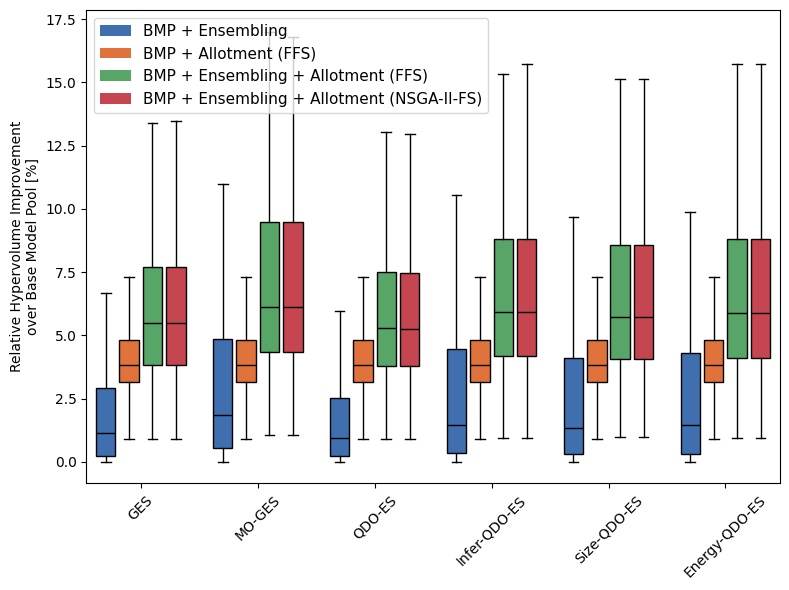

In [19]:
plot_fs("hv_log", metric_rename="Hypervolume", save_path="./figures/fs/fs_allot_hv.pdf")

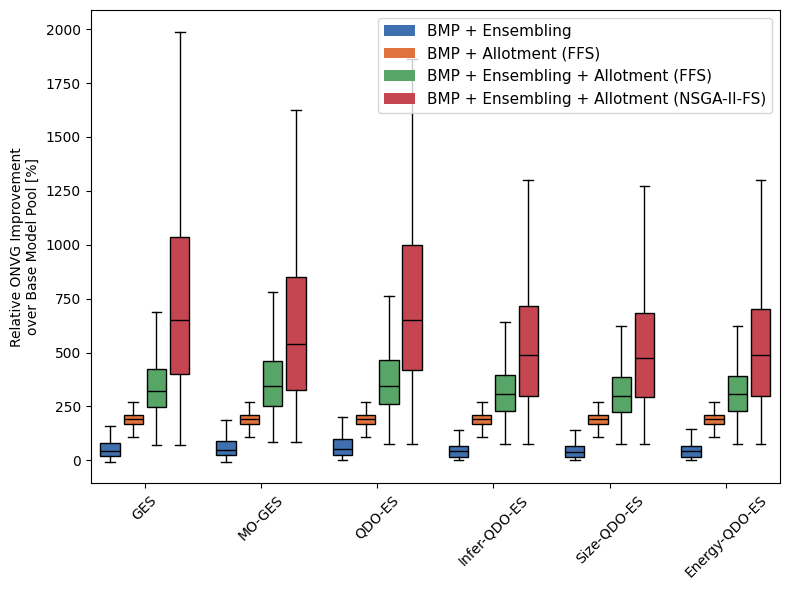

In [20]:
plot_fs("onvg", save_path="./figures/fs/fs_allot_onvg.pdf")

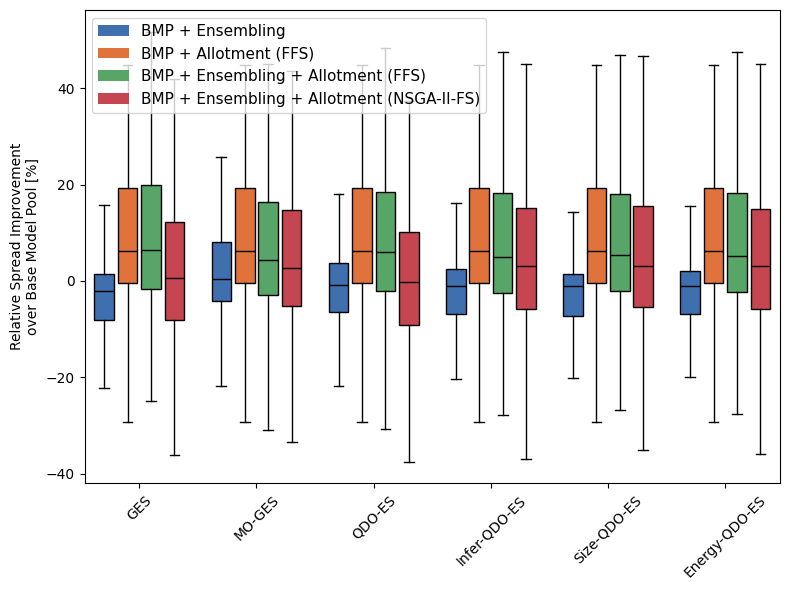

In [21]:
plot_fs("spread")

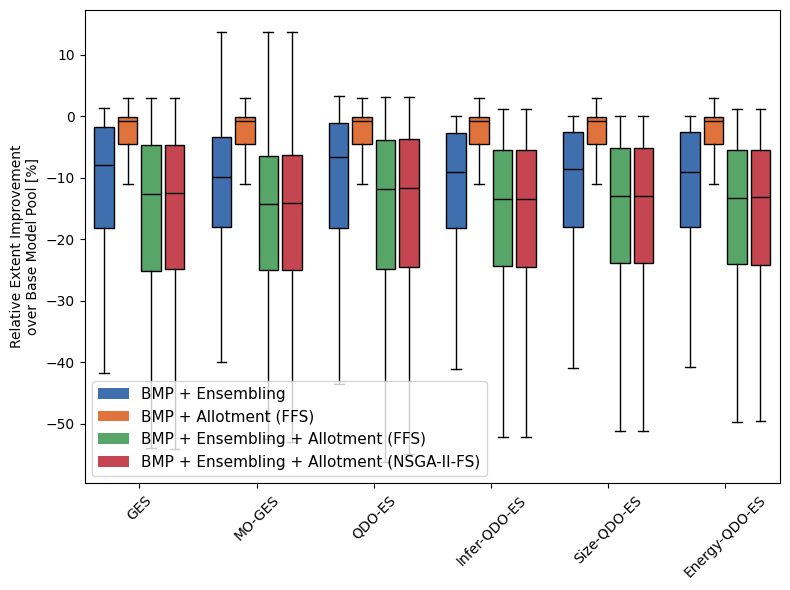

In [22]:
plot_fs("extent")

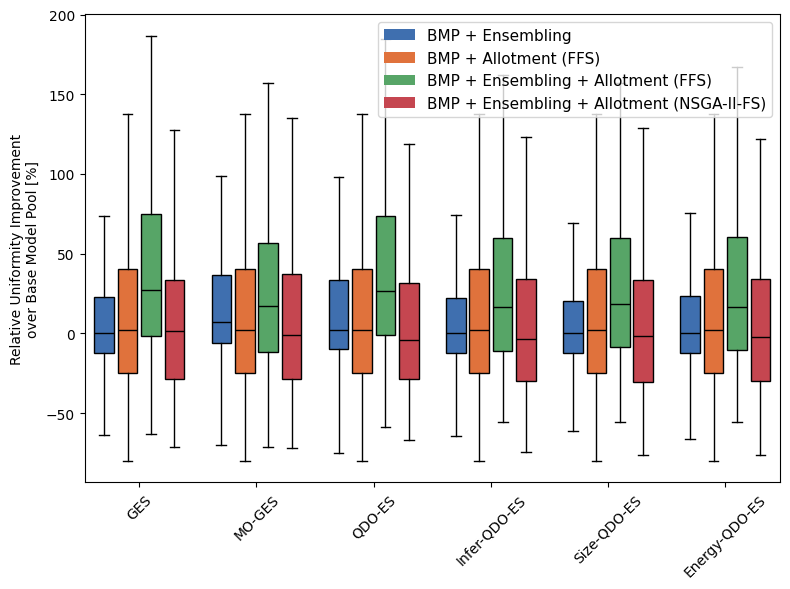

In [23]:
plot_fs("uniformity")

# Parallelization

In [24]:
data_parallel = pd.read_csv('./data/parallel_alloted_eps.csv', index_col=0)
data_parallel_grouped = data_parallel.groupby(["task_id", "seed", "bmg_method", "ensembling_method", "allotment_method","n_cores","scheduler"])

In [25]:
def process_job(task_id, seed, bmg_method):
    results = []
    df_comp_data = []
    
    try:
        bm_group = data_bm_grouped.get_group((task_id, seed, bmg_method))
    except KeyError:
        for ensembling_method in ENSEMBLING_METHODS:
            for n_cores in [2,4,8]:
                for allotment_method in ALLOTMENT_STRATEGIES:
                    for scheduler in ["lpt", "hws", "htcs"] if allotment_method == "nsga2" else ["lpt"]:
                        results.append([
                            task_id, seed, bmg_method, ensembling_method, allotment_method, n_cores, scheduler,
                            [*([0]*8), *([np.nan]*4), *([0]*8),  *([np.nan]*4), *([np.nan]*4), *([0]*4)]
                        ])
        return results, []
    
    cols = ["RMSE", "Log Loss", "1 - ROC AUC", "inference_time", "energy_consumption"]
    cols = [col for col in cols if (~bm_group[col].isna()).sum() > 0]
    log_mask = [1,2]
    
    cols_ens = [f"{c}_ens" for c in cols]
    
    assert bm_group["pool_index"].nunique() == 1, "Multiple pools found"

    min, max = min_max_values[task_id]
    min_arr, max_arr = np.array([min[col] for col in cols]), np.array([max[col] for col in cols])
    
    bm_data = bm_group[cols].values
    bm_data_pareto_ens = get_pareto_front(bm_group[cols_ens].values)
    bm_data_pareto_ens_indices = np.where(bm_data_pareto_ens)[0]
    bm_data = bm_data[bm_data_pareto_ens]
    
    bm_hv, bm_hv_log, bm_spread, bm_onvg, bm_n, bm_uniformity, bm_extent, bm_data_orig = compute_metrics_for_data(
        bm_data, min_arr, max_arr, cols, extremes, task_id, log_mask
    )
    bm_avg_gap = np.mean(bm_group["avg_gap"])
    
    
    for ensembling_method in ENSEMBLING_METHODS:
        try:
            ens_group = data_ens_grouped.get_group((task_id, seed, bmg_method, ensembling_method))
        except KeyError:
            for n_cores in [2,4,8]:
                for allotment_method in ALLOTMENT_STRATEGIES:
                    for scheduler in ["lpt", "hws", "htcs"] if allotment_method == "nsga2" else ["lpt"]:
                        results.append([
                            task_id, seed, bmg_method, ensembling_method, allotment_method, n_cores, scheduler,
                            [
                                bm_hv, bm_hv, bm_hv, bm_hv,
                                bm_hv_log, bm_hv_log, bm_hv_log, bm_hv_log,
                                bm_spread, bm_spread, bm_spread, bm_spread,
                                bm_onvg, bm_onvg, bm_onvg, bm_onvg,
                                bm_n, bm_n, bm_n, bm_n,
                                bm_uniformity, bm_uniformity, bm_uniformity, bm_uniformity,
                                bm_extent, bm_extent, bm_extent, bm_extent,
                                bm_avg_gap, bm_avg_gap, bm_avg_gap, bm_avg_gap
                            ]                     
                        ])
            continue
        
        data_ens = ens_group[cols].values
        data_ens_pareto_ens = get_pareto_front(ens_group[cols_ens].values)
        data_ens_pareto_ens_indicies = np.where(data_ens_pareto_ens)[0]
        data_ens = data_ens[data_ens_pareto_ens]
        
        data_bm_ens = np.vstack([bm_data_orig, data_ens])
        bm_ens_hv, bm_ens_hv_log, bm_ens_spread, bm_ens_onvg, bm_ens_n, bm_ens_uniformity, bm_ens_extent, _ = compute_metrics_for_data(
            data_bm_ens, min_arr, max_arr, cols, extremes, task_id, log_mask
        )
        bm_ens_avg_gap = np.mean(ens_group["avg_gap"])
            
        for n_cores in [2,4,8]:
            #data_for_comp = {}
            for allotment_method in ALLOTMENT_STRATEGIES:
                for scheduler in ["lpt", "hws", "htcs"] if allotment_method == "nsga2" else ["lpt"]:
                    bm_allotment_group = data_parallel_grouped.get_group((task_id, seed, bmg_method, "base_model_pool", allotment_method, n_cores, scheduler))  
                    bm_allotment_group_filtered = bm_allotment_group[bm_allotment_group["old_ensemble_index"].astype(int).isin(bm_data_pareto_ens_indices)]
                    bm_a_hv, bm_a_hv_log, bm_a_spread, bm_a_onvg, bm_a_n, bm_a_uniformity, bm_a_extent, bm_a_data_orig = compute_metrics_for_data(
                        bm_allotment_group_filtered[cols].values, min_arr, max_arr, cols, extremes, task_id, log_mask
                    )
                    bm_a_avg_gap = np.mean(bm_allotment_group["avg_gap"])
                    
                    data_ens_allotment_group = data_parallel_grouped.get_group((task_id, seed, bmg_method, ensembling_method, allotment_method, n_cores, scheduler))
                    data_ens_allotment_group_filtered = data_ens_allotment_group[
                        data_ens_allotment_group["old_ensemble_index"].astype(int).isin(data_ens_pareto_ens_indicies)
                    ]
                    data_bm_ens_a = np.vstack([bm_a_data_orig, data_ens_allotment_group_filtered[cols].values])
                    bm_ens_a_hv, bm_ens_a_hv_log, bm_ens_a_spread, bm_ens_a_onvg, bm_ens_a_n, bm_ens_a_uniformity, bm_ens_a_extent, _ = compute_metrics_for_data(
                        data_bm_ens_a, min_arr, max_arr, cols, extremes, task_id, log_mask
                    )
                    bm_ens_a_avg_gap = np.mean(data_ens_allotment_group["avg_gap"])
                    
                    if scheduler == "lpt":
                        df_comp_data.append({
                            "task_id": task_id,
                            "seed": seed,
                            "bmg_method": bmg_method,
                            "ensembling_method": ensembling_method,
                            "allotment_method": allotment_method,
                            "n_cores": n_cores,
                            "data_ens": data_ens_allotment_group_filtered,
                            "data_bm": bm_allotment_group_filtered
                        })
                        #data_for_comp[allotment_method] = data_ens_allotment_group
                    
                    results.append([
                        task_id, seed, bmg_method, ensembling_method, allotment_method, n_cores, scheduler,
                        [
                            bm_hv, bm_ens_hv, bm_a_hv, bm_ens_a_hv,
                            bm_hv_log, bm_ens_hv_log, bm_a_hv_log, bm_ens_a_hv_log,
                            bm_spread, bm_ens_spread, bm_a_spread, bm_ens_a_spread,
                            bm_onvg, bm_ens_onvg, bm_a_onvg, bm_ens_a_onvg,
                            bm_n, bm_ens_n, bm_a_n, bm_ens_a_n,
                            bm_uniformity, bm_ens_uniformity, bm_a_uniformity, bm_ens_a_uniformity,
                            bm_extent, bm_ens_extent, bm_a_extent, bm_ens_a_extent,
                            bm_avg_gap, bm_ens_avg_gap, bm_a_avg_gap, bm_ens_a_avg_gap
                        ]
                    ])
            
            # full_data = data_for_comp["full"].copy()
            # full_data["old_ensemble_index"] = full_data["old_ensemble_index"].astype(int)
            # nsga2_data = data_for_comp["nsga2"].copy()
            # nsga2_data["old_ensemble_index"] = nsga2_data["old_ensemble_index"].astype(int)
            # full_data_grouped = full_data.groupby("old_ensemble_index")
            # nsga2_data_grouped = nsga2_data.groupby("old_ensemble_index")
            
            # for ensemble_index in full_data_grouped.groups.keys():
            #     full_group = full_data_grouped.get_group(ensemble_index)
            #     nsga2_group = nsga2_data_grouped.get_group(ensemble_index)
            #     ensemble_size = full_group["ensemble_size"].iloc[0]
                
            #     n_dominated, inf_time_imps, energy_imps, finds_equal = compare_full_nsga2(full_group, nsga2_group)
            #     max_inf_imp = np.max(inf_time_imps) if len(inf_time_imps) > 0 else 0.0
            #     max_energy_imp = np.max(energy_imps) if len(energy_imps) > 0 else 0.0
                
            #     inf_time_imps_full.extend(inf_time_imps)
            #     energy_imps_full.extend(energy_imps)
                
            #     comp_results.append([
            #         task_id, seed, bmg_method, ensembling_method, n_cores, ensemble_index, ensemble_size,
            #         n_dominated, max_inf_imp, max_energy_imp, finds_equal
            #     ])
            
    return results, df_comp_data

In [26]:
METRICS_ORDER = [
    "hv_bmp", "hv_bmp+ens", "hv_bmp_allotment", "hv_bmp+ens_allotment",
    "hv_log_bmp", "hv_log_bmp+ens", "hv_log_bmp_allotment", "hv_log_bmp+ens_allotment",
    "spread_bmp", "spread_bmp+ens", "spread_bmp_allotment", "spread_bmp+ens_allotment",
    "onvg_bmp", "onvg_bmp+ens", "onvg_bmp_allotment", "onvg_bmp+ens_allotment",
    "n_bmp", "n_bmp+ens", "n_bmp_allotment", "n_bmp+ens_allotment",
    "uniformity_bmp", "uniformity_bmp+ens", "uniformity_bmp_allotment", "uniformity_bmp+ens_allotment",
    "extent_bmp", "extent_bmp+ens", "extent_bmp_allotment", "extent_bmp+ens_allotment",
    "avg_gap_bmp", "avg_gap_bmp+ens", "avg_gap_bmp_allotment", "avg_gap_bmp+ens_allotment",
]

N_CORES_LIST = [2,4,8]

results_parallel_full = np.zeros((len(TASK_IDS), len(SEEDS), len(BMG_METHODS), len(ENSEMBLING_METHODS), len(N_CORES_LIST), len(METRICS_ORDER))) 
results_parallel_nsga2 = np.zeros((len(TASK_IDS), len(SEEDS), len(BMG_METHODS), len(ENSEMBLING_METHODS), len(SCHEDULING_STRATEGIES), len(N_CORES_LIST), len(METRICS_ORDER)))

def process_wrapper(args):
    task_id, seed, bmg_method = args
    res = process_job(task_id, seed, bmg_method)
    return res

if os.path.exists("./data/processed_data/parallel_allot_processed_full.npy") and USE_CACHED_RESULTS:
    results_parallel_full = np.load("./data/processed_data/parallel_allot_processed_full.npy")
    results_parallel_nsga2 = np.load("./data/processed_data/parallel_allot_processed_nsga2.npy")
    raise NotImplementedError("Comparison data caching not implemented")
else:
    jobs = list(product(TASK_IDS, SEEDS, BMG_METHODS))
    data_comp = []
    
    with ProcessPoolExecutor(max_workers=8) as executor:
        for results_list, comp_data_single in tqdm.tqdm(
            executor.map(process_wrapper, jobs),
            total=len(jobs)
        ):
            for result in results_list:
                task_id, seed, bmg_method, ensembling_method, allotment_method, n_cores, scheduler, metrics = result
                t_idx = TASK_IDS.index(task_id)
                s_idx = SEEDS.index(seed)
                bmg_idx = BMG_METHODS.index(bmg_method)
                ens_idx = ENSEMBLING_METHODS.index(ensembling_method)
                allot_idx = ALLOTMENT_STRATEGIES.index(allotment_method)
                n_cores_idx = N_CORES_LIST.index(n_cores)
                if allotment_method == "full":
                    results_parallel_full[t_idx, s_idx, bmg_idx, ens_idx, n_cores_idx, :] = np.array(metrics)
                else:
                    sched_idx = SCHEDULING_STRATEGIES.index(scheduler)
                    results_parallel_nsga2[t_idx, s_idx, bmg_idx, ens_idx, sched_idx, n_cores_idx, :] = np.array(metrics)   

            
            data_comp.extend(comp_data_single)
                
                            
    # for job in tqdm.tqdm(jobs):
    #     results_list, comp_results_list = process_wrapper(job)
    #     for result in results_list:
    #         task_id, seed, bmg_method, ensembling_method, allotment_method, n_cores, scheduler, metrics = result
    #         t_idx = TASK_IDS.index(task_id)
    #         s_idx = SEEDS.index(seed)
    #         bmg_idx = BMG_METHODS.index(bmg_method)
    #         ens_idx = ENSEMBLING_METHODS.index(ensembling_method)
    #         n_cores_idx = N_CORES_LIST.index(n_cores)
    #         if allotment_method == "full":
    #             results_parallel_full[t_idx, s_idx, bmg_idx, ens_idx, n_cores_idx, :] = np.array(metrics)
    #         else:
    #             sched_idx = SCHEDULING_STRATEGIES.index(scheduler)
    #             results_parallel_nsga2[t_idx, s_idx, bmg_idx, ens_idx, sched_idx, n_cores_idx, :] = np.array(metrics)
                
    #     for comp_result in comp_results_list:
    #         full_comp_results.append(comp_result)
            
    
    np.save("./data/processed_data/parallel_allot_processed_full.npy", results_parallel_full)
    np.save("./data/processed_data/parallel_allot_processed_nsga2.npy", results_parallel_nsga2)

100%|██████████| 3120/3120 [01:50<00:00, 28.18it/s]


In [27]:
# TODO: Impute missing values as done before to be able to use spread/extent/uniformity metrics => leave out as we do not evaluate ASHA here => only case where this is needed!

### Average Gap Comparison (Scheduling)

In [28]:
def compare_scheduler(relative=False, save_path=None):
    metric_index = METRICS_ORDER.index("avg_gap_bmp+ens_allotment")
    gap_vals = results_parallel_nsga2[..., metric_index]  # Shape: 104,5,6,6,6,3,3
    gap_vals = gap_vals.reshape((-1, len(SCHEDULING_STRATEGIES), len(N_CORES_LIST)))  # Shape: X, 3, 3
    
    data = []
    
    for n_cores in N_CORES_LIST:
        n_cores_idx = N_CORES_LIST.index(n_cores)
        vals = gap_vals[:, :, n_cores_idx]
        for scheduler in SCHEDULING_STRATEGIES:
            scheduler_idx = SCHEDULING_STRATEGIES.index(scheduler)
            for val in vals[:, scheduler_idx]:
                data.append({
                    "Scheduler": SCHEDULING_STRATEGIES_DICT[scheduler],
                    "Number of Cores": n_cores,
                    "Avg Gap": val
                }) 
    df = pd.DataFrame(data)
    
    
    if not relative:
        fig, ax = plt.subplots(figsize=(8, 6), dpi=DPI)
        df["Avg Gap"] = df["Avg Gap"] * 100
        sns.boxplot(
            data=df,
            x="Number of Cores",
            y="Avg Gap",
            hue="Scheduler",
            palette=COLOR_LIST[:len(SCHEDULING_STRATEGIES)],
            ax=ax,
            showfliers=False
        )
        ax.set_xlabel("Number of Cores")
        ax.set_ylabel("Average Idle Time per Core [%]")
    else:
        fig, ax = plt.subplots(figsize=(6, 4), dpi=DPI)
        gap_vals_norm = gap_vals / (gap_vals.max(axis=1, keepdims=True) + 1e-12)
        gap_vals_norm_mean = gap_vals_norm.mean(axis=0)  # Shape: 3,4
        gap_vals_norm_std = gap_vals_norm.std(axis=0)    # Shape: 3,4
        print(gap_vals_norm_mean.shape, gap_vals_norm.shape)
        
        x = np.arange(len(N_CORES_LIST))
        for scheduler in SCHEDULING_STRATEGIES:
            scheduler_idx = SCHEDULING_STRATEGIES.index(scheduler)
            means = gap_vals_norm_mean[scheduler_idx]
            stds = gap_vals_norm_std[scheduler_idx]
            ax.plot(x, means, label=SCHEDULING_STRATEGIES_DICT[scheduler], color=COLOR_LIST[scheduler_idx])
            ax.fill_between(x, np.clip(means - stds, 0, 1), np.clip(means + stds, 0, 1), color=COLOR_LIST[scheduler_idx], alpha=0.1)
        ax.set_xticks(x)
        ax.set_xticklabels(N_CORES_LIST)
        ax.set_xlabel("Number of Cores")
        ax.set_ylabel("Max-Normalised Average Gap")
    ax.legend(title="Scheduling Strategy")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=DPI, bbox_inches='tight')
    else:
        plt.show()
        
    

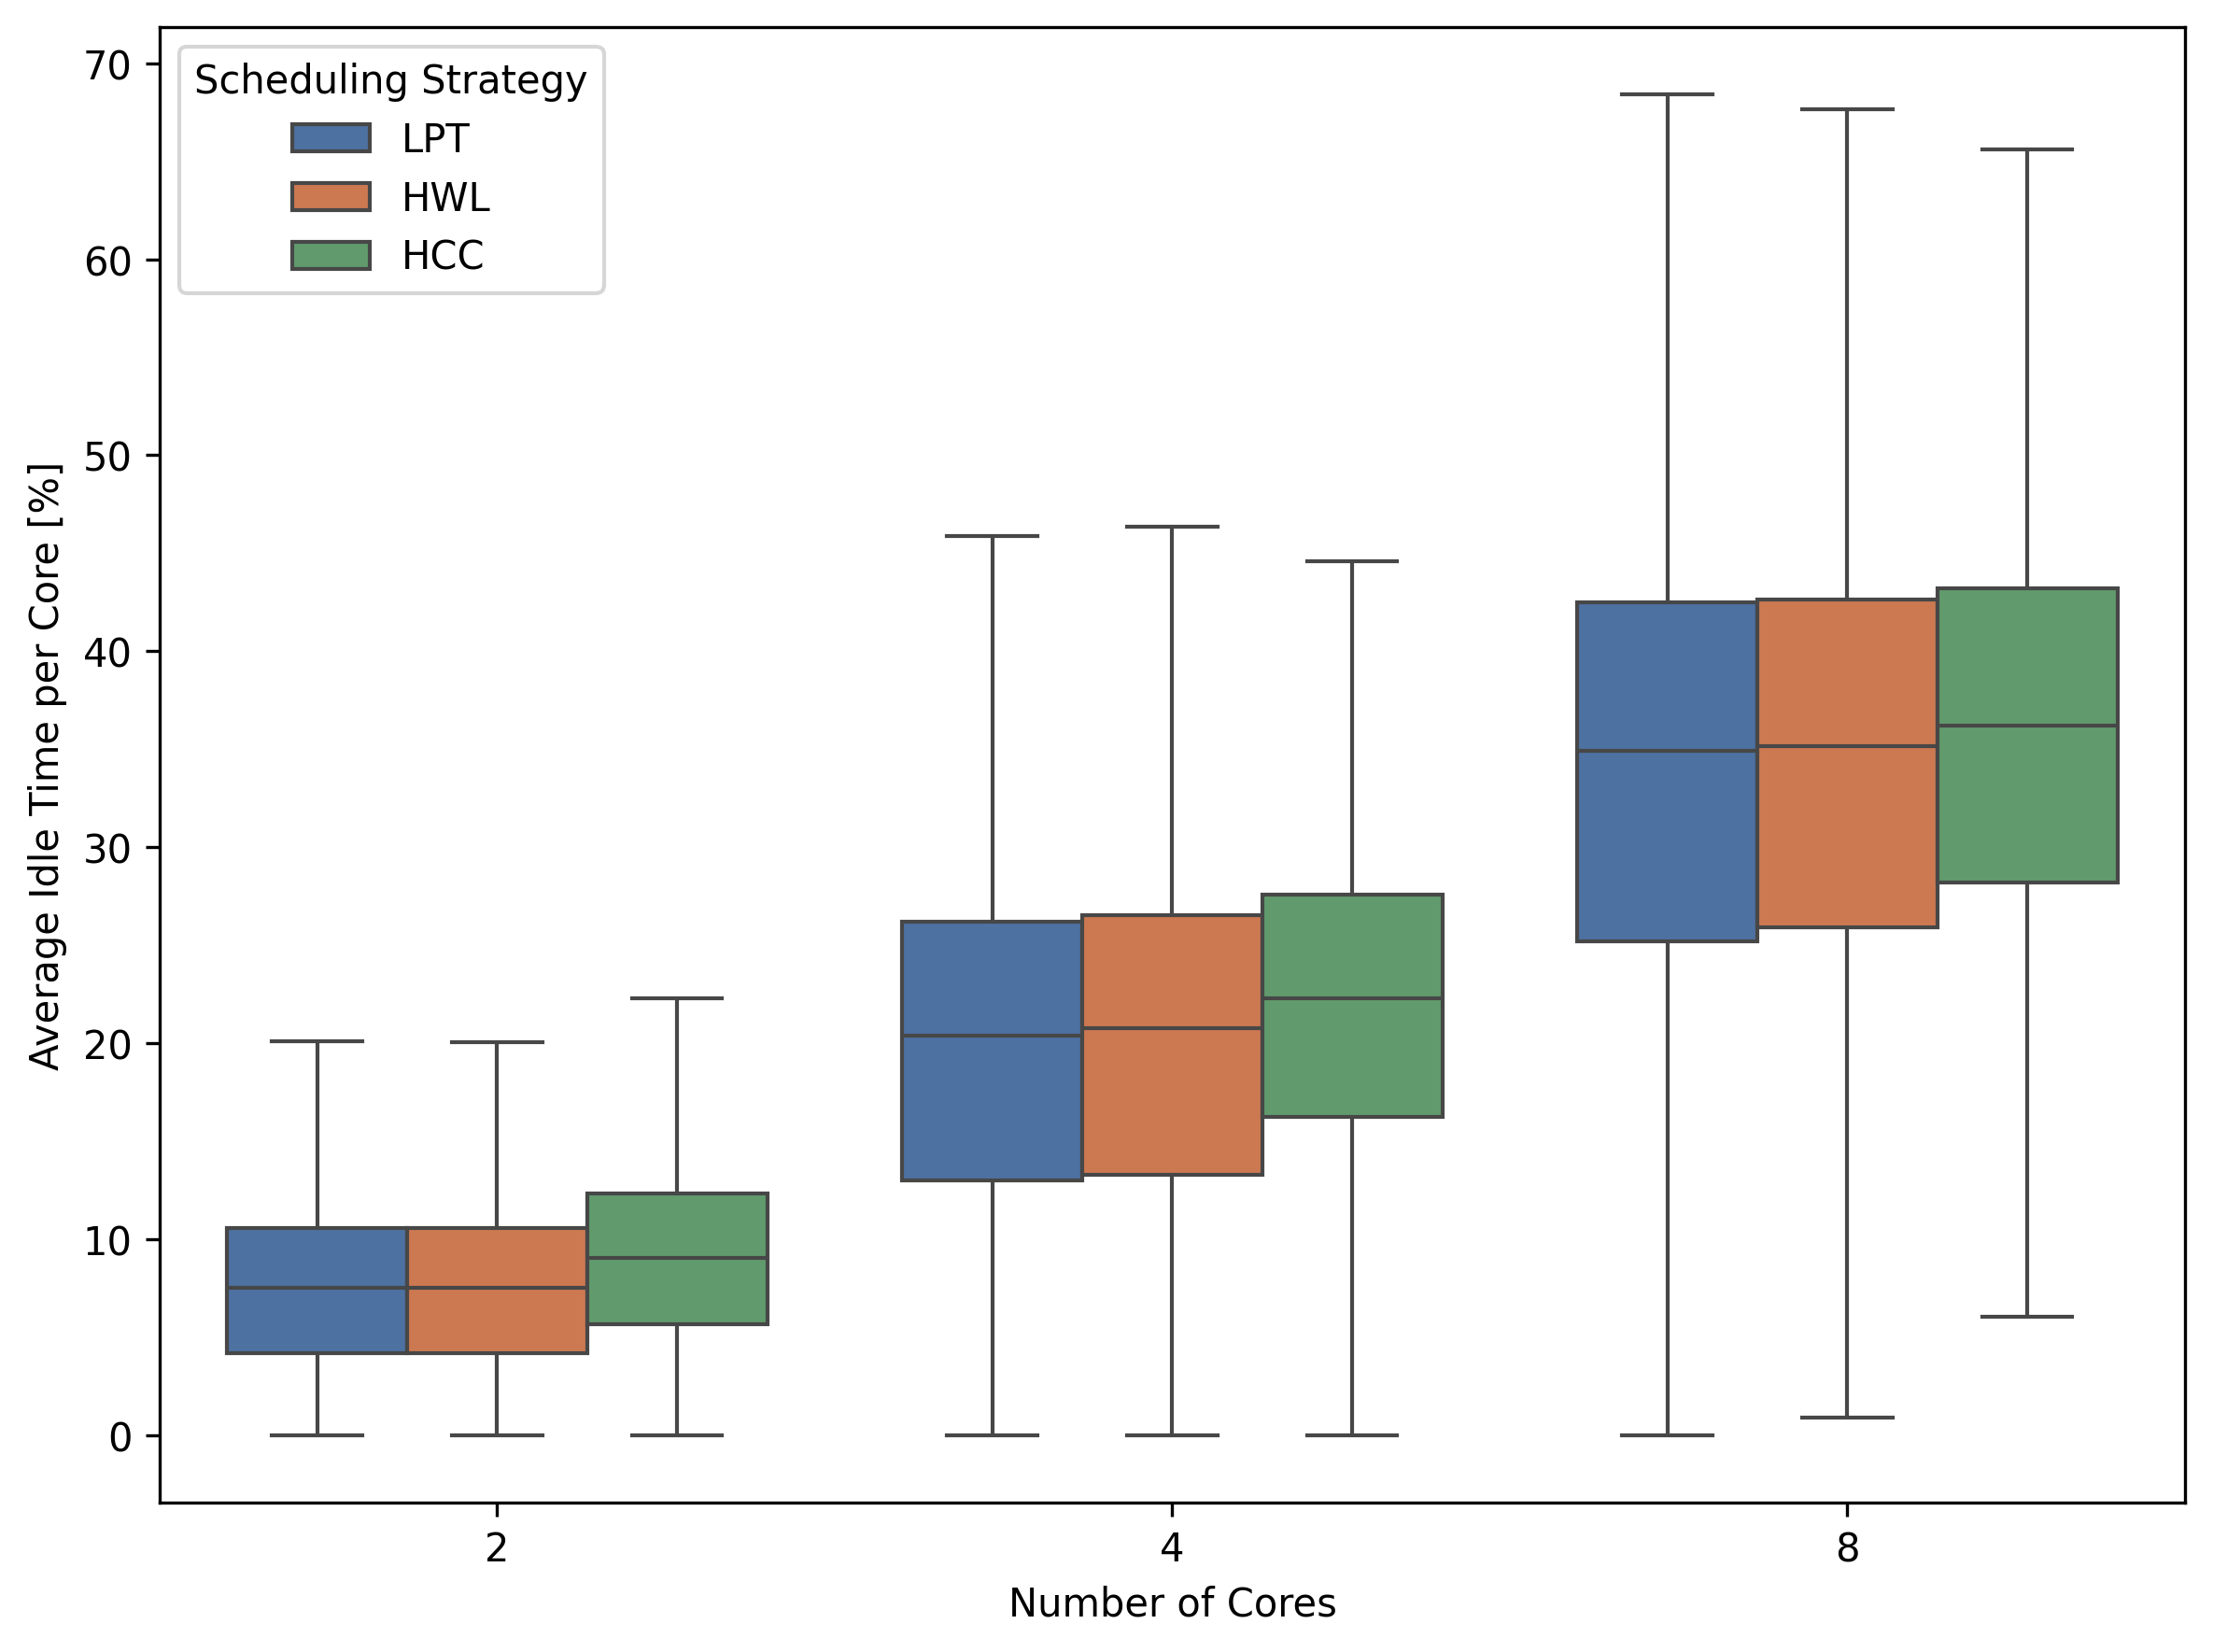

In [29]:
compare_scheduler(save_path="./figures/parallel/allot_scheduler_avg_gap.pdf")

#### Impact of Parallelization on HV
=> Restricted to LPT

- Comparisong MC (Full) vs NSGA-2
    - In wie vielen Fällen können wir MC dominaten?
    - Und um welchen durchschnittlichen Prozentsatz
- Comparison wie bei FS

In [30]:
df_comp = pd.DataFrame(data_comp)
print(df_comp.columns)

Index(['task_id', 'seed', 'bmg_method', 'ensembling_method', 'allotment_method', 'n_cores', 'data_ens', 'data_bm'], dtype='object')


In [31]:
def compare_full_nsga2(full_group, nsga2_group):
    RES_COLS = ["inference_time", "energy_consumption"]
    res_vals_nsga2 = nsga2_group[RES_COLS].values
    assert len(full_group) == 1, "Full group should have exactly one entry"
    res_vals_full = full_group[RES_COLS].values[0]
    strictly_dominates = np.all(res_vals_nsga2 < res_vals_full, axis=1)

    if np.any(strictly_dominates):
        n_dominated = np.sum(strictly_dominates)
        inf_time_improvements = (res_vals_full[0] - res_vals_nsga2[strictly_dominates,0]) / res_vals_full[0]
        energy_improvements = (res_vals_full[1] - res_vals_nsga2[strictly_dominates,1]) / res_vals_full[1]
        return n_dominated, inf_time_improvements, energy_improvements, True
    else:        
        finds_equal = np.any([np.allclose(r, res_vals_full) for r in res_vals_nsga2])
        return 0, [], [], bool(finds_equal)

In [32]:
def plot_ensemble_size_pf(bmg_method="mo-smac", ensembling_method="mo-ges", save_path=None):
    df_comp_filtered = df_comp[
        (df_comp["bmg_method"] == bmg_method) &
        (df_comp["ensembling_method"] == ensembling_method) &
        (df_comp["n_cores"] == 8) & # only use one core setting
        (df_comp["allotment_method"] == "full") # One allotment per setting => Use full allotment to get no ensemble twice
    ]
    
    ens_sizes = np.zeros(49)
    
    for task_id in df_comp_filtered["task_id"].unique():
        for seed in df_comp_filtered["seed"].unique():
            df_subset = df_comp_filtered[
                (df_comp_filtered["task_id"] == task_id) &
                (df_comp_filtered["seed"] == seed)
            ]
            bm_data = df_subset["data_bm"].values[0]
            data_ens = df_subset["data_ens"].values[0]
            ens_sizes_arr = [1] * len(bm_data) + data_ens["ensemble_size"].astype(int).tolist()
            for s in ens_sizes_arr:
                ens_sizes[s-1] += 1
    ens_size_vals = np.arange(1, 50)
    ens_size_freqs = ens_sizes / np.sum(ens_sizes)
    fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
    ax.bar(ens_size_vals, ens_size_freqs, width=0.8, color=COLOR_LIST[0])
    ax.set_xlabel("Ensemble Size")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(f"{save_path}_{bmg_method}_{ensembling_method}.pdf", dpi=DPI, bbox_inches='tight')
    else:
        plt.show()

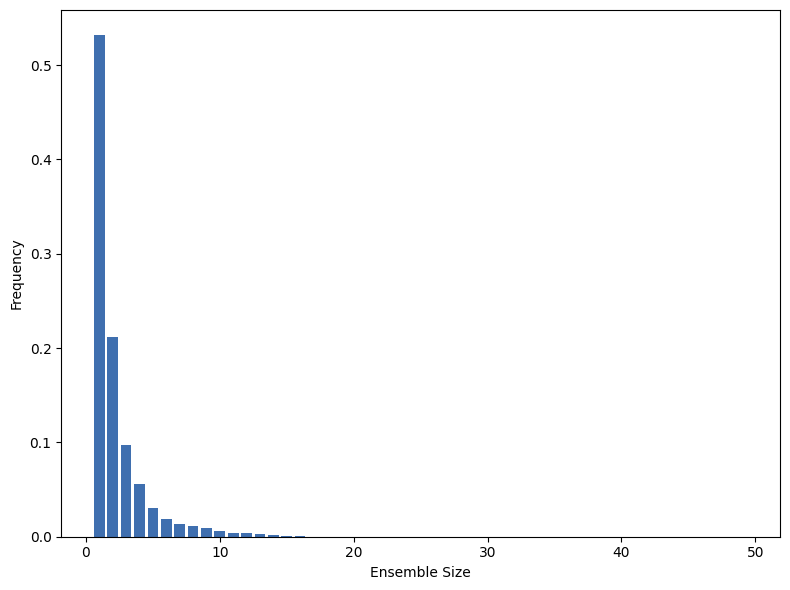

In [33]:
plot_ensemble_size_pf(save_path="./figures/parallel/ensemble_size_pf")

In [34]:
def plot_domination_count(bmg_method="mo-smac", ensembling_method="mo-ges", save_path=None):
    df_comp_filtered = df_comp[
        (df_comp["bmg_method"] == bmg_method) &
        (df_comp["ensembling_method"] == ensembling_method)
    ]
    
    dom_counts = {n_cores : {i : 0 for i in range(0, 11)} for n_cores in df_comp_filtered["n_cores"].unique()}
    
    for task_id in df_comp_filtered["task_id"].unique():
        for seed in df_comp_filtered["seed"].unique():
            for n_cores in df_comp_filtered["n_cores"].unique():
                df_subset = df_comp_filtered[
                    (df_comp_filtered["task_id"] == task_id) &
                    (df_comp_filtered["seed"] == seed) &
                    (df_comp_filtered["n_cores"] == n_cores)
                ]
                data_nsga2 = df_subset[df_subset["allotment_method"] == "nsga2"]["data_ens"].iloc[0]
                data_full = df_subset[df_subset["allotment_method"] == "full"]["data_ens"].iloc[0]
                if len(data_nsga2) == 0:
                    assert len(data_full) == 0, "NSGA-II data missing but full allotment data present"
                    continue
                data_nsga2 = data_nsga2[data_nsga2["ensemble_size"] > 1]
                data_full = data_full[data_full["ensemble_size"] > 1]
                
                for old_ensemble_index in data_full["old_ensemble_index"].astype(int).unique():
                    full_group = data_full[data_full["old_ensemble_index"].astype(int) == old_ensemble_index]
                    nsga2_group = data_nsga2[data_nsga2["old_ensemble_index"].astype(int) == old_ensemble_index]
                    
                    n_dominated, inf_time_imps, energy_imps, finds_equal = compare_full_nsga2(full_group, nsga2_group)
                    dom_counts[n_cores][n_dominated] += 1
                    
    fig, ax = plt.subplots(figsize=(8, 6), dpi=DPI)
    ax.set_prop_cycle(color=COLOR_LIST)

    # Prepare x positions
    x = np.array(list(range(11)))  # domination counts 0–10
    n_groups = len(dom_counts)
    bar_width = 0.8 / n_groups  # total width < 1

    for idx, (n_cores, counts) in enumerate(sorted(dom_counts.items())):
        total_counts = sum(counts.values())
        y = [counts[i] / total_counts for i in x]
        x_positions = x + idx * bar_width
        ax.bar(x_positions, y, width=bar_width, label=f"{n_cores} Cores")

    # Annotate bars with values
    for idx, (n_cores, counts) in enumerate(sorted(dom_counts.items())):
        total_counts = sum(counts.values())
        for i in x:
            freq = counts[i] / total_counts
            if freq > 0:
                x_pos = i + idx * bar_width
                ax.text(
                    x_pos,
                    freq + 0.01,
                    f"{freq:.6f}",
                    ha='center',
                    va='bottom',
                    fontsize=8,
                    rotation=90
                )


    # Adjust ticks to center
    ax.set_xticks(x + (n_groups - 1) * bar_width / 2)
    ax.set_xticklabels(x)

    ax.set_xlabel("Number of NSGA-P Solutions Dominating MC Solution")
    ax.set_ylabel("Frequency")
    ax.legend(title="Number of Cores")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(f"{save_path}_{bmg_method}_{ensembling_method}.pdf", dpi=DPI, bbox_inches='tight')
    else:
        plt.show()

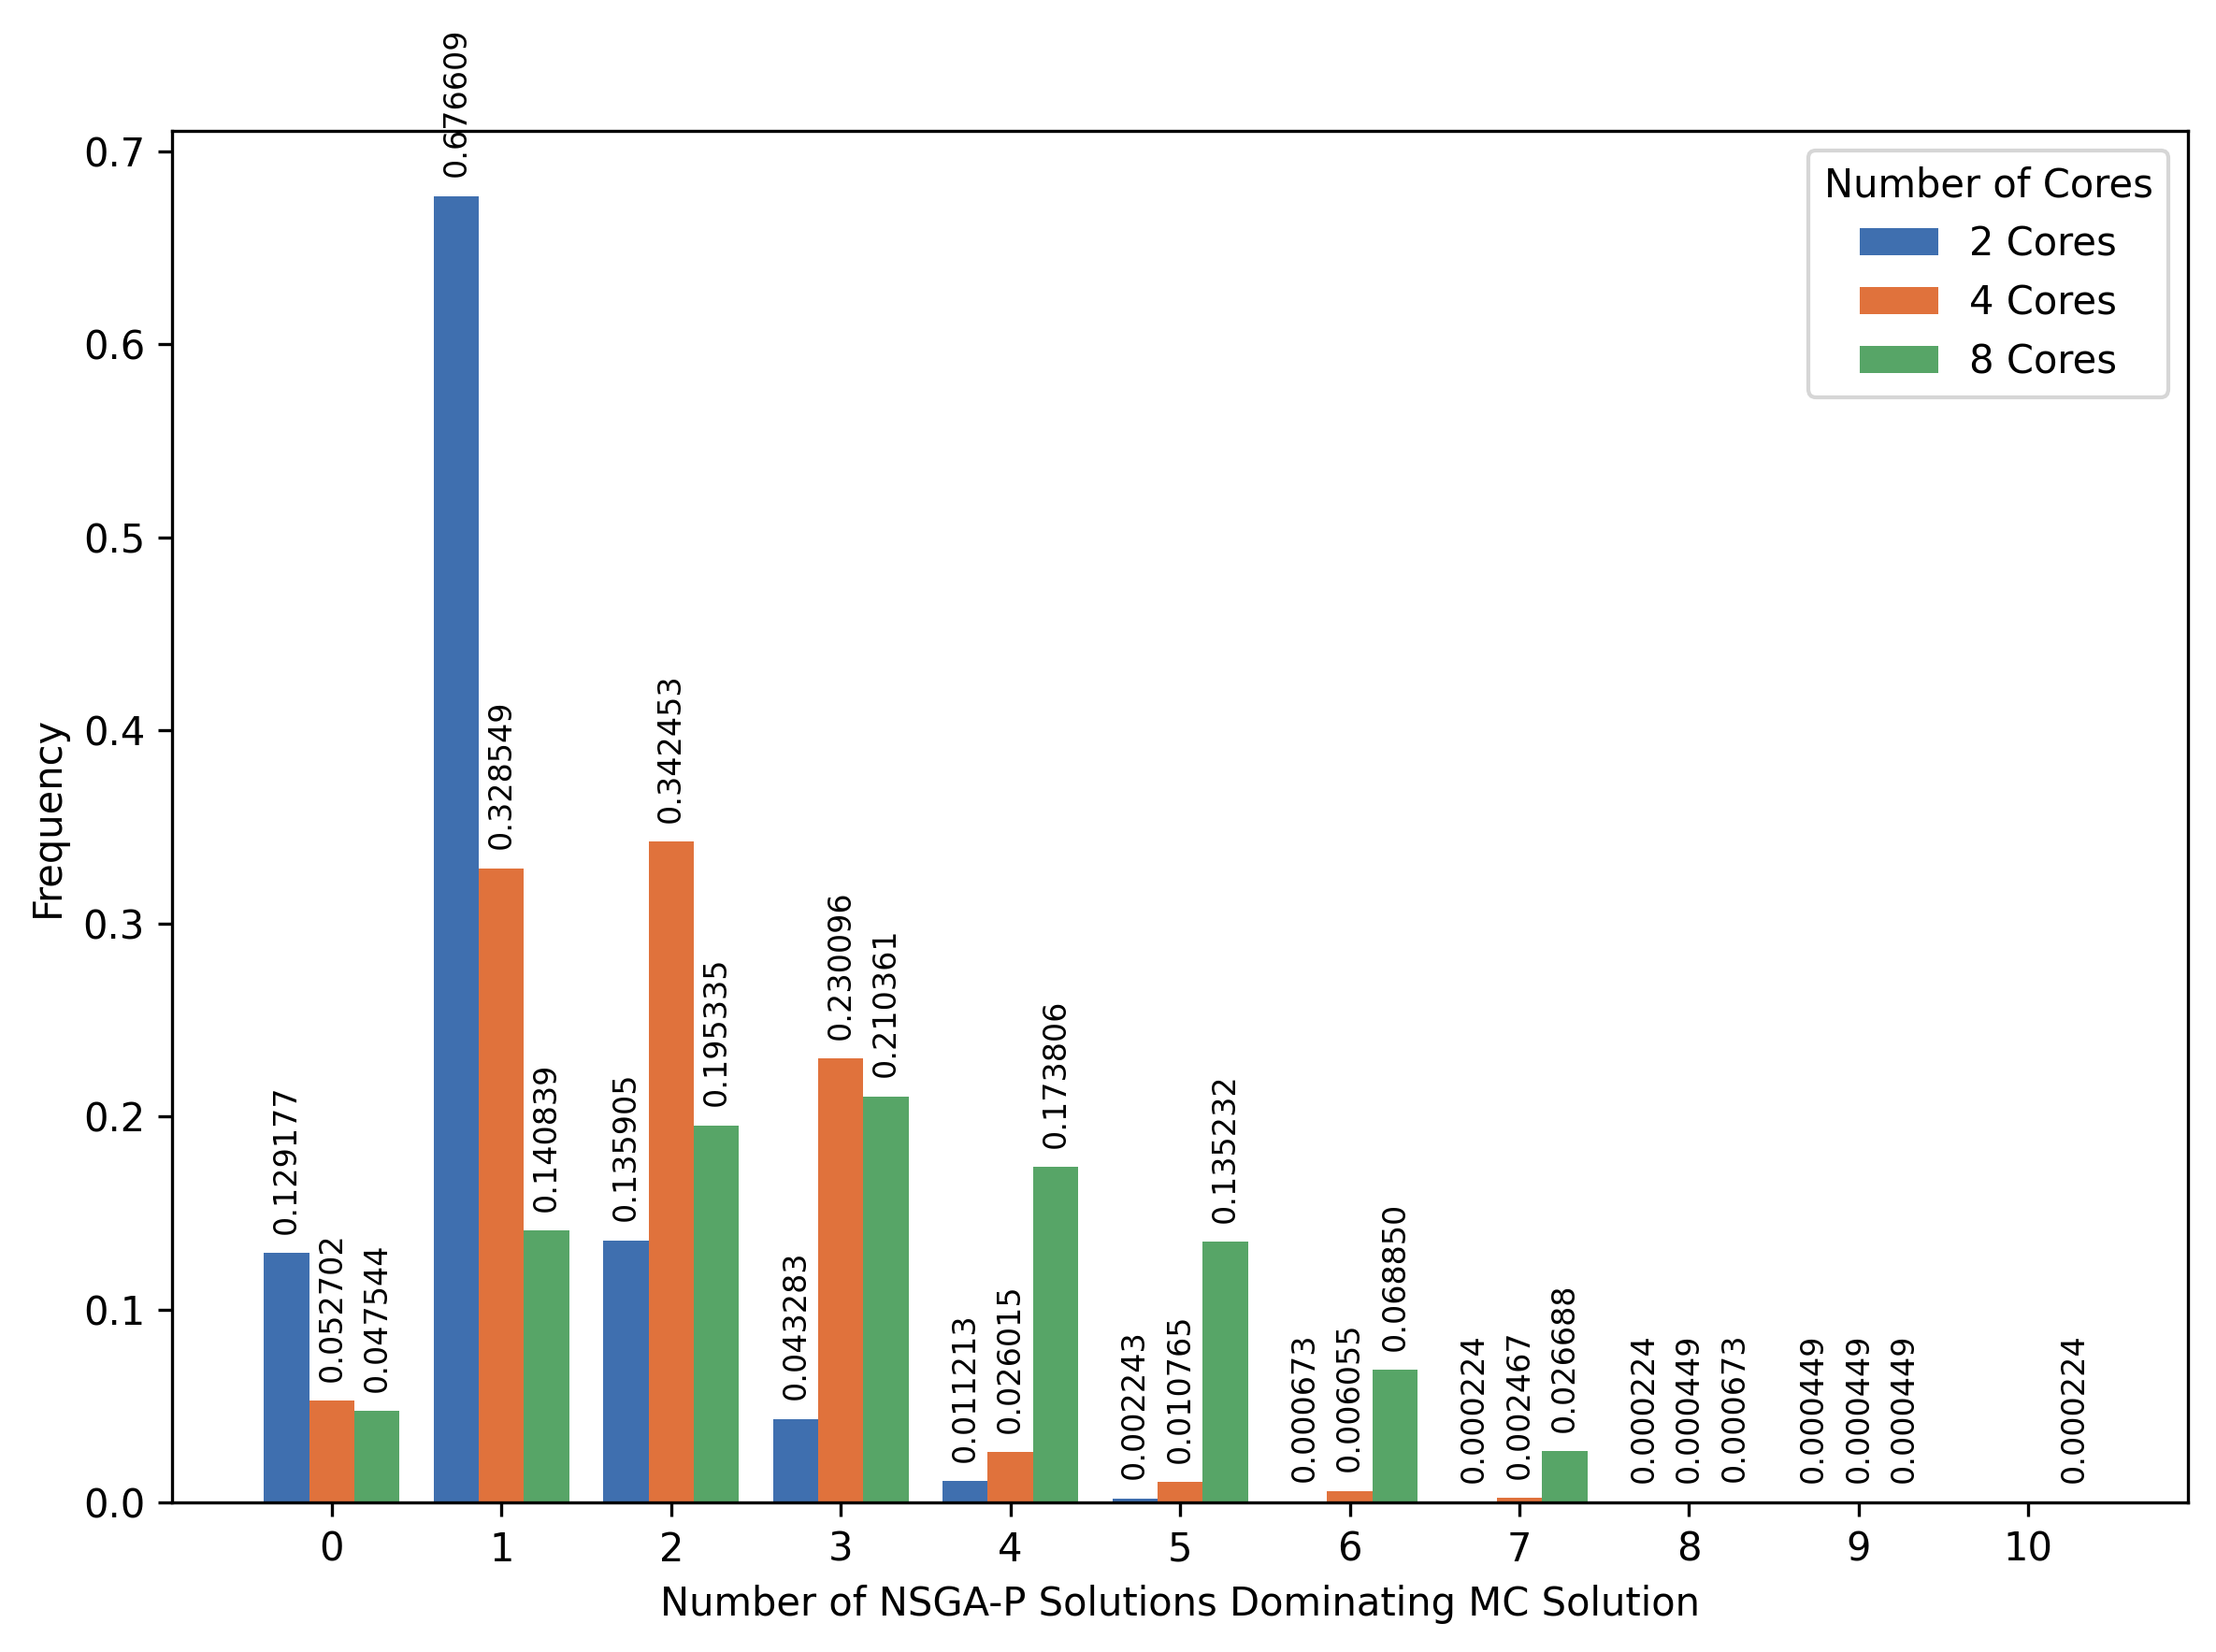

In [35]:
plot_domination_count(save_path="./figures/parallel/nsga2_dominance_count")

In [36]:
RES_COLS = ["inference_time", "energy_consumption"]
from matplotlib import patches as mpatches

def plot_dom_extent(bmg_method="mo-smac", ensembling_method="mo-ges", optimization_criterion="inference_time", save_path=None):
    df_comp_filtered = df_comp[
        (df_comp["bmg_method"] == bmg_method) &
        (df_comp["ensembling_method"] == ensembling_method)
    ]
    
    improvements = np.zeros((104, 5, 3, 2, 2), dtype=float) # Shape: tasks, seeds, n_cores, inf_time/energy optimization objective, inf time/energy improvement
    improvement_counts = np.zeros((104, 5, 3), dtype=int)
    
    
    for i, task_id in enumerate(df_comp_filtered["task_id"].unique()):
        for j, seed in enumerate(df_comp_filtered["seed"].unique()):
            for k, n_cores in enumerate([2,4,8]):
                df_subset = df_comp_filtered[
                    (df_comp_filtered["task_id"] == task_id) &
                    (df_comp_filtered["seed"] == seed) &
                    (df_comp_filtered["n_cores"] == n_cores)
                ]
                data_nsga2 = df_subset[df_subset["allotment_method"] == "nsga2"]["data_ens"].iloc[0]
                data_full = df_subset[df_subset["allotment_method"] == "full"]["data_ens"].iloc[0]
                data_nsga2 = data_nsga2[data_nsga2["ensemble_size"] > 1]
                data_full = data_full[data_full["ensemble_size"] > 1]
                if len(data_nsga2) == 0:
                    assert len(data_full) == 0, "NSGA-II data missing but full allotment data present"
                    continue
                
                for old_ensemble_index in data_full["old_ensemble_index"].astype(int).unique():
                    full_group = data_full[data_full["old_ensemble_index"].astype(int) == old_ensemble_index]
                    nsga2_group = data_nsga2[data_nsga2["old_ensemble_index"].astype(int) == old_ensemble_index]
                    
                    strictly_dominates = np.all(nsga2_group[RES_COLS].values < full_group[RES_COLS].values[0], axis=1)
                    
                    improvement_counts[i, j, k] += 1
                    
                    if not np.any(strictly_dominates):
                        continue
                    
                    nsga2_group_dom = nsga2_group[strictly_dominates]
                    
                    
                    assert len(full_group) == 1, "Full group should have exactly one entry"
                    
                    for index, res in enumerate(RES_COLS):
                        min_val = nsga2_group_dom[res].min()
                        min_indices = nsga2_group_dom[nsga2_group_dom[res] == min_val].index.tolist()
                        if len(min_indices) > 1:
                            other_res = RES_COLS[1 - index]
                            best_index = nsga2_group_dom.loc[min_indices][other_res].idxmin()
                        else:
                            best_index = min_indices[0]
                        
                        improvements[i, j, k, index, :] += np.array((full_group[RES_COLS].values[0] - nsga2_group_dom.loc[best_index, RES_COLS].values) / full_group[RES_COLS].values[0], dtype=float)
    
    fig, ax = plt.subplots(figsize=(8, 6), dpi=DPI)
    
    improvements /= (improvement_counts[..., np.newaxis, np.newaxis] + 1e-12)
    
    data_df = []
    for i_n_cores, n_cores in enumerate([2,4,8]):
        imps = improvements[:, :, i_n_cores, RES_COLS.index(optimization_criterion), :]
        imps_inf_time = imps[...,0]
        imps_energy = imps[...,1]
        
        data_df.append({
            "n_cores": n_cores,
            "imps_inf_time_mean": imps_inf_time.mean(),
            "imps_inf_time_std": imps_inf_time.std(),
            "imps_energy_mean": imps_energy.mean(),
            "imps_energy_std": imps_energy.std()
        })
        
        ax.boxplot(
            [imps_inf_time.flatten() * 100],
            positions=[i_n_cores * 3 + 0.5],
            widths=0.8,
            boxprops=dict(facecolor=COLOR_LIST[0], color='black'),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            patch_artist=True
        )

        ax.boxplot(
            [imps_energy.flatten() * 100],
            positions=[i_n_cores * 3 + 1.5],
            widths=0.8,
            boxprops=dict(facecolor=COLOR_LIST[1], color='black'),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            patch_artist=True
        )
        
    ax.set_xticks([i * 3 + 1 for i in range(3)])
    ax.set_xticklabels([f"{n_cores} Cores" for n_cores in [2,4,8]])
    ax.set_xlabel("Number of Cores")
    ax.set_ylabel("Relative Improvement over Full Allotment [%]")
    legend_patches = [
        mpatches.Patch(facecolor=COLOR_LIST[0], edgecolor='black', label="Inference Time", hatch=''),
        mpatches.Patch(facecolor=COLOR_LIST[1], edgecolor='black', label="Energy Consumption", hatch='')
    ]
    ax.legend(handles=legend_patches, title="Metric")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(f"{save_path}_{bmg_method}_{ensembling_method}.pdf", dpi=DPI, bbox_inches='tight')
    else:
        plt.show()
        
    data_df = pd.DataFrame(data_df)
    data_df["Inference Time Improvement [%]"] = data_df.apply(lambda row: f"{row['imps_inf_time_mean']*100:.2f} ({row['imps_inf_time_std']*100:.2f})", axis=1)
    data_df["Energy Consumption Improvement [%]"] = data_df.apply(lambda row: f"{row['imps_energy_mean']*100:.2f} ({row['imps_energy_std']*100:.2f})", axis=1)
    data_df.rename(columns={"n_cores": "Number of Cores"}, inplace=True)
    print(data_df[["Number of Cores", "Inference Time Improvement [%]", "Energy Consumption Improvement [%]"]].to_latex(index=False))

\begin{tabular}{rll}
\toprule
Number of Cores & Inference Time Improvement [%] & Energy Consumption Improvement [%] \\
\midrule
2 & 24.66 (13.68) & 7.20 (6.02) \\
4 & 37.26 (14.28) & 15.66 (9.55) \\
8 & 43.40 (16.27) & 25.71 (15.73) \\
\bottomrule
\end{tabular}



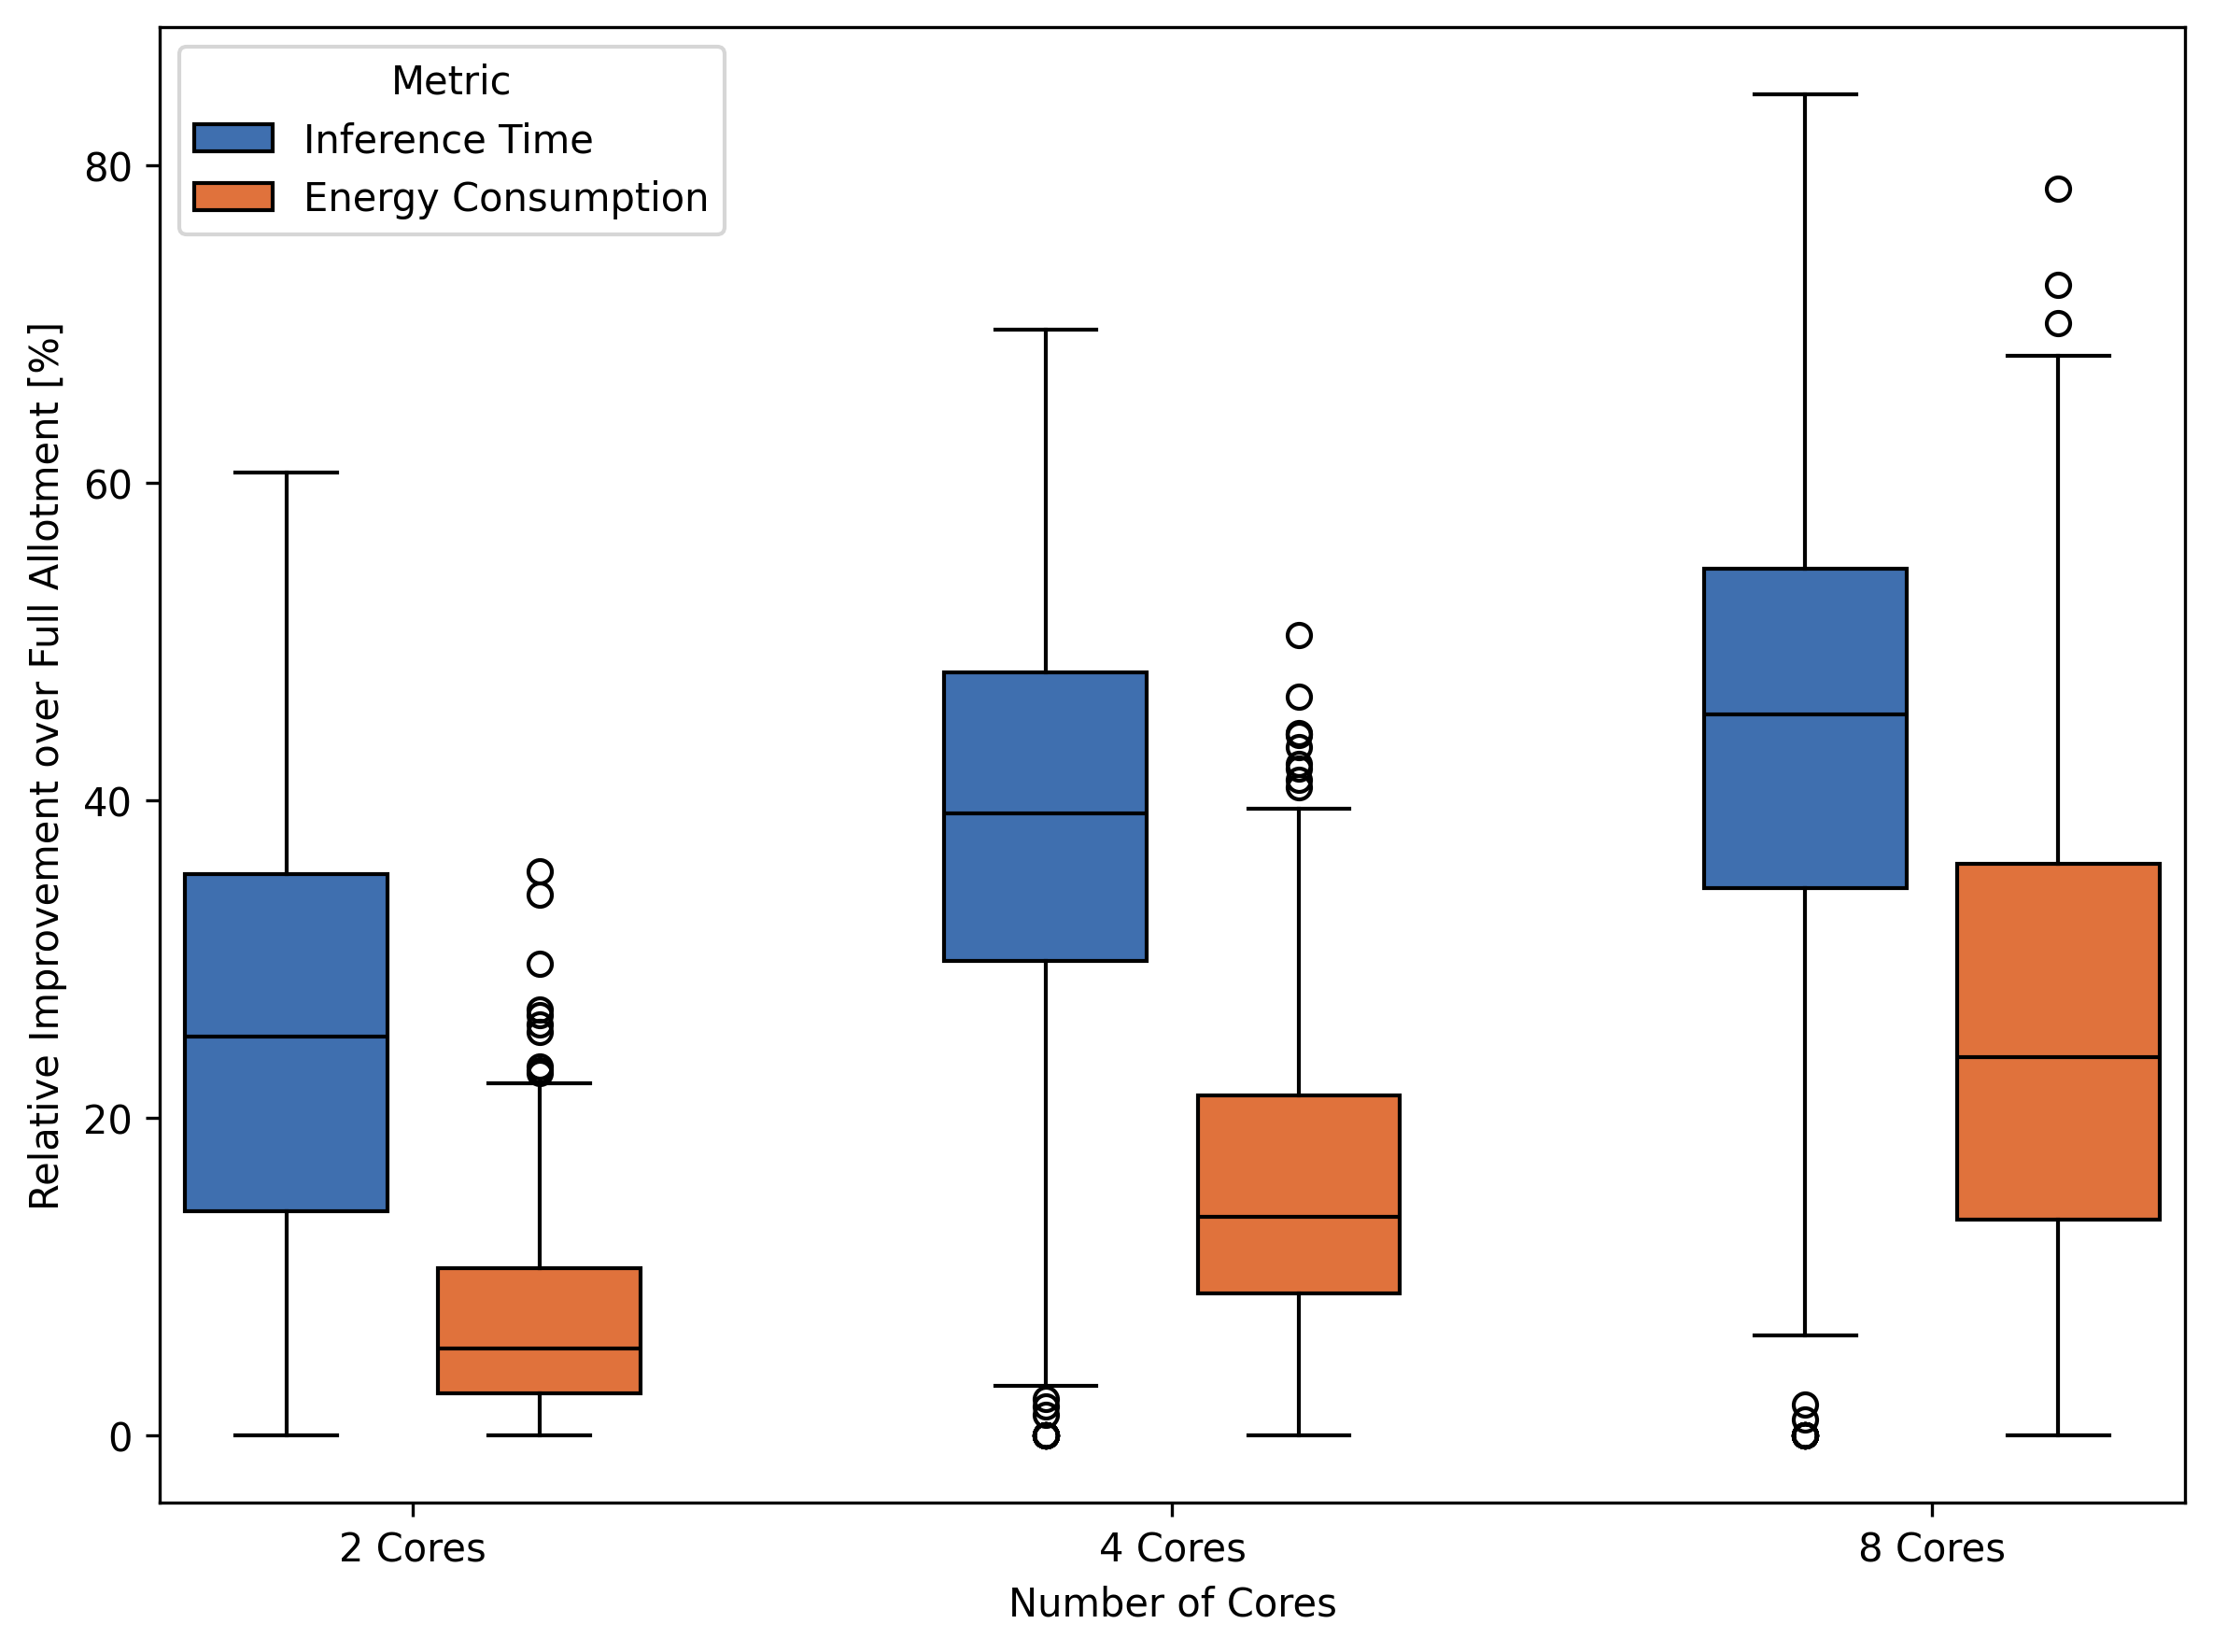

In [37]:
plot_dom_extent(save_path="./figures/parallel/nsga2_dominance_extent")

In [38]:
def plot_parallel(metric_name="hv", ensembling_method="mo-ges", bmg = "mo-smac", only_allotment=False, only_ensembling=False, metric_rename=None, save_path=None):
    metric_indices = [METRICS_ORDER.index(f"{metric_name}_{x}") for x in ["bmp", "bmp+ens", "bmp_allotment", "bmp+ens_allotment"]]
    scheduling_index = SCHEDULING_STRATEGIES.index("lpt")
    ensembling_method_idx = ENSEMBLING_METHODS.index(ensembling_method)
    bmg_idx = BMG_METHODS.index(bmg)
    
    group_member_labels = ["BMP + Ensembling", "BMP + Allotment (MC)", "BMP + Allotment (NSGA-P)", "BMP + Ensembling + Allotment (MC)", "BMP + Ensembling + Allotment (NSGA-P)"]
    group_data = []
    for n_cores in N_CORES_LIST:
        n_cores_idx = N_CORES_LIST.index(n_cores)
        data_full = results_parallel_full[:, :, bmg_idx, ensembling_method_idx, n_cores_idx, metric_indices]  # Shape: 104,5,6,4
        data_full = data_full.mean(axis=1)  # Average over seeds -> Shape: 104, 4
        
        data_nsga2 = results_parallel_nsga2[:, :, bmg_idx, ensembling_method_idx, scheduling_index, n_cores_idx, metric_indices]  # Shape: 104,5,6,4
        data_nsga2 = data_nsga2.mean(axis=1)  # Average over seeds -> Shape: 104, 4
        
        data_full_rel = data_full[:, 1:] / (data_full[:, 0:1] + 1e-12) - 1
        data_nsga2_rel = data_nsga2[:, 1:] / (data_nsga2[:, 0:1] + 1e-12) - 1
        
        data_combined = [data_full_rel[:, 0], data_full_rel[:, 1], data_nsga2_rel[:, 1], data_full_rel[:, 2], data_nsga2_rel[:, 2]]
        for key, vals in zip(group_member_labels, data_combined):
            for val in vals:
                group_data.append({
                    "Number of Cores": n_cores,
                    "Method": key,
                    "improvement": val * 100
                })
    
    df = pd.DataFrame(group_data)    
    
    if only_allotment:
        group_member_labels = [l for l in group_member_labels if "Allotment" in l]
    if only_ensembling:
        group_member_labels = [l for l in group_member_labels if "Ensembling" in l]
        
        
    df = df[df["Method"].isin(group_member_labels)]
        
    
    fig, ax = plt.subplots(figsize=(8, 6), dpi=DPI)
    sns.boxplot(
        data=df,
        x="Number of Cores",
        y="improvement",
        hue="Method",
        palette=COLOR_LIST[:len(group_member_labels)],
        ax=ax,
        showfliers=False,
        gap=0.15
    )
    ax.grid(axis='y')
    ax.set_xlabel("Number of Cores")
    ax.set_ylabel(f"Relative {METRIC_MAP[metric_name] if metric_rename is None else metric_rename} Improvement over Base Model Pool [%]")
    ax.legend(title="Method")
    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path, dpi=DPI, bbox_inches='tight')
    else:
        plt.show()

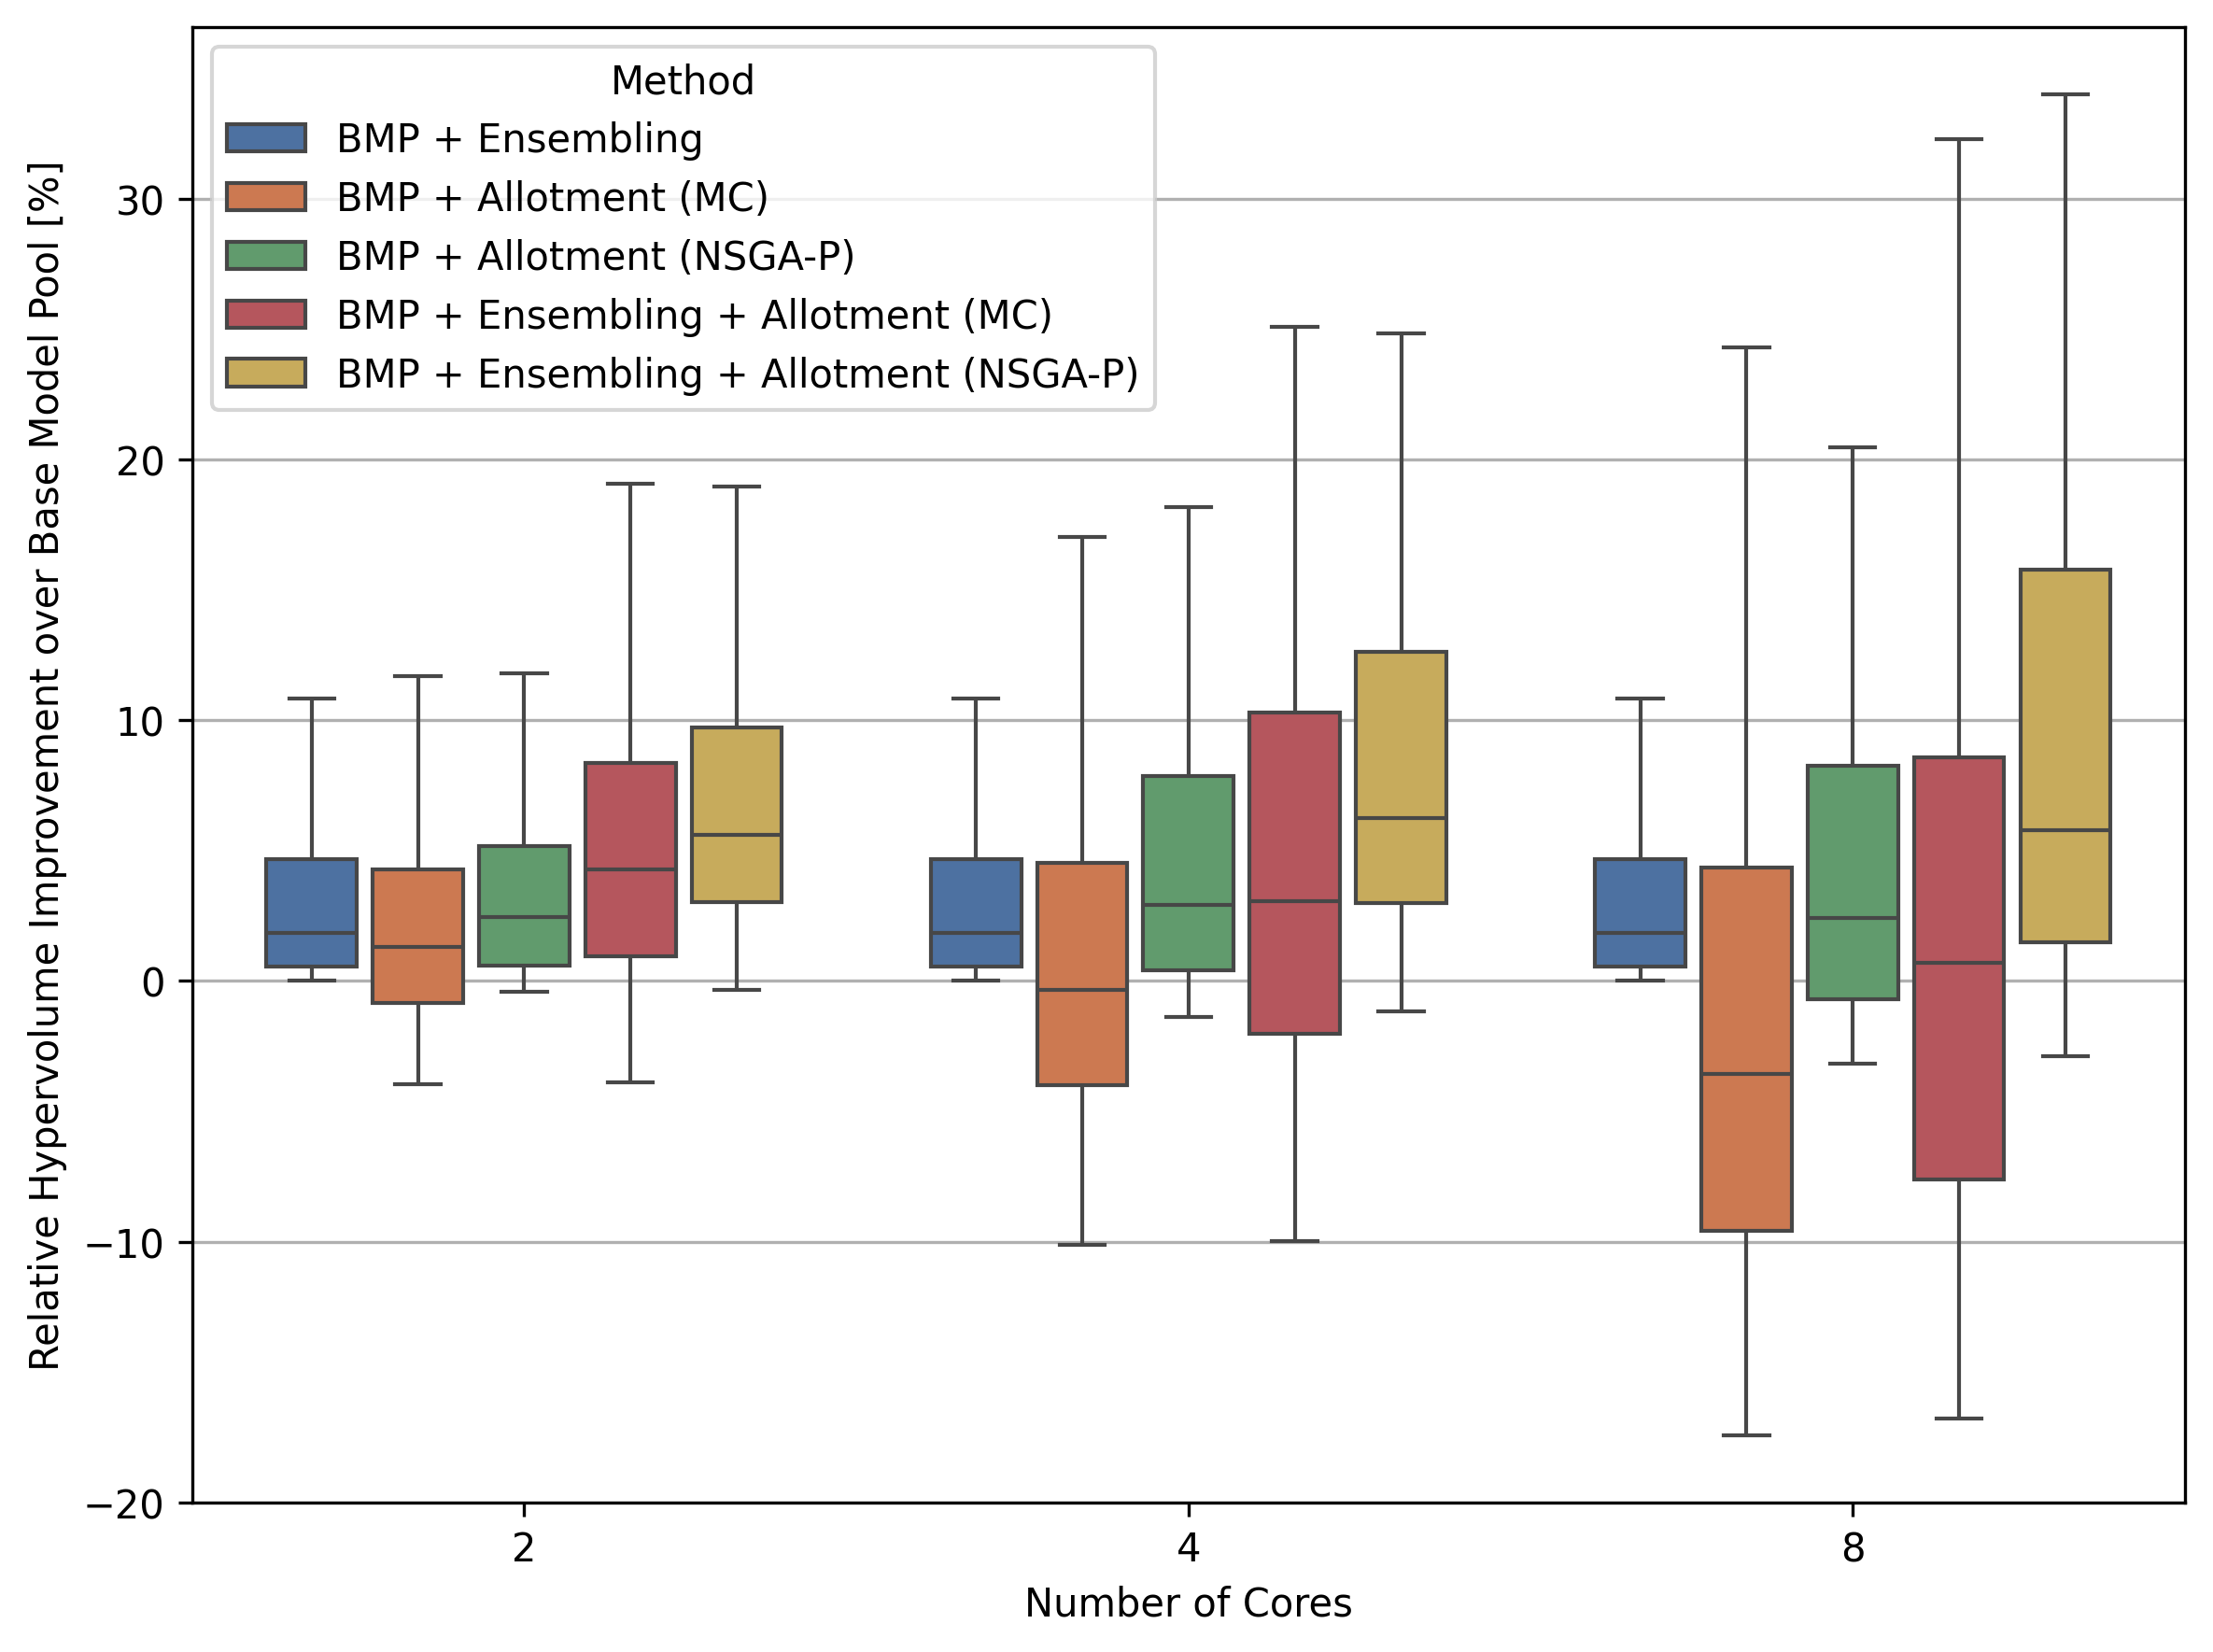

In [39]:
plot_parallel("hv_log", ensembling_method="mo-ges", bmg="mo-smac", metric_rename="Hypervolume", save_path="./figures/parallel/allot_hv.pdf")

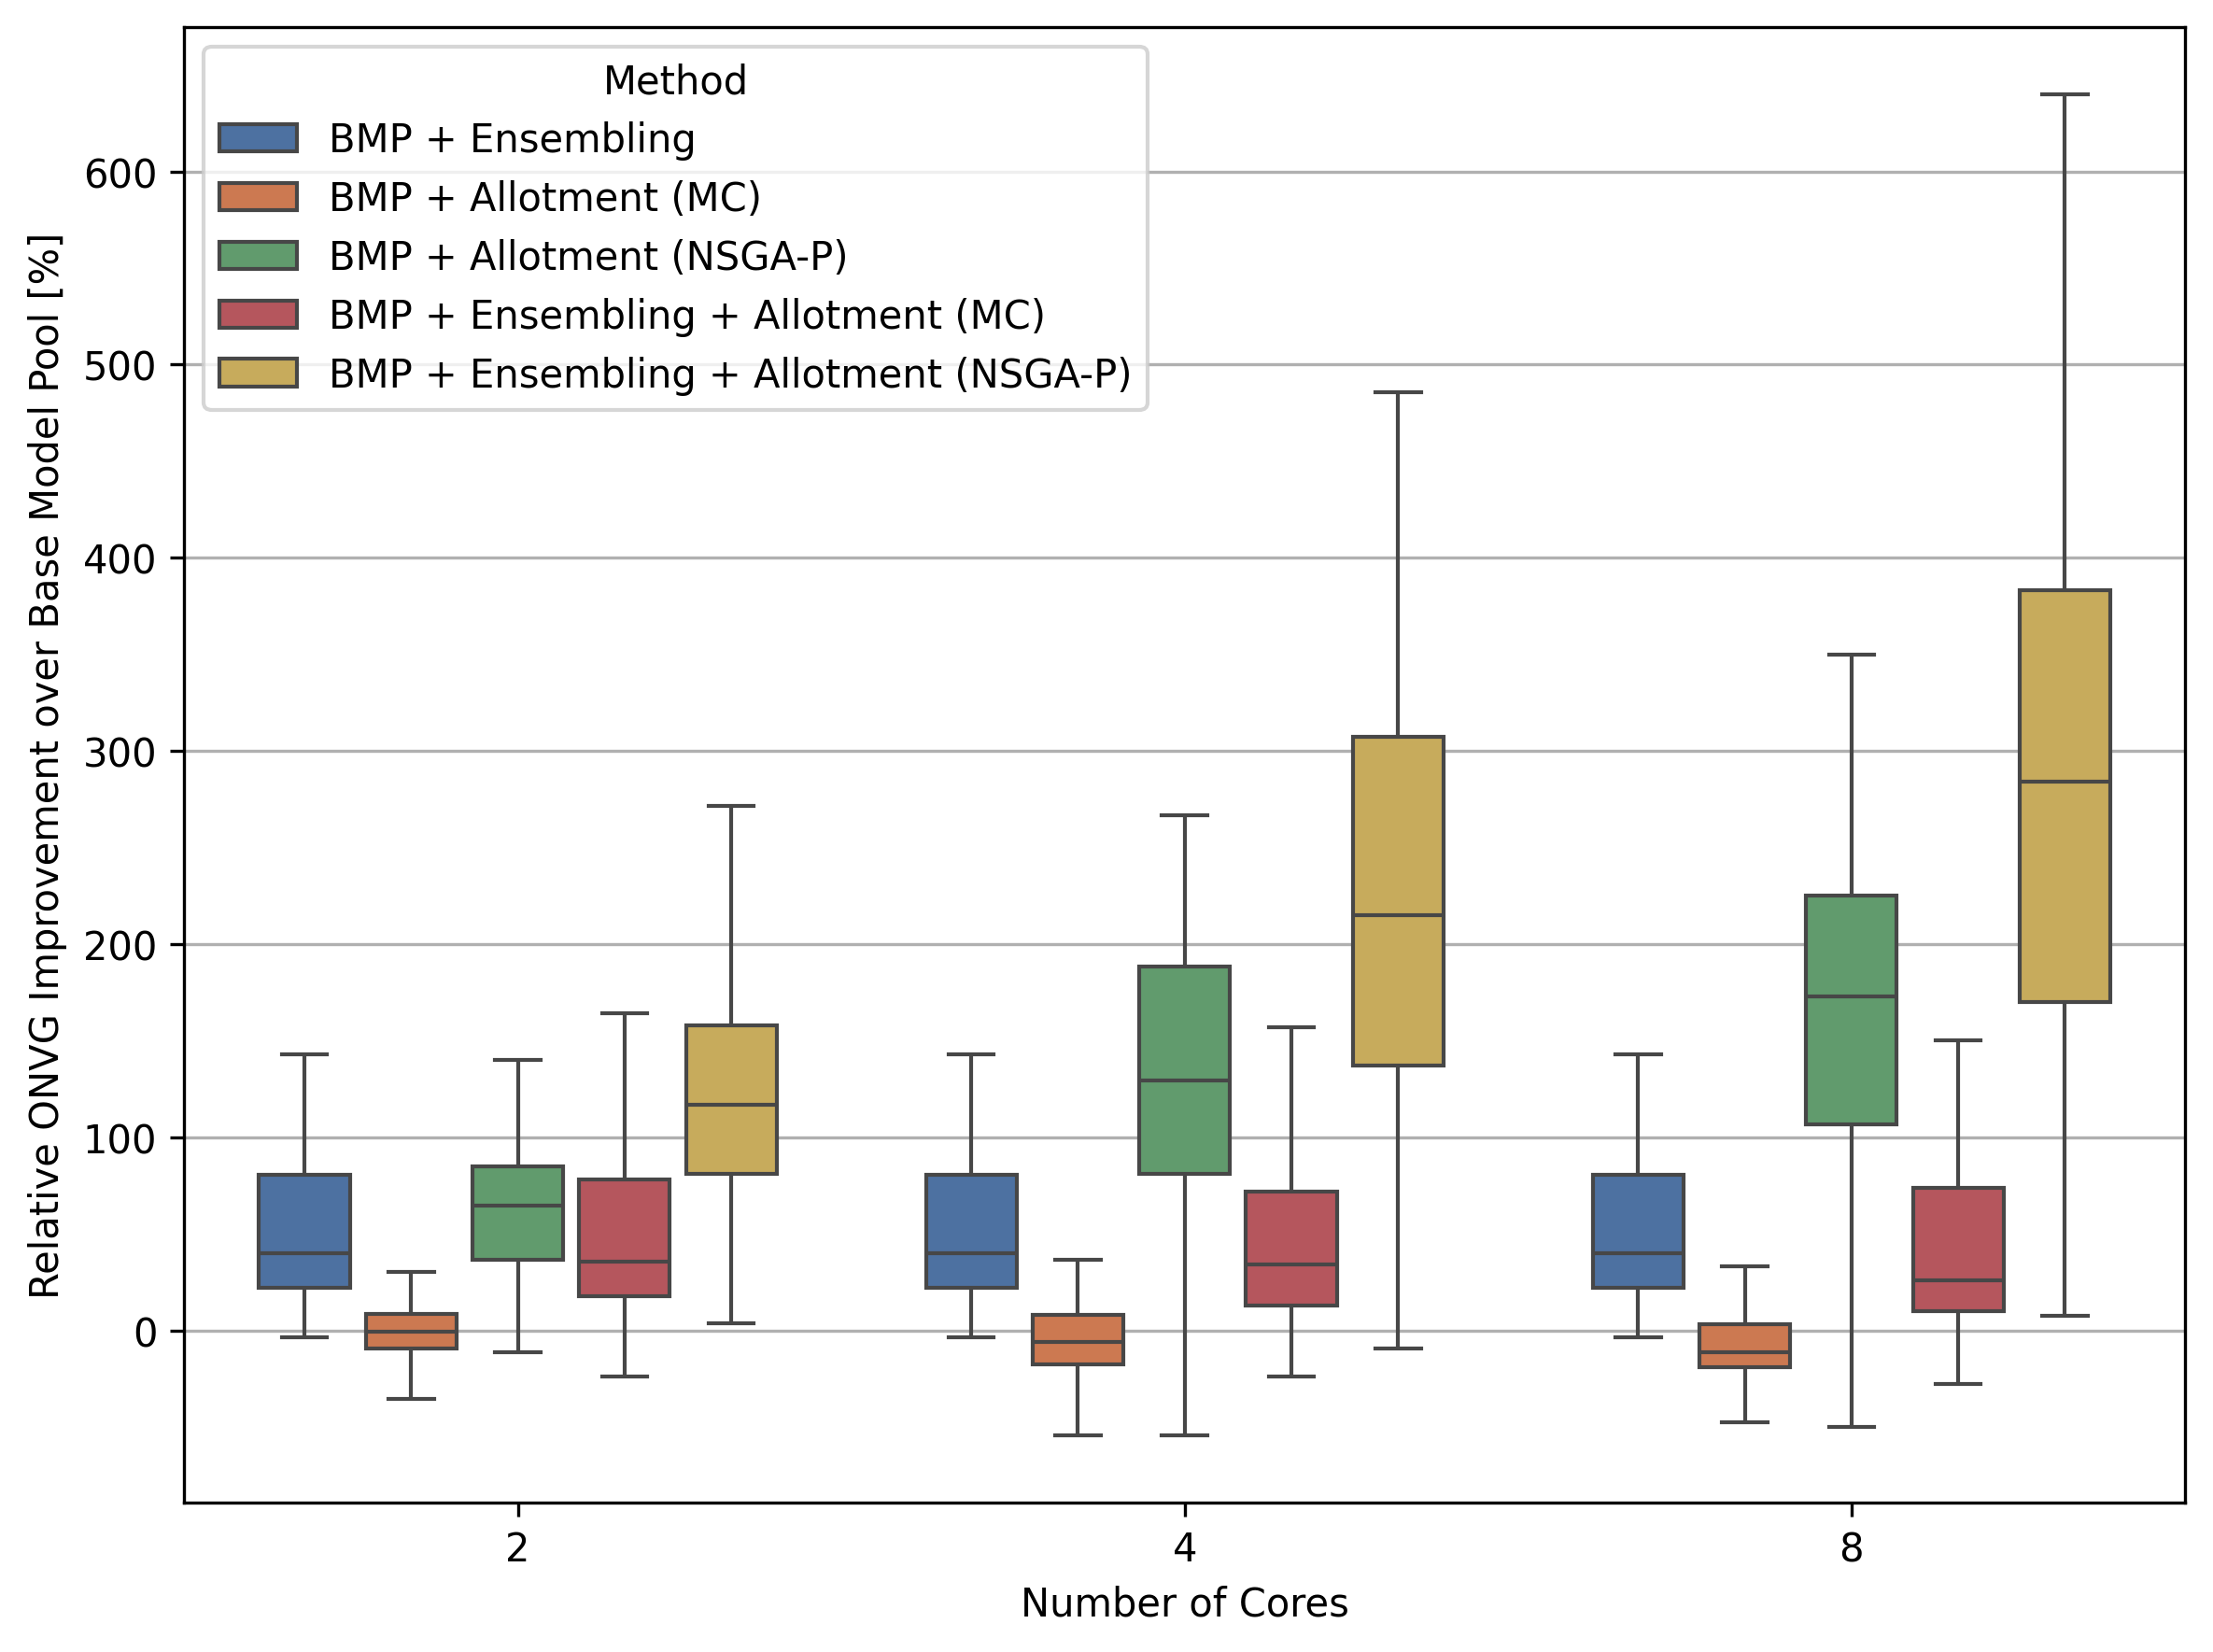

In [40]:
plot_parallel("onvg", ensembling_method="mo-ges", bmg="mo-smac", save_path="./figures/parallel/allot_onvg.pdf")

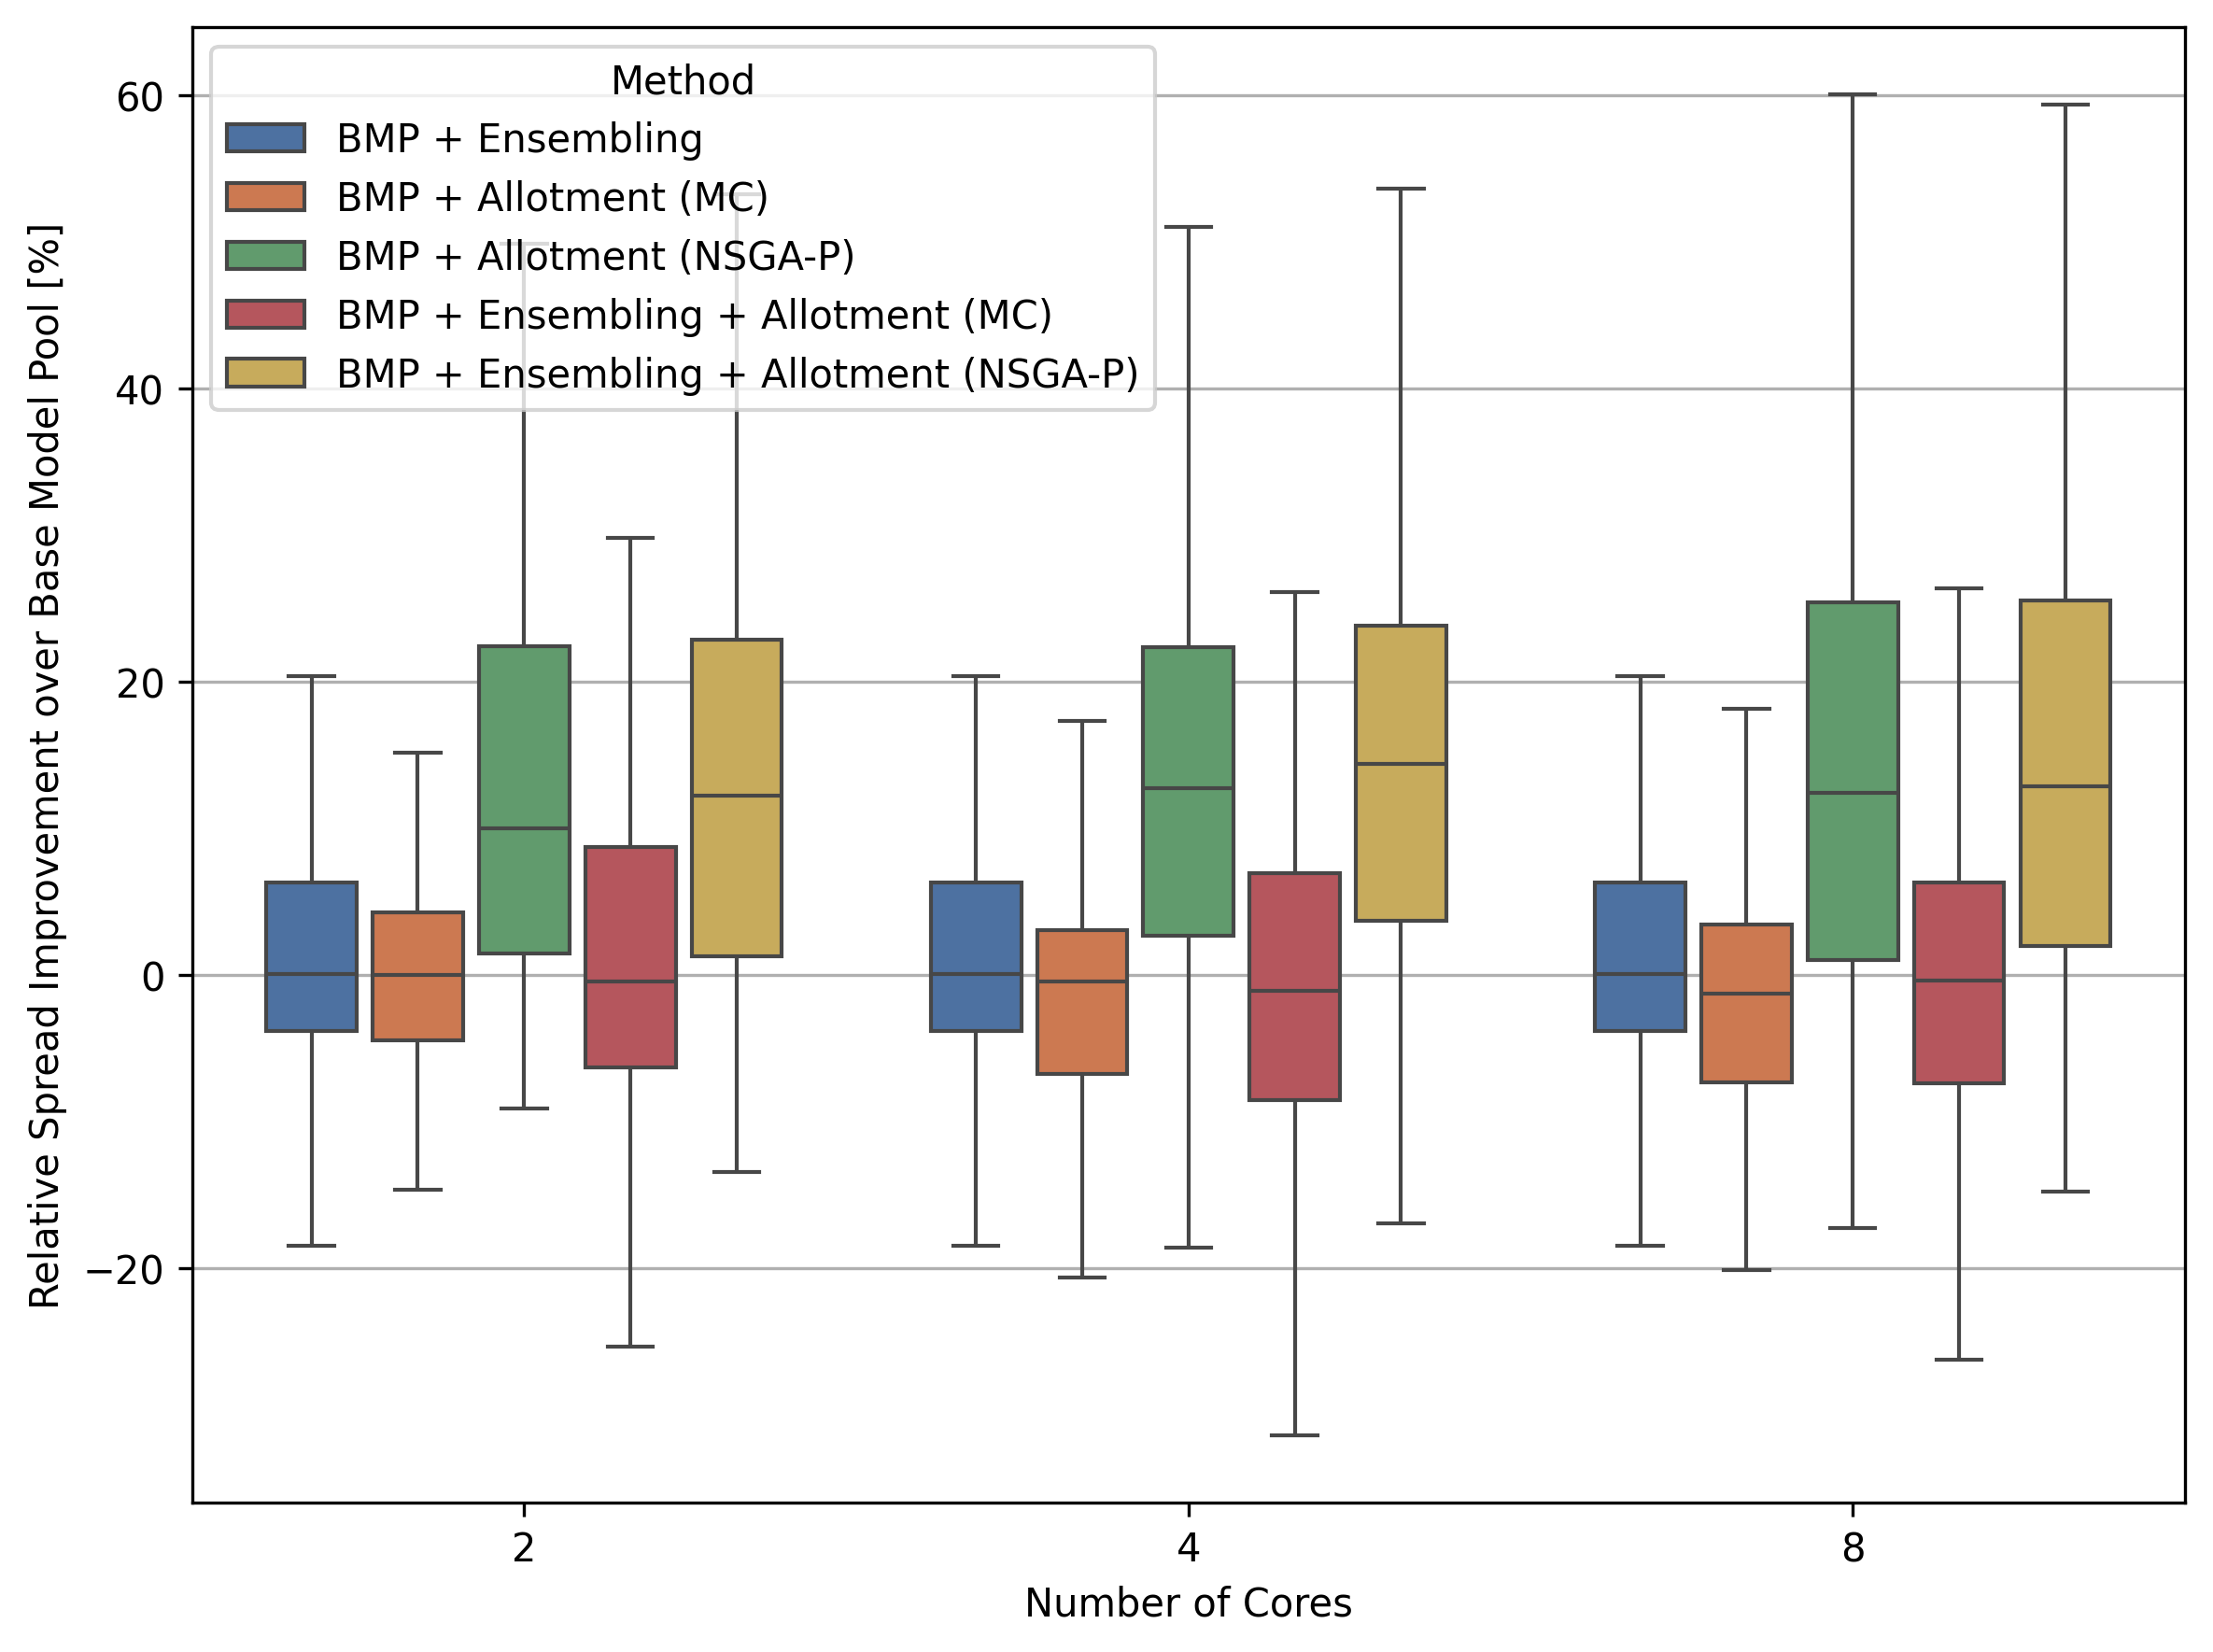

In [41]:
plot_parallel("spread", ensembling_method="mo-ges", bmg="mo-smac")

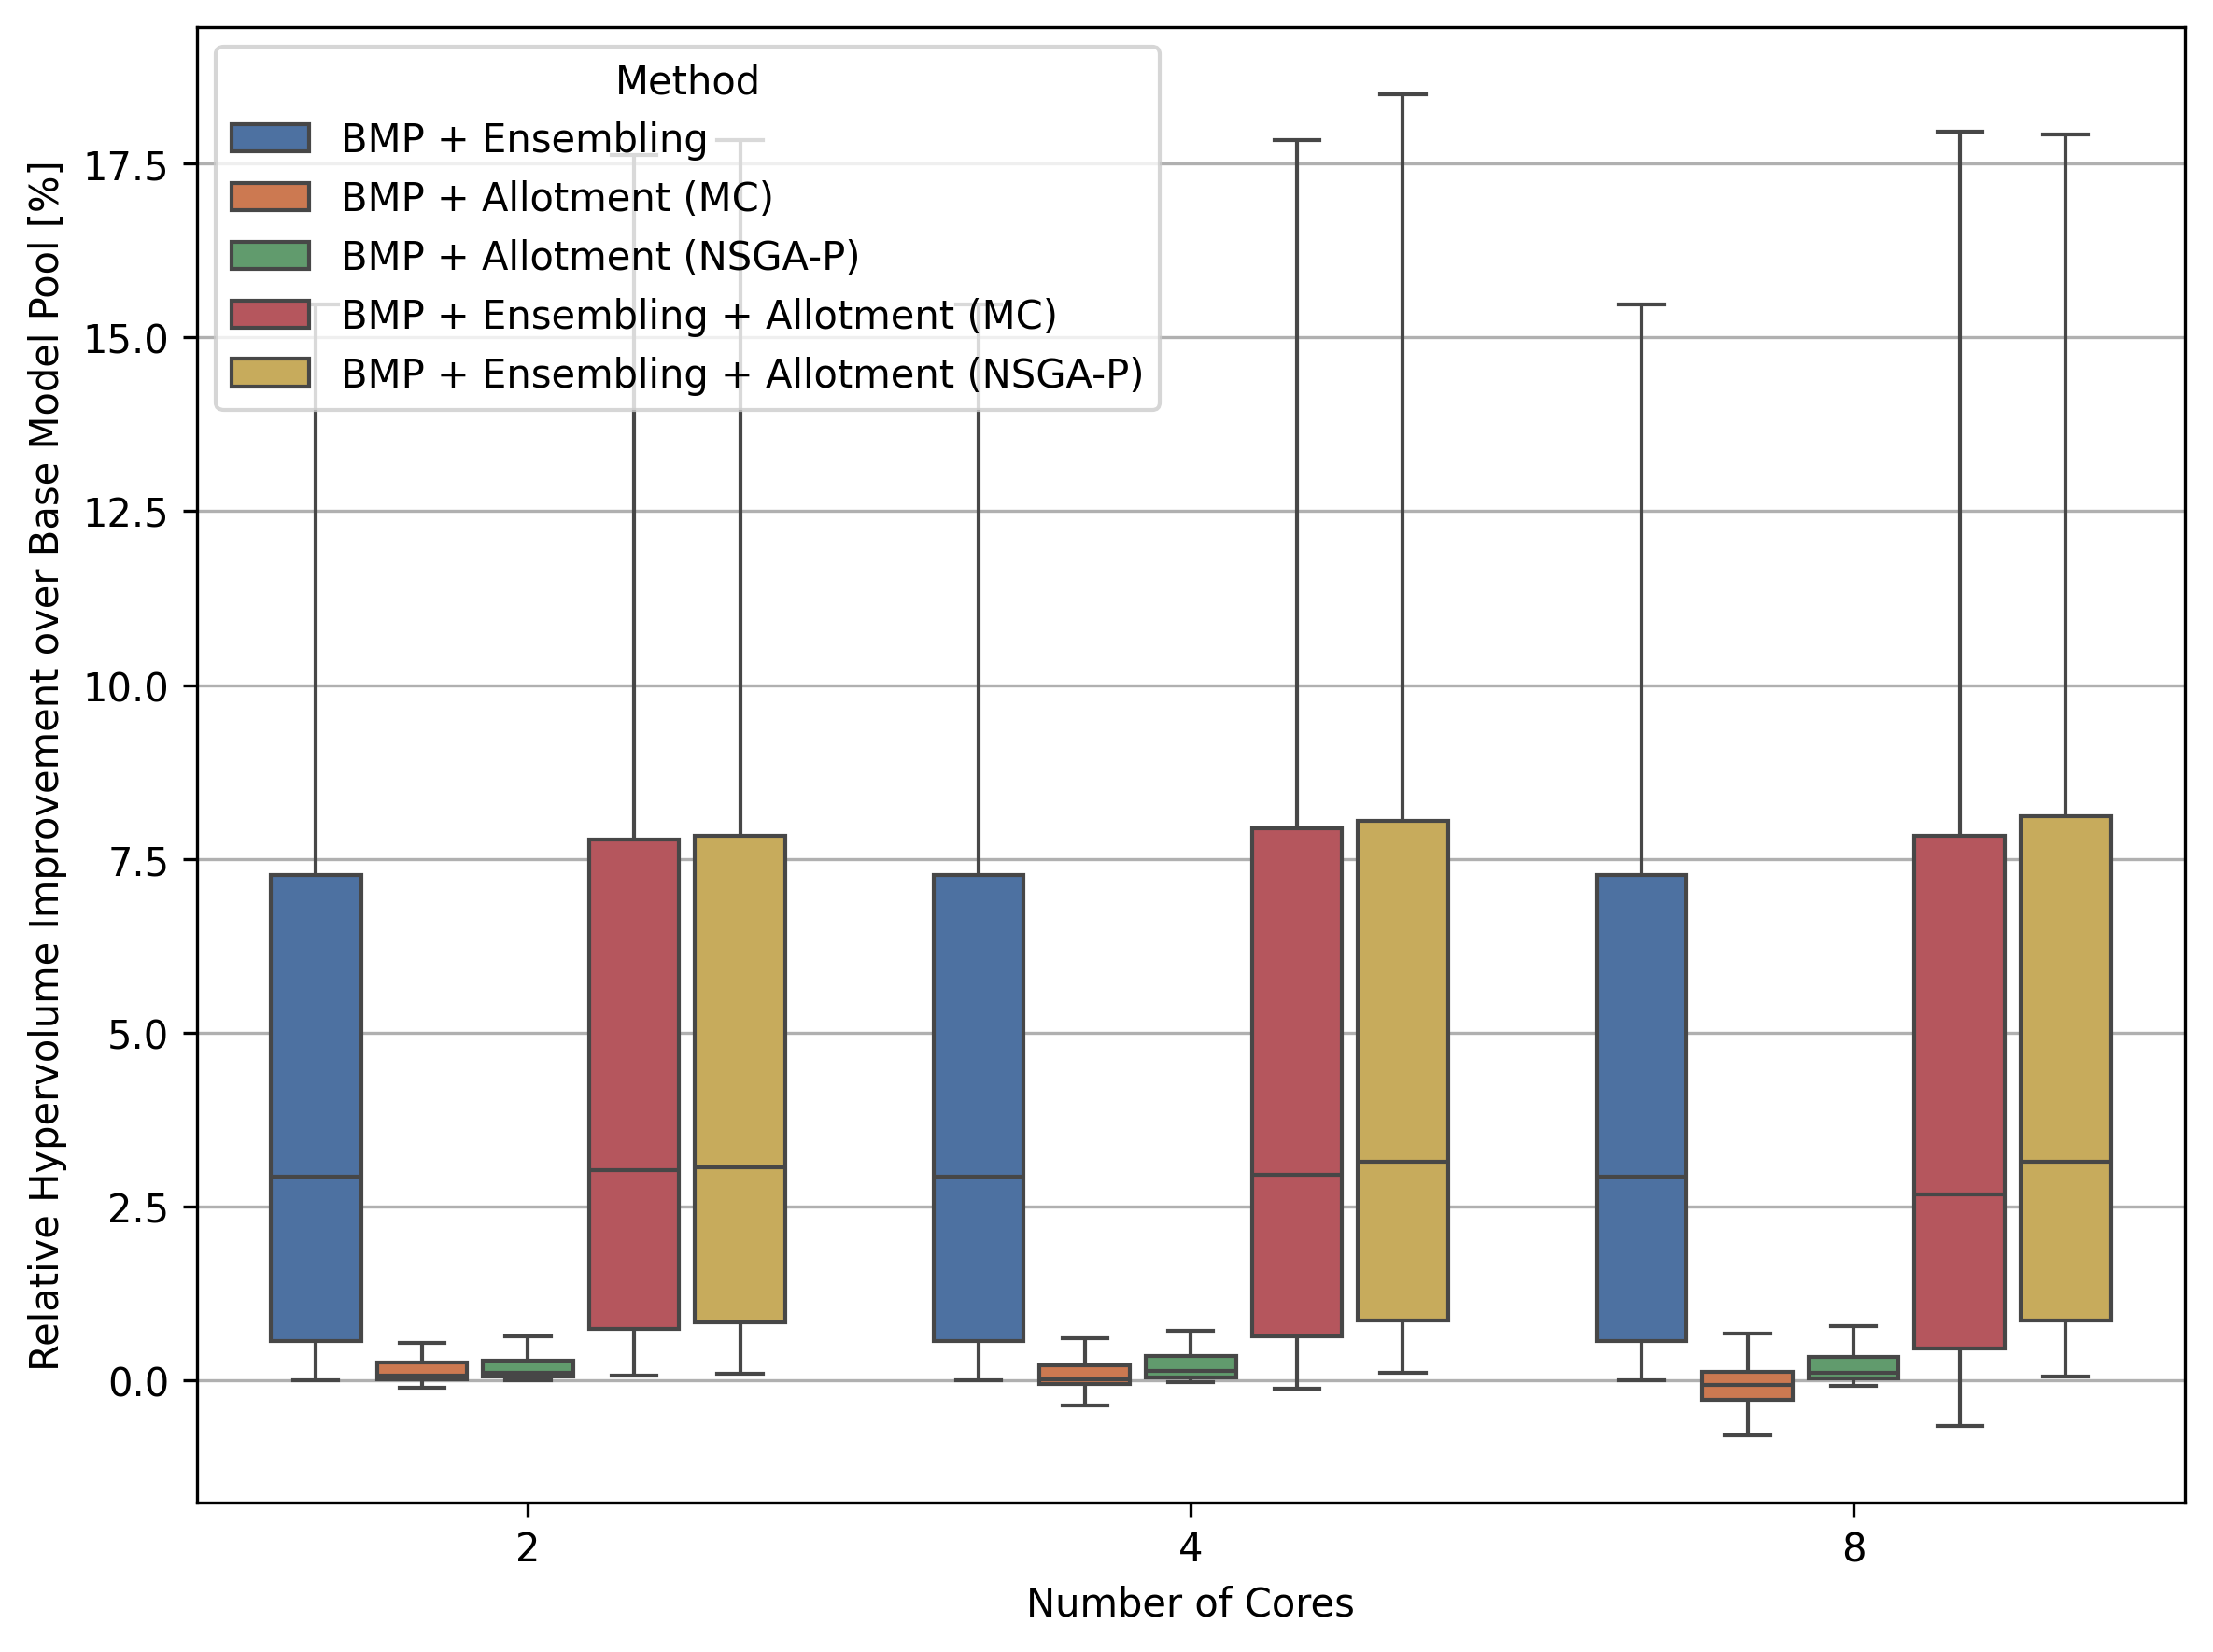

In [42]:
plot_parallel("hv", ensembling_method="mo-ges", bmg="so-asha")

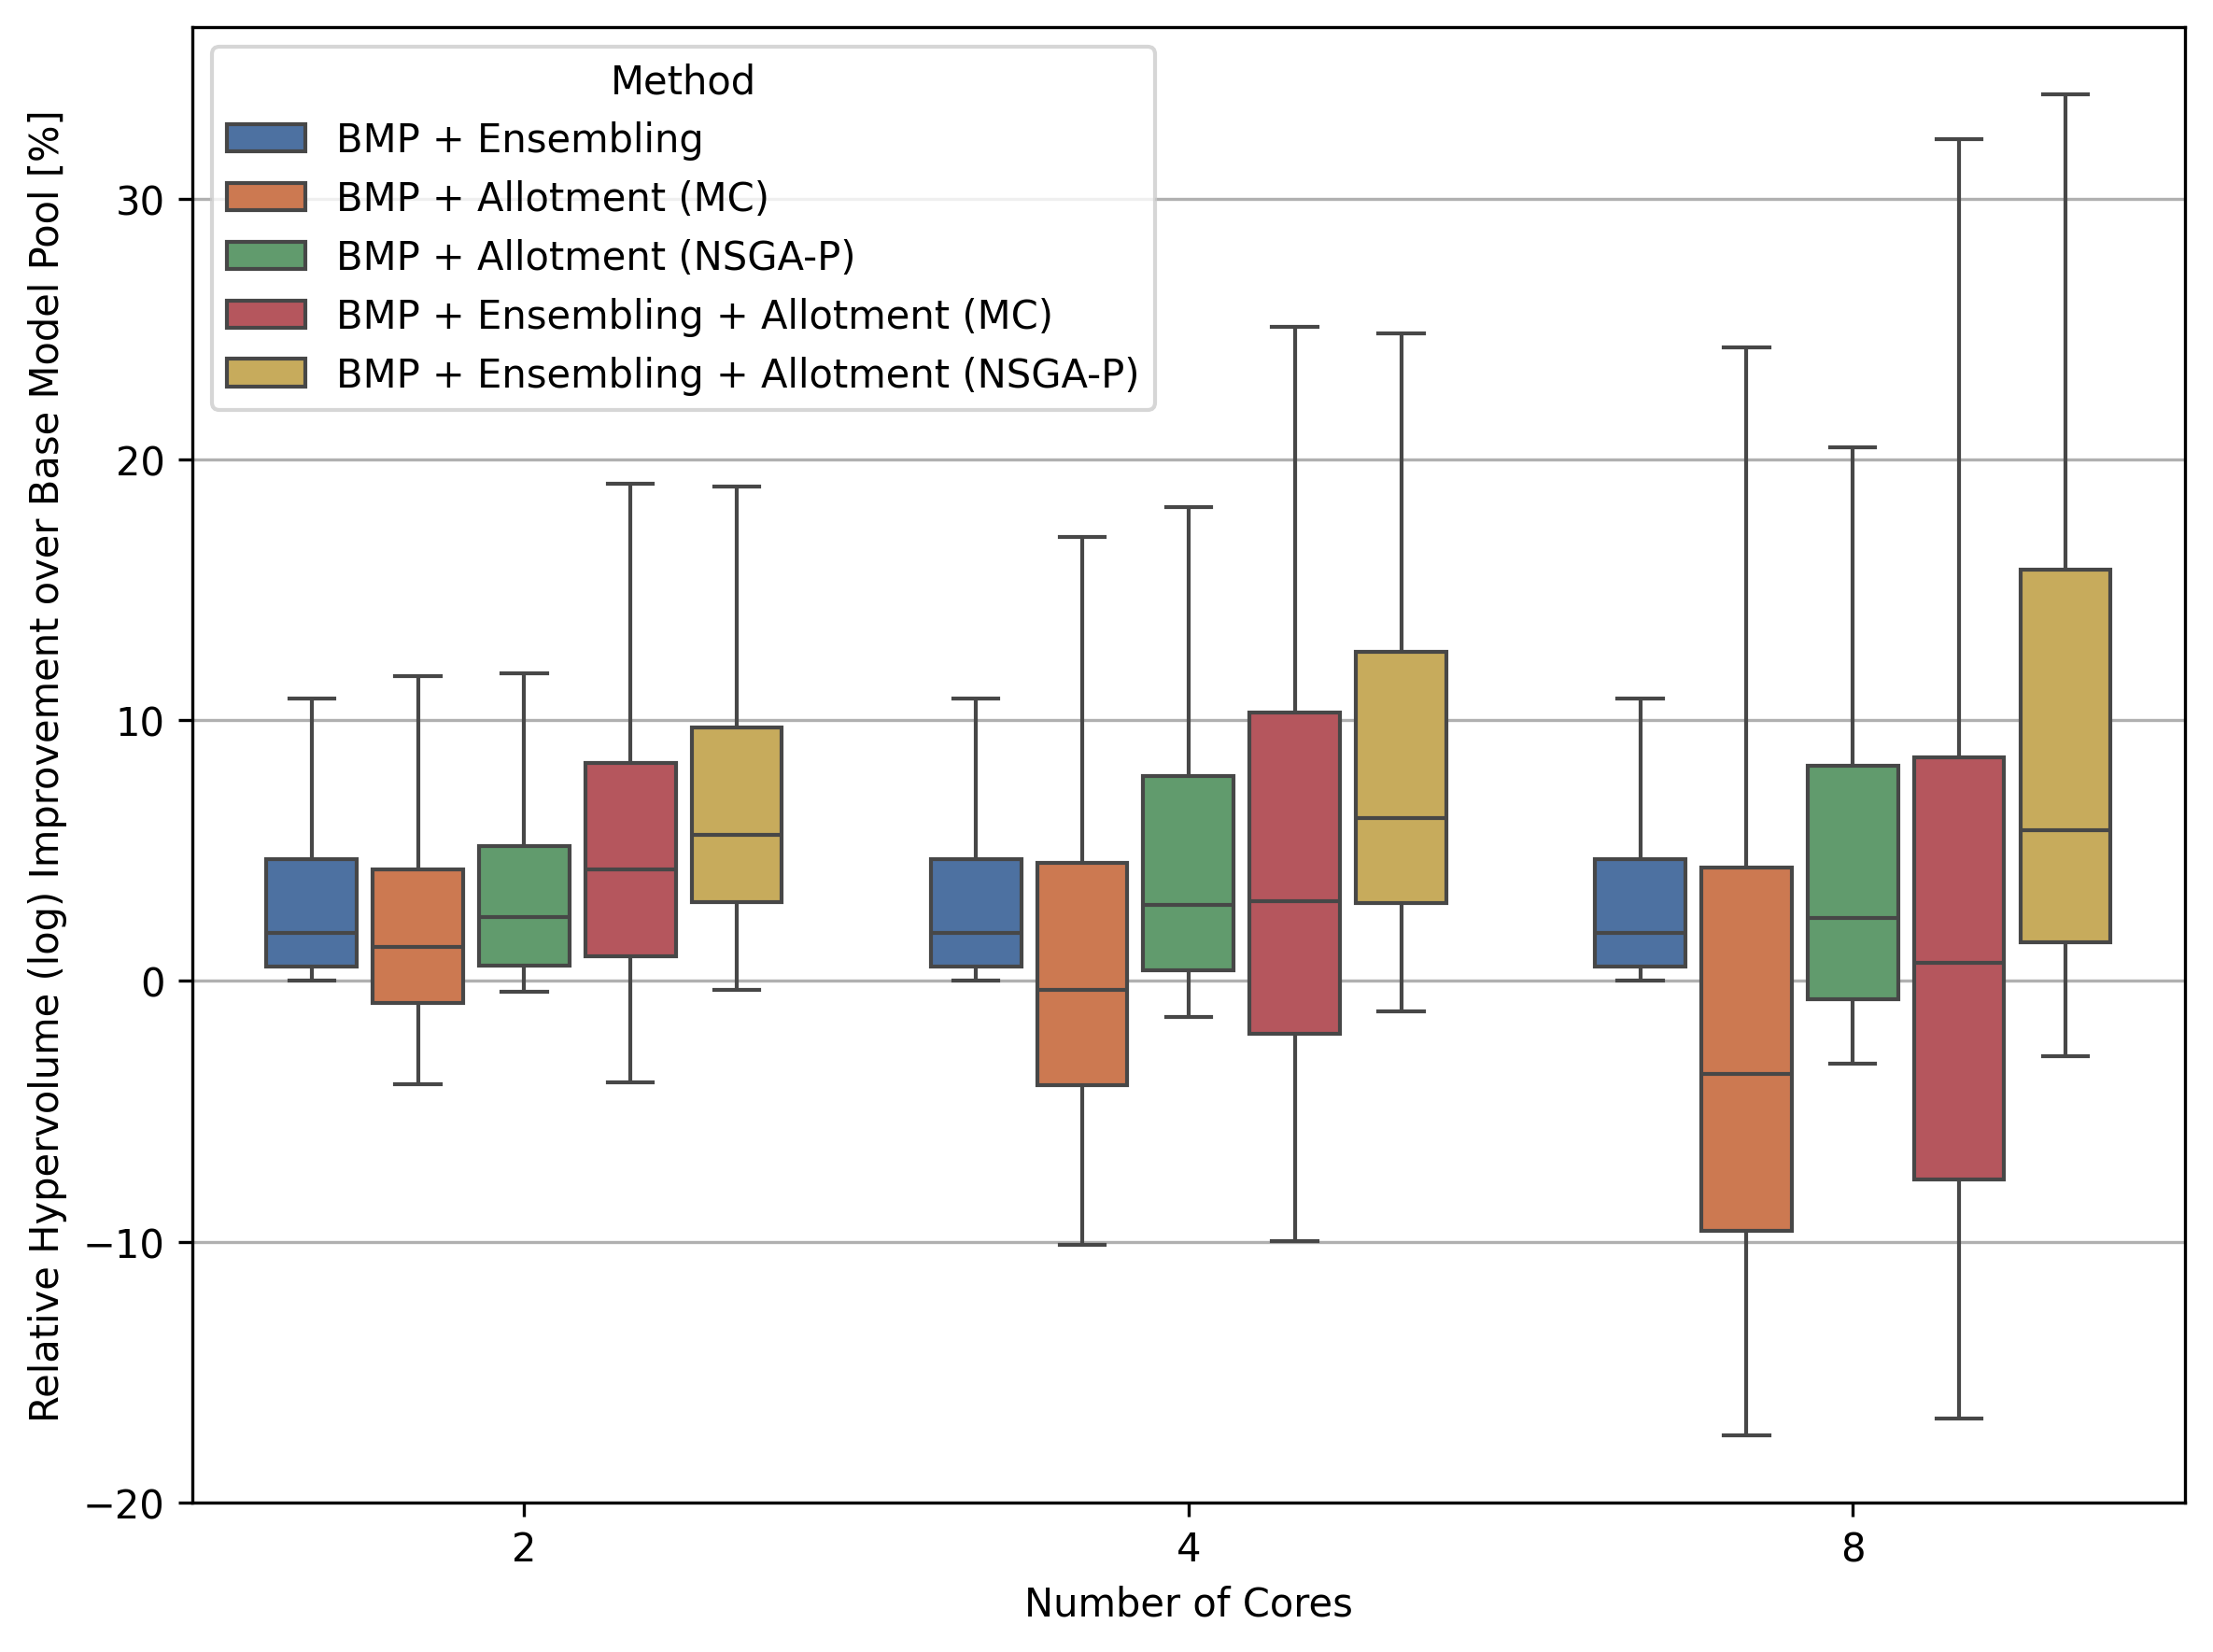

In [43]:
plot_parallel("hv_log", ensembling_method="mo-ges", bmg="mo-smac")

# Frequency Scaling and Parallelization combined

In [44]:
data_both = pd.read_csv('./data/frequency_scaling+parallel_alloted_eps.csv', index_col=0)
data_meta = pd.read_csv('./data/frequency_scaling+parallel_alloted_meta.csv')
data_meta_grouped = data_meta.groupby("pool_index")

In [45]:
data_meta_ens = pd.read_csv("./data/base_ensemble_pools_meta.csv")
data_meta_ens_grouped = data_meta_ens.groupby("pool_index")

In [46]:
def process_job(task_id, seed, bmg_method):
    results = []
    
    try:
        bm_group = data_bm_grouped.get_group((task_id, seed, bmg_method))
    except KeyError:
        for ensembling_method in ENSEMBLING_METHODS:
            for n_cores in [2,4,8]:
                results.append([
                    task_id, seed, bmg_method, ensembling_method, n_cores,
                    [*([0]*8), *([np.nan]*4), *([0]*8),  *([np.nan]*8), *([0]*9)]
                ])
        return results
    
    cols = ["RMSE", "Log Loss", "1 - ROC AUC", "inference_time", "energy_consumption"]
    cols = [col for col in cols if (~bm_group[col].isna()).sum() > 0]
    log_mask = [1,2]
    
    cols_ens = [f"{c}_ens" for c in cols]
    
    assert bm_group["pool_index"].nunique() == 1, "Multiple pools found"

    min, max = min_max_values[task_id]
    min_arr, max_arr = np.array([min[col] for col in cols]), np.array([max[col] for col in cols])
    
    bm_data = bm_group[cols].values
    bm_data_pareto_ens_mask = get_pareto_front(bm_group[cols_ens].values)
    bm_data_pareto_ens_mask_indices = np.where(bm_data_pareto_ens_mask)[0]
    bm_data = bm_data[bm_data_pareto_ens_mask]
    
    bm_hv, bm_hv_log, bm_spread, bm_onvg, bm_n, bm_uniformity, bm_extent, bm_data_orig = compute_metrics_for_data(
        bm_data, min_arr, max_arr, cols, extremes, task_id, log_mask
    )
    bm_avg_gap = np.mean(bm_group["avg_gap"])
    
    for ensembling_method in ENSEMBLING_METHODS:
        try:
            ens_group = data_ens_grouped.get_group((task_id, seed, bmg_method, ensembling_method))
        except KeyError:
            for n_cores in [2,4,8]:
                results.append([
                    task_id, seed, bmg_method, ensembling_method, n_cores,
                    [
                        bm_hv, bm_hv, bm_hv, bm_hv, 
                        bm_hv_log, bm_hv_log, bm_hv_log, bm_hv_log,
                        bm_spread, bm_spread, bm_spread, bm_spread,
                        bm_onvg, bm_onvg, bm_onvg, bm_onvg, 
                        bm_n, bm_n, bm_n, bm_n,
                        bm_uniformity, bm_uniformity, bm_uniformity, bm_uniformity, 
                        bm_extent, bm_extent, bm_extent, bm_extent,
                        bm_avg_gap, bm_avg_gap, bm_avg_gap, bm_avg_gap,
                        0, 0, 0, 0, 0
                    ]                     
                ])
            continue
        
        ens_data = ens_group[cols].values
        ens_data_pareto_ens_mask = get_pareto_front(ens_group[cols_ens].values)
        ens_data_pareto_ens_mask_indices = np.where(ens_data_pareto_ens_mask)[0]
        ens_data = ens_data[ens_data_pareto_ens_mask]
        
        data_bm_ens = np.vstack([bm_data_orig, ens_data])
        bm_ens_hv, bm_ens_hv_log, bm_ens_spread, bm_ens_onvg, bm_ens_n, bm_ens_uniformity, bm_ens_extent, _ = compute_metrics_for_data(
            data_bm_ens, min_arr, max_arr, cols, extremes, task_id, log_mask
        )
        bm_ens_avg_gap = np.mean(ens_group["avg_gap"])
        
        assert ens_group["pool_index"].nunique() == 1, "Multiple pools found in ensemble group"
        ens_pool_index = ens_group["pool_index"].iloc[0]
        meta_ens = data_meta_ens_grouped.get_group(ens_pool_index)
        runtime_ens = meta_ens["runtime"].values[0]
        
        pareto_mask = get_pareto_front(data_bm_ens)
        indicies_pf_bm = np.where(pareto_mask[:len(bm_data_orig)])[0]
        indicies_pf_ens = np.where(pareto_mask[len(bm_data_orig):])[0]
            
        for n_cores in [2,4,8]:
            bm_allotment_group = data_both_grouped.get_group((task_id, seed, bmg_method, "base_model_pool", n_cores))  
            bm_allotment_group_filtered = bm_allotment_group[bm_allotment_group["old_ensemble_index"].astype(int).isin(bm_data_pareto_ens_mask_indices)]
            bm_a_hv, bm_a_hv_log, bm_a_spread, bm_a_onvg, bm_a_n, bm_a_uniformity, bm_a_extent, bm_a_data_orig = compute_metrics_for_data(
                bm_allotment_group_filtered[cols].values, min_arr, max_arr, cols, extremes, task_id, log_mask
            )
            bm_a_avg_gap = np.mean(bm_allotment_group["avg_gap"])
            
            assert bm_allotment_group["pool_index"].nunique() == 1, "Multiple pools found in allotment group"
            bm_a_pool_index = bm_allotment_group["pool_index"].iloc[0]
            meta_bm_a = data_meta_grouped.get_group(bm_a_pool_index)
            
            data_ens_allotment_group = data_both_grouped.get_group((task_id, seed, bmg_method, ensembling_method, n_cores))
            data_ens_allotment_group_filtered = data_ens_allotment_group[
                data_ens_allotment_group["old_ensemble_index"].astype(int).isin(ens_data_pareto_ens_mask_indices)
            ]
            data_bm_ens_a = np.vstack([bm_a_data_orig, data_ens_allotment_group_filtered[cols].values])
            bm_ens_a_hv, bm_ens_a_hv_log, bm_ens_a_spread, bm_ens_a_onvg, bm_ens_a_n, bm_ens_a_uniformity, bm_ens_a_extent, _ = compute_metrics_for_data(
                data_bm_ens_a, min_arr, max_arr, cols, extremes, task_id, log_mask
            )
            bm_ens_a_avg_gap = np.mean(data_ens_allotment_group["avg_gap"])
            
            assert data_ens_allotment_group["pool_index"].nunique() == 1, "Multiple pools found in ens+allotment group"
            ens_a_pool_index = data_ens_allotment_group["pool_index"].iloc[0]
            meta_ens_a = data_meta_grouped.get_group(ens_a_pool_index)
            
            runtime_bm_a = meta_bm_a["runtime"].values[0]
            runtime_ens_a = meta_ens_a["runtime"].values[0]
            
            runtime_est_bm_a_pf = runtime_bm_a * (len(bm_allotment_group_filtered) / len(bm_allotment_group))
            runtime_est_bm_ens_a_pf = runtime_ens_a * (len(data_ens_allotment_group_filtered) / len(data_ens_allotment_group))
            
            results.append([
                task_id, seed, bmg_method, ensembling_method, n_cores,
                [
                    bm_hv, bm_ens_hv, bm_a_hv, bm_ens_a_hv, 
                    bm_hv_log, bm_ens_hv_log, bm_a_hv_log, bm_ens_a_hv_log, 
                    bm_spread, bm_ens_spread, bm_a_spread, bm_ens_a_spread,
                    bm_onvg, bm_ens_onvg, bm_a_onvg, bm_ens_a_onvg, 
                    bm_n, bm_ens_n, bm_a_n, bm_ens_a_n, 
                    bm_uniformity, bm_ens_uniformity, bm_a_uniformity, bm_ens_a_uniformity, 
                    bm_extent, bm_ens_extent, bm_a_extent, bm_ens_a_extent, 
                    bm_avg_gap, bm_ens_avg_gap, bm_a_avg_gap, bm_ens_a_avg_gap, 
                    runtime_bm_a, runtime_ens_a, runtime_est_bm_a_pf, runtime_est_bm_ens_a_pf, runtime_ens
                ]
            ])
            
    return results

In [47]:
print(data_both.memory_usage(deep=True))

Index                  420836880
RMSE                   420836880
inference_time         420836880
energy_consumption     420836880
ensemble_size          420836880
avg_gap                420836880
old_ensemble_index     420836880
task_id                420836880
seed                   420836880
bmg_method            3337640443
pool_index             420836880
n_cores                420836880
scheduler             3173752491
allotment_method      3261485820
ensembling_method     3435516244
Log Loss               420836880
1 - ROC AUC            420836880
dtype: int64


In [48]:
assert data_both["allotment_method"].nunique() == 1, "Multiple allotment methods found"
data_both = data_both[(data_both["scheduler"] == "lpt")]
data_both["bmg_method"] = data_both["bmg_method"].astype("category")
data_both["ensembling_method"] = data_both["ensembling_method"].astype("category")
data_both.drop(columns=["allotment_method", "scheduler"], inplace=True)

data_both_grouped = data_both.groupby(["task_id", "seed", "bmg_method", "ensembling_method", "n_cores"])

gc.collect()

/tmp/ipykernel_7777/850628311.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_both_grouped = data_both.groupby(["task_id", "seed", "bmg_method", "ensembling_method", "n_cores"])


19288

In [49]:
print(data_both.memory_usage(deep=True))

Index                 140588288
RMSE                  140588288
inference_time        140588288
energy_consumption    140588288
ensemble_size         140588288
avg_gap               140588288
old_ensemble_index    140588288
task_id               140588288
seed                  140588288
bmg_method             17574089
pool_index            140588288
n_cores               140588288
ensembling_method      17574301
Log Loss              140588288
1 - ROC AUC           140588288
dtype: int64


In [50]:
METRICS_ORDER_BOTH = [
    "hv_bmp", "hv_bmp+ens", "hv_bmp_allotment", "hv_bmp+ens_allotment", 
    "hv_log_bmp", "hv_log_bmp+ens", "hv_log_bmp_allotment", "hv_log_bmp+ens_allotment", 
    "spread_bmp", "spread_bmp+ens", "spread_bmp_allotment", "spread_bmp+ens_allotment", 
    "onvg_bmp", "onvg_bmp+ens", "onvg_bmp_allotment", "onvg_bmp+ens_allotment", 
    "n_bmp", "n_bmp+ens", "n_bmp_allotment", "n_bmp+ens_allotment",
    "uniformity_bmp", "uniformity_bmp+ens", "uniformity_bmp_allotment", "uniformity_bmp+ens_allotment", 
    "extent_bmp", "extent_bmp+ens", "extent_bmp_allotment", "extent_bmp+ens_allotment", 
    "avg_gap_bmp", "avg_gap_bmp+ens", "avg_gap_bmp_allotment", "avg_gap_bmp+ens_allotment", 
    "runtime_bmp_allotment", "runtime_ens_allotment", "runtime_est_bmp_allotment_pf", "runtime_est_ens_allotment_pf", "runtime_ensembling"
]

N_CORES_LIST = [2,4,8]

results_both = np.zeros((len(TASK_IDS), len(SEEDS), len(BMG_METHODS), len(ENSEMBLING_METHODS), len(N_CORES_LIST), len(METRICS_ORDER_BOTH))) 

def process_wrapper(args):
    task_id, seed, bmg_method = args
    res = process_job(task_id, seed, bmg_method)
    return res

if os.path.exists("./data/processed_data/parallel_allot_processed_full.npy") and USE_CACHED_RESULTS:
    results_parallel_full = np.load("./data/processed_data/parallel_allot_processed_full.npy")
    results_parallel_nsga2 = np.load("./data/processed_data/parallel_allot_processed_nsga2.npy")
else:
    jobs = list(product(TASK_IDS, SEEDS, BMG_METHODS))
    full_comp_results = []
    
    with ProcessPoolExecutor(max_workers=8) as executor:
        for results_list in tqdm.tqdm(
            executor.map(process_wrapper, jobs),
            total=len(jobs)
        ):
            for result in results_list:
                task_id, seed, bmg_method, ensembling_method, n_cores, metrics = result
                t_idx = TASK_IDS.index(task_id)
                s_idx = SEEDS.index(seed)
                bmg_idx = BMG_METHODS.index(bmg_method)
                ens_idx = ENSEMBLING_METHODS.index(ensembling_method)
                n_cores_idx = N_CORES_LIST.index(n_cores)
                results_both[t_idx, s_idx, bmg_idx, ens_idx, n_cores_idx, :] = np.array(metrics)
                
                
    # for job in tqdm.tqdm(jobs):
    #     results_list = process_wrapper(job)
    #     for result in results_list:
    #         task_id, seed, bmg_method, ensembling_method, n_cores, metrics = result
    #         t_idx = TASK_IDS.index(task_id)
    #         s_idx = SEEDS.index(seed)
    #         bmg_idx = BMG_METHODS.index(bmg_method)
    #         ens_idx = ENSEMBLING_METHODS.index(ensembling_method)
    #         n_cores_idx = N_CORES_LIST.index(n_cores)
    #         results_both[t_idx, s_idx, bmg_idx, ens_idx, n_cores_idx, :] = np.array(metrics)
            
    
    np.save("./data/processed_data/both_allot_processed_full.npy", results_both)

100%|██████████| 3120/3120 [00:52<00:00, 58.99it/s] 


In [51]:
def plot_combined(metric_name="hv", ensembling_method="mo-ges", bmg = "mo-smac", metric_rename=None, save_path=None, mode="max"):
    metric_indices_both = [METRICS_ORDER_BOTH.index(f"{metric_name}_{x}") for x in ["bmp", "bmp+ens", "bmp_allotment", "bmp+ens_allotment"]]
    metric_indices = [METRICS_ORDER.index(f"{metric_name}_{x}") for x in ["bmp", "bmp+ens", "bmp_allotment", "bmp+ens_allotment"]]
    scheduling_index = SCHEDULING_STRATEGIES.index("lpt")
    ensembling_method_idx = ENSEMBLING_METHODS.index(ensembling_method)
    allotment_method_idx = ALLOTMENT_STRATEGIES.index("nsga2")
    bmg_idx = BMG_METHODS.index(bmg)
    
    group_member_labels = ["BMP + Ensembling", "BMP + Allotment (NSGA-FS)", "BMP + Ensembling + Allotment (NSGA-FS)", "BMP + Allotment (NSGA-P)", "BMP + Ensembling + Allotment (NSGA-P)", "BMP + Allotment (NSGA-FS+P)", "BMP + Ensembling + Allotment (NSGA-FS+P)"]
    
    group_data = []
    for n_cores in N_CORES_LIST:
        n_cores_idx = N_CORES_LIST.index(n_cores)
        
        data_nsga2_p = results_parallel_nsga2[:, :, bmg_idx, ensembling_method_idx, scheduling_index, n_cores_idx, metric_indices]  # Shape: 104,5,4
        data_nsga2_p = data_nsga2_p.mean(axis=1)  # Average over seeds -> Shape: 104, 4
        
        data_nsga2_fs = results_fs[:, :, bmg_idx, ensembling_method_idx, allotment_method_idx, metric_indices]  # Shape: 104,5,4
        data_nsga2_fs = data_nsga2_fs.mean(axis=1)  # Average over seeds -> Shape: 104, 4
        
        data_nsga2_combined = results_both[:, :, bmg_idx, ensembling_method_idx, n_cores_idx, metric_indices_both]  # Shape: 104,5,4
        data_nsga2_combined = data_nsga2_combined.mean(axis=1)  # Average over seeds -> Shape: 104, 4

        assert np.allclose(data_nsga2_p[:, 0], data_nsga2_fs[:, 0]), f"Base model pool metrics do not match!"
        assert np.allclose(data_nsga2_p[:, 0], data_nsga2_combined[:, 0]), "Base model pool metrics do not match!"

        assert np.allclose(data_nsga2_fs[:, 1], data_nsga2_combined[:, 1]), "Ensembling metrics do not match!"
        assert np.allclose(data_nsga2_p[:, 1], data_nsga2_combined[:, 1]), "Ensembling metrics do not match!"

        data_nsga2_p_rel = data_nsga2_p[:, 1:] / (data_nsga2_p[:, 0:1] + 1e-12) - 1
        data_nsga2_fs_rel = data_nsga2_fs[:, 1:] / (data_nsga2_fs[:, 0:1] + 1e-12) - 1
        data_nsga2_combined_rel = data_nsga2_combined[:, 1:] / (data_nsga2_combined[:, 0:1] + 1e-12) - 1
        
        data_combined = [
            data_nsga2_p_rel[:, 0], 
            data_nsga2_fs_rel[:, 1], data_nsga2_fs_rel[:, 2],
            data_nsga2_p_rel[:, 1], data_nsga2_p_rel[:,2],
            data_nsga2_combined_rel[:, 1], data_nsga2_combined_rel[:, 2]
        ] 
        if mode == "min":
            data_combined = [-data for data in data_combined]
        
        for key, vals in zip(group_member_labels, data_combined):
            for val in vals:
                group_data.append({
                    "Number of Cores": n_cores,
                    "Method": key,
                    "improvement": val * 100
                })
    
    df = pd.DataFrame(group_data)
    df = df[df["Method"].isin(group_member_labels)]
            
    fig, ax = plt.subplots(figsize=(8, 6), dpi=DPI)
    sns.boxplot(
        data=df,
        x="Number of Cores",
        y="improvement",
        hue="Method",
        palette=COLOR_LIST[:len(group_member_labels)],
        ax=ax,
        showfliers=False,
        gap=0.15
    )
    ax.grid(axis='y')
    ax.set_xlabel("Number of Cores")
    ax.set_ylabel(f"Relative {METRIC_MAP[metric_name] if metric_rename is None else metric_rename} Improvement over Base Model Pool [%]")
    ax.legend(title="Method")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=DPI, bbox_inches='tight')
    else:
        plt.show()

In [226]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DPI = 300


def plot_bars(
    labels_cols,
    matrix,
    groups_dict,
    save_path=None,
    figsize=(4.5, 6),
    focus_indices=None,
    x_offset=0.6,
    group_focus_keys=None,
    equal_x_limits=False,
):
    # ---- build grouped bar order ----
    labels_bars = []
    y_positions = []
    group_centers = {}
    group_ranges = {}

    y = 0
    for group, bars in groups_dict.items():
        start = y
        for bar in bars:
            labels_bars.append(bar)
            y_positions.append(y)
            y += 1
        end = y - 1
        group_centers[group] = (start + end) / 2
        group_ranges[group] = (start - 0.4, end + 0.4)
        y += 0.5  # gap between groups

    y_positions = np.array(y_positions)

    n_cols = len(labels_cols)
    n_datasets = matrix.shape[2]

    mean = np.mean(matrix, axis=2)
    std = np.std(matrix, axis=2)
    std = std / np.sqrt(n_datasets)
    std = 1.96 * std  # 95% CI

    fig, ax = plt.subplots(figsize=figsize, ncols=n_cols, sharey=True)
    
    max = -np.inf

    # ---- plot bars ----
    for i, label_col in enumerate(labels_cols):
        values = mean[:, i]

        nonzero_mask = values != 0
        colors = np.zeros((values.shape[0], 4))
        colors[:, 3] = 1.0
        colors[~nonzero_mask, :3] = 0.0
        if np.any(nonzero_mask):
            vmin = values[nonzero_mask].min()
            vmax = values[nonzero_mask].max()
            normed = (values[nonzero_mask] - vmin) / (vmax - vmin + 1e-9)

            cmap = sns.color_palette(
                "blend:#4fa3d1,#3fbf7f",
                as_cmap=True
            )
            colors[nonzero_mask] = cmap(normed)

        focus_mask = np.zeros(len(values), dtype=bool)
        focus_mask[focus_indices] = True
        if focus_indices is not None:
            colors[~focus_mask, :3] = 0.7
            colors[~focus_mask, 3] = 0.3
            colors[focus_mask, 3] = 1.0
        
        ax[i].barh(
            y_positions,
            mean[:, i],
            #xerr=std[:, i],
            color=colors,
            #error_kw=dict(ecolor="black", lw=0.7, alpha=0.8),
        )
        
        max = np.max([max, np.max(mean[:, i])])
        
        # Plot error bars manually with per-bar colors
        for yi, val, err, mask in zip(y_positions, mean[:, i], std[:, i], focus_mask):
            ax[i].errorbar(
                x=val,
                y=yi,
                xerr=err,
                fmt='none',
                ecolor='black' if mask else 'lightgray',  # per-bar error color
                lw=0.7,
                alpha=0.8,
                capsize=0,
            )

        ax[i].set_yticks(y_positions)
        ax[i].set_yticklabels(labels_bars)
        ax[i].set_xlabel(label_col)

        ax[i].spines["top"].set_visible(False)
        ax[i].spines["right"].set_visible(False)
        ax[i].spines["left"].set_visible(False)
        ax[i].yaxis.set_tick_params(length=0)
        ax[i].grid(axis="x", linestyle=":", alpha=0.6)
        
    if equal_x_limits:
        for a in ax:
            a.set_xlim(0, max + 0.05 * abs(max))

    # invert shared y-axis ONCE
    ax[0].invert_yaxis()

    # ---- font styling ----
    for a in ax:
        for label in a.get_yticklabels():
            label.set_fontsize(7)

    if focus_indices is not None:
        for i, label in enumerate(ax[0].get_yticklabels()):
            if i not in focus_indices:
                label.set_color("gray")
                label.set_alpha(0.4)
            else:
                label.set_color("black")
                label.set_alpha(1.0)

    # ---- group brackets + rotated labels ----
    bracket_ax = ax[0].twinx()
    bracket_ax.set_ylim(ax[0].get_ylim())
    bracket_ax.set_yticks([])
    #bracket_ax.set_xticks([])

    for spine in bracket_ax.spines.values():
        spine.set_visible(False)

    x_bracket = -x_offset # position in axes coords
    
    for group, (y0, y1) in group_ranges.items():
        # vertical line
        bracket_ax.plot(
            [x_bracket, x_bracket],
            [y0, y1],
            transform=bracket_ax.get_yaxis_transform(),
            color="black",
            lw=0.8,
            clip_on=False,
        )

        # top & bottom ticks
        bracket_ax.plot(
            [x_bracket, x_bracket + 0.02],
            [y0, y0],
            transform=bracket_ax.get_yaxis_transform(),
            color="black",
            lw=0.8,
            clip_on=False,
        )
        bracket_ax.plot(
            [x_bracket, x_bracket + 0.02],
            [y1, y1],
            transform=bracket_ax.get_yaxis_transform(),
            color="black",
            lw=0.8,
            clip_on=False,
        )

        # rotated group label
        bracket_ax.text(
            x_bracket - x_offset * 0.1,
            group_centers[group],
            group,
            rotation=90,
            va="center",
            ha="center",
            fontsize=8,
            fontweight="bold" if ((group_focus_keys is None) or (group in group_focus_keys)) else "normal",
            color="black" if ((group_focus_keys is None) or (group in group_focus_keys)) else "gray",
            transform=bracket_ax.get_yaxis_transform(),
        )

    # ---- save or show ----
    if save_path is not None:
        plt.savefig(save_path, dpi=DPI, bbox_inches="tight")
    else:
        plt.tight_layout()
        plt.show()


In [242]:
def plot_combined2(metric_names=["hv_log", "onvg"], ensembling_method="mo-ges", bmg = "mo-smac", metric_renames=None, save_path=None, focus_indices=None, group_focus_keys=None, x_offset=0.6, mode="max"):    
    scheduling_index = SCHEDULING_STRATEGIES.index("lpt")
    ensembling_method_idx = ENSEMBLING_METHODS.index(ensembling_method)
    allotment_method_idx_nsga2 = ALLOTMENT_STRATEGIES.index("nsga2")
    allotment_method_idx_full = ALLOTMENT_STRATEGIES.index("full")
    bmg_idx = BMG_METHODS.index(bmg)
    
    data_plot = {name: [] for name in metric_names}
    treatment_labels = []
    col_labels = metric_names if metric_renames is None else metric_renames
    
    for i, metric_name in enumerate(metric_names):
        metric_indices_both = [METRICS_ORDER_BOTH.index(f"{metric_name}_{x}") for x in ["bmp", "bmp+ens", "bmp_allotment", "bmp+ens_allotment"]]
        metric_indices = [METRICS_ORDER.index(f"{metric_name}_{x}") for x in ["bmp", "bmp+ens", "bmp_allotment", "bmp+ens_allotment"]]
        
        baseline_full = results_parallel_full[:, :, bmg_idx, ensembling_method_idx, N_CORES_LIST.index(2), metric_indices].mean(axis=1)
        baseline = baseline_full[:, 0:1]
        
        # Baseline entries
        if i == 0:
            treatment_labels.append("MO-SMAC")
            treatment_labels.append("MO-SMAC + MO-GES\n(Base)")
        data_plot[metric_name].append([0 for _ in range(len(TASK_IDS))])
        data_plot[metric_name].append(baseline_full[:, 1:2] / (baseline + 1e-12) - 1)
        
        # Frequency Scaling only
        data_nsga2_fs = results_fs[:, :, bmg_idx, ensembling_method_idx, allotment_method_idx_nsga2, metric_indices]  # Shape: 104,5,4
        data_nsga2_fs = data_nsga2_fs.mean(axis=1)  # Average over seeds -> Shape: 104, 4
        data_nsga2_fs_rel = data_nsga2_fs[:, 1:] / baseline - 1
        
        data_ffs_fs = results_fs[:, :, bmg_idx, ensembling_method_idx, allotment_method_idx_full, metric_indices]  # Shape: 104,5,4
        data_ffs_fs = data_ffs_fs.mean(axis=1)  # Average over seeds -> Shape: 104, 4
        data_ffs_fs_rel = data_ffs_fs[:, 1:] / baseline - 1
        
        if i == 0:
            treatment_labels.append("Base + FFS")
            treatment_labels.append("Base + NSGA-FS")
        
        data_plot[metric_name].append(data_ffs_fs_rel[:, 2])
        data_plot[metric_name].append(data_nsga2_fs_rel[:, 2])
        
        # Parallelisation only
        for n_cores in N_CORES_LIST:
            n_cores_idx = N_CORES_LIST.index(n_cores)
            
            data_nsga2_p = results_parallel_nsga2[:, :, bmg_idx, ensembling_method_idx, scheduling_index, n_cores_idx, metric_indices]  # Shape: 104,5,4
            data_nsga2_p = data_nsga2_p.mean(axis=1)  # Average over seeds -> Shape: 104, 4
            data_nsga2_p_rel = data_nsga2_p[:, 1:] / baseline - 1
            
            data_full_p = results_parallel_full[:, :, bmg_idx, ensembling_method_idx, n_cores_idx, metric_indices]  # Shape: 104,5,4
            data_full_p = data_full_p.mean(axis=1)  # Average over seeds -> Shape: 104, 4
            data_full_p_rel = data_full_p[:, 1:] / baseline - 1
            
            if i == 0:
                treatment_labels.append(f"Base + MC ({n_cores} Cores)")
                treatment_labels.append(f"Base + NSGA-P ({n_cores} Cores)")
            
            data_plot[metric_name].append(data_full_p_rel[:, 2])
            data_plot[metric_name].append(data_nsga2_p_rel[:, 2])
            
        # Combined effects
        for n_cores in N_CORES_LIST:
            n_cores_idx = N_CORES_LIST.index(n_cores)
            
            data_nsga2_combined = results_both[:, :, bmg_idx, ensembling_method_idx, n_cores_idx, metric_indices_both]  # Shape: 104,5,4
            data_nsga2_combined = data_nsga2_combined.mean(axis=1)  # Average over seeds -> Shape: 104, 4
            data_nsga2_combined_rel = data_nsga2_combined[:, 1:] / baseline - 1
            
            if i == 0:
                treatment_labels.append(f"Base + NSGA-FS+P ({n_cores} Cores)")
            
            data_plot[metric_name].append(data_nsga2_combined_rel[:, 2])
    
    data_arr = np.zeros((len(treatment_labels), len(metric_names), len(TASK_IDS))) + np.nan
    for i, metric_name in enumerate(metric_names):
        for j in range(len(treatment_labels)):
            data_arr[j, i, :] = np.array(data_plot[metric_name][j]).squeeze()
    data_arr = 100 * data_arr
    
    if mode == "min":
        data_arr = -data_arr
            
    groups_dict = {
        "Baseline": [treatment_labels[0], treatment_labels[1]],
        "Frequency\nScaling": [treatment_labels[2], treatment_labels[3]],
        "Parallelisation": treatment_labels[4:10],
        "Frequency Scaling &\nParallelisation": treatment_labels[10:],
    }        
    
    plot_bars(col_labels, data_arr, groups_dict, save_path=save_path, focus_indices=focus_indices, figsize=(8, 6), group_focus_keys=group_focus_keys, x_offset=x_offset)

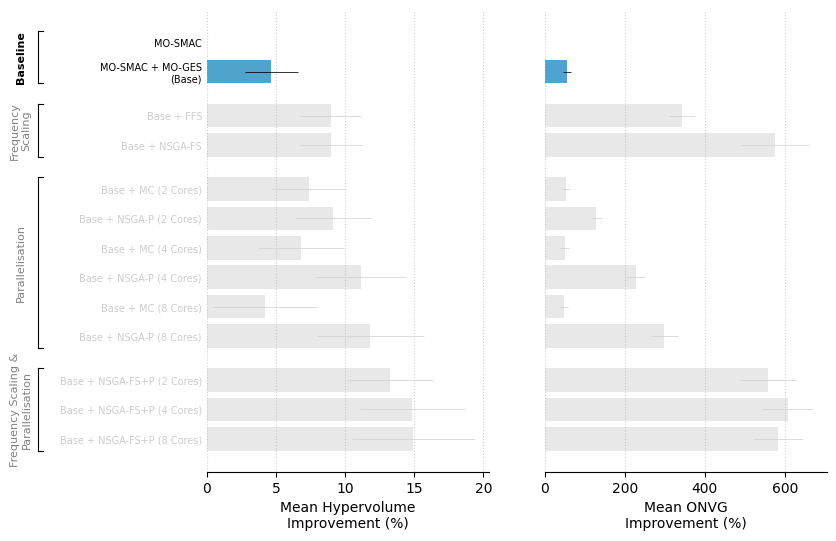

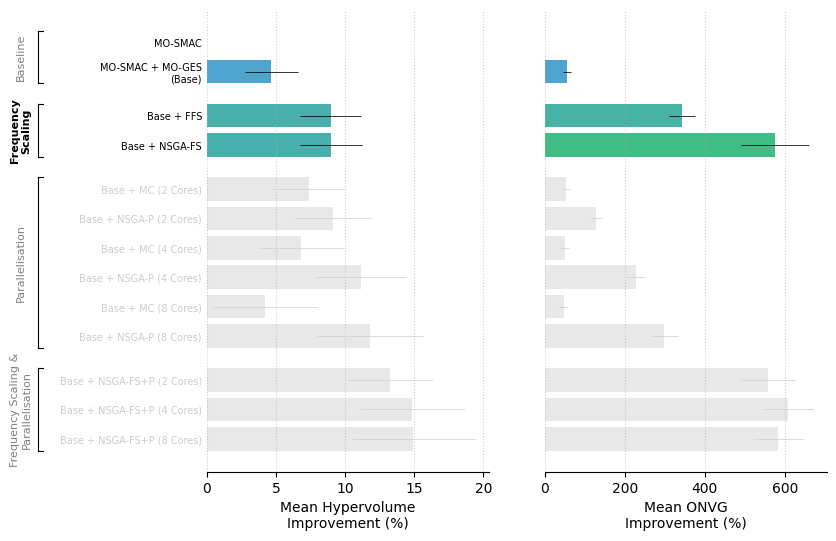

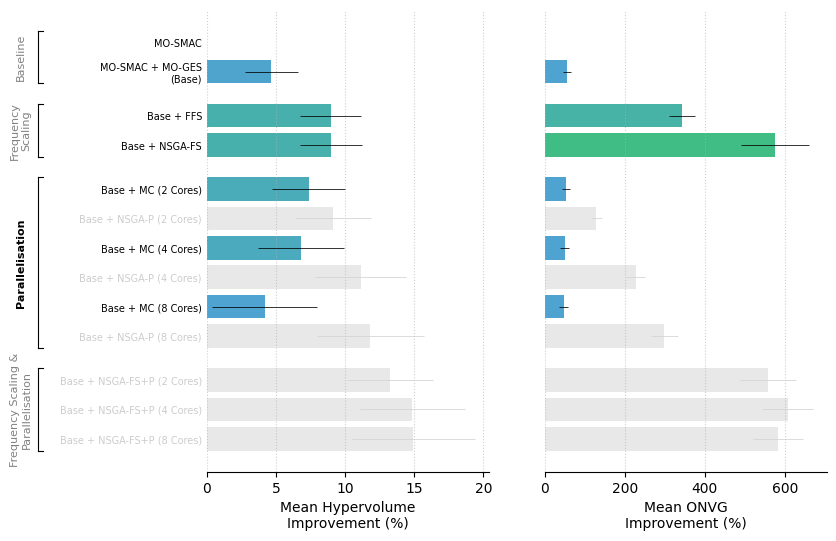

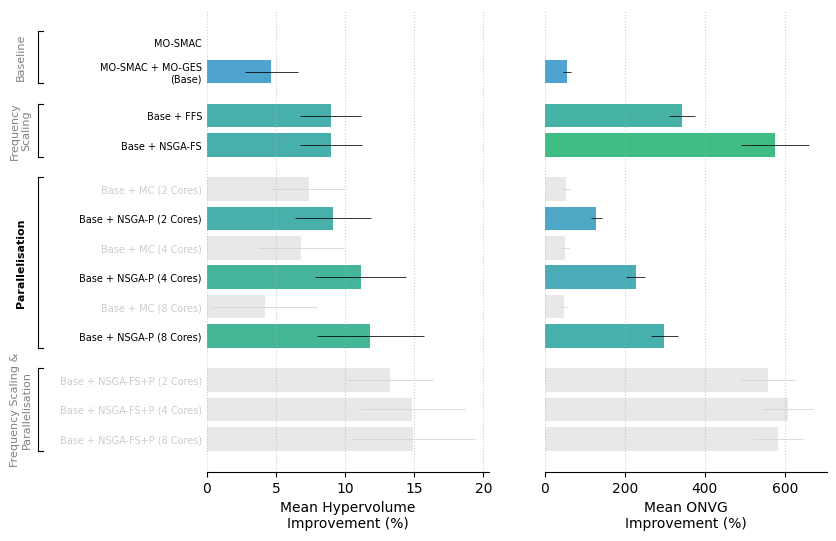

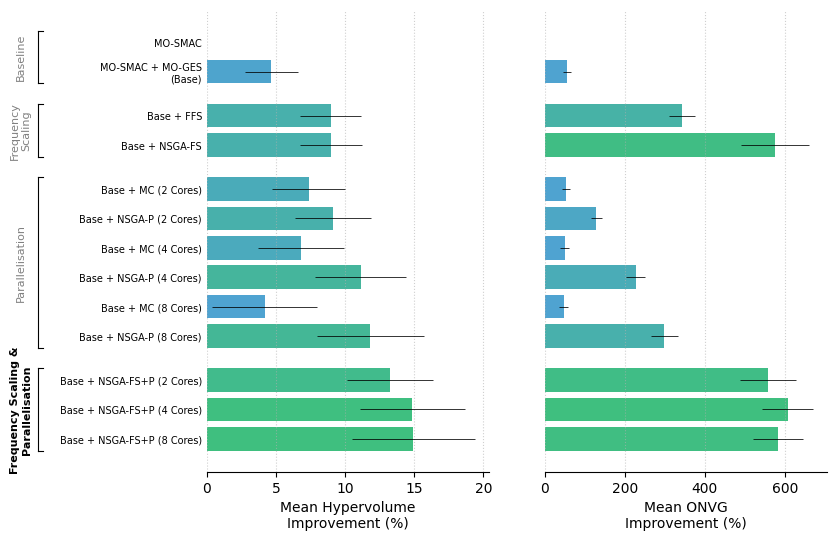

In [243]:
plot_combined2(metric_names=["hv_log", "onvg"], metric_renames=["Mean Hypervolume\nImprovement (%)", "Mean ONVG\nImprovement (%)"], save_path="./figures/combined/summary_0.pdf", focus_indices=[0, 1], group_focus_keys=["Baseline"])
plot_combined2(metric_names=["hv_log", "onvg"], metric_renames=["Mean Hypervolume\nImprovement (%)", "Mean ONVG\nImprovement (%)"], save_path="./figures/combined/summary_1.pdf", focus_indices=[0, 1, 2, 3], group_focus_keys=["Frequency\nScaling"])
plot_combined2(metric_names=["hv_log", "onvg"], metric_renames=["Mean Hypervolume\nImprovement (%)", "Mean ONVG\nImprovement (%)"], save_path="./figures/combined/summary_2.pdf", focus_indices=[0,1,2,3,4,6,8], group_focus_keys=["Parallelisation"])
plot_combined2(metric_names=["hv_log", "onvg"], metric_renames=["Mean Hypervolume\nImprovement (%)", "Mean ONVG\nImprovement (%)"], save_path="./figures/combined/summary_3.pdf", focus_indices=[0,1,2,3,5,7,9], group_focus_keys=["Parallelisation"])
plot_combined2(metric_names=["hv_log", "onvg"], metric_renames=["Mean Hypervolume\nImprovement (%)", "Mean ONVG\nImprovement (%)"], save_path="./figures/combined/summary_4.pdf", group_focus_keys=["Frequency Scaling &\nParallelisation"])

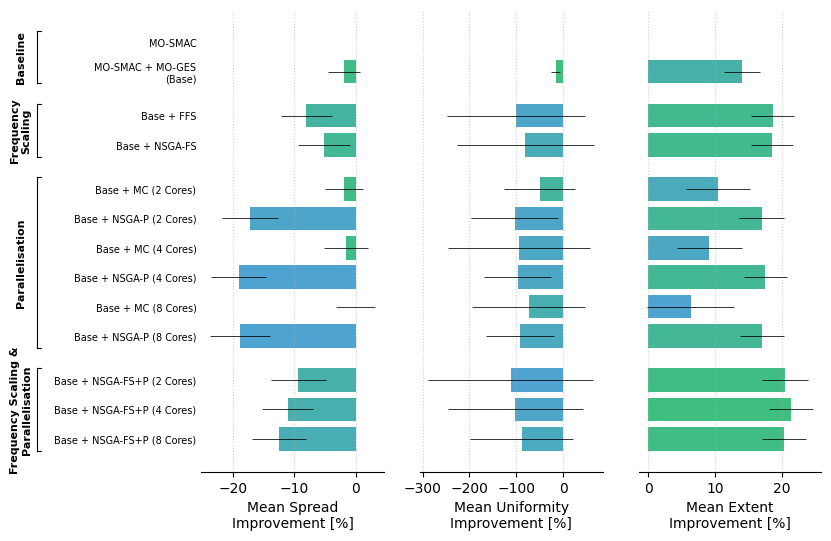

In [ ]:
plot_combined2(metric_names=["spread", "uniformity", "extent"], metric_renames=["Mean Spread\nImprovement [%]", "Mean Uniformity\nImprovement [%]", "Mean Extent\nImprovement [%]"], save_path="./figures/combined/summary_appendix.pdf", x_offset=.9, mode="min")

In [245]:
def plot_combined3(metric_name="hv_log", ensembling_method="mo-ges", bmg = "mo-smac", metric_rename=None, save_path=None, mode="max"):
    assert mode == "max", "Only 'max' mode is supported for multiple metrics"
    
    scheduling_index = SCHEDULING_STRATEGIES.index("lpt")
    ensembling_method_idx = ENSEMBLING_METHODS.index(ensembling_method)
    allotment_method_idx_nsga2 = ALLOTMENT_STRATEGIES.index("nsga2")
    allotment_method_idx_full = ALLOTMENT_STRATEGIES.index("full")
    bmg_idx = BMG_METHODS.index(bmg)
    
    treatment_labels = []
    data_plot = []
    
    metric_indices_both = [METRICS_ORDER_BOTH.index(f"{metric_name}_{x}") for x in ["bmp", "bmp+ens", "bmp_allotment", "bmp+ens_allotment"]]
    metric_indices = [METRICS_ORDER.index(f"{metric_name}_{x}") for x in ["bmp", "bmp+ens", "bmp_allotment", "bmp+ens_allotment"]]
    
    baseline_full = results_parallel_full[:, :, bmg_idx, ensembling_method_idx, N_CORES_LIST.index(2), metric_indices].mean(axis=1)
    baseline = baseline_full[:, 0:1]
    
    # Baseline entries
    if i == 0:
        treatment_labels.append("MO-SMAC")
        treatment_labels.append("MO-SMAC + MO-GES\n(Baseline)")
    data_plot.append([0 for _ in range(len(TASK_IDS))])
    data_plot.append(baseline_full[:, 1:2] / (baseline + 1e-12) - 1)
    
    # Frequency Scaling only
    data_nsga2_fs = results_fs[:, :, bmg_idx, ensembling_method_idx, allotment_method_idx_nsga2, metric_indices]  # Shape: 104,5,4
    data_nsga2_fs = data_nsga2_fs.mean(axis=1)  # Average over seeds -> Shape: 104, 4
    data_nsga2_fs_rel = data_nsga2_fs[:, 1:] / baseline - 1
    
    data_ffs_fs = results_fs[:, :, bmg_idx, ensembling_method_idx, allotment_method_idx_full, metric_indices]  # Shape: 104,5,4
    data_ffs_fs = data_ffs_fs.mean(axis=1)  # Average over seeds -> Shape: 104, 4
    data_ffs_fs_rel = data_ffs_fs[:, 1:] / baseline - 1
        
    if i == 0:
        treatment_labels.append("Baseline + FFS")
        treatment_labels.append("Baseline + NSGA-FS")
    
    data_plot.append(data_ffs_fs_rel[:, 2])
    data_plot.append(data_nsga2_fs_rel[:, 2])
    
    # Parallelisation only
    for n_cores in N_CORES_LIST:
        n_cores_idx = N_CORES_LIST.index(n_cores)
        
        data_nsga2_p = results_parallel_nsga2[:, :, bmg_idx, ensembling_method_idx, scheduling_index, n_cores_idx, metric_indices]  # Shape: 104,5,4
        data_nsga2_p = data_nsga2_p.mean(axis=1)  # Average over seeds -> Shape: 104, 4
        data_nsga2_p_rel = data_nsga2_p[:, 1:] / baseline - 1
        
        data_full_p = results_parallel_full[:, :, bmg_idx, ensembling_method_idx, n_cores_idx, metric_indices]  # Shape: 104,5,4
        data_full_p = data_full_p.mean(axis=1)  # Average over seeds -> Shape: 104, 4
        data_full_p_rel = data_full_p[:, 1:] / baseline - 1
        
        if i == 0:
            treatment_labels.append(f"Baseline + MC ({n_cores} Cores)")
            treatment_labels.append(f"Baseline + NSGA-P ({n_cores} Cores)")
        
        data_plot.append(data_full_p_rel[:, 2])
        data_plot.append(data_nsga2_p_rel[:, 2])
        
    # Combined effects
    for n_cores in N_CORES_LIST:
        n_cores_idx = N_CORES_LIST.index(n_cores)
        
        data_nsga2_combined = results_both[:, :, bmg_idx, ensembling_method_idx, n_cores_idx, metric_indices_both]  # Shape: 104,5,4
        data_nsga2_combined = data_nsga2_combined.mean(axis=1)  # Average over seeds -> Shape: 104, 4
        data_nsga2_combined_rel = data_nsga2_combined[:, 1:] / baseline - 1
        
        if i == 0:
            treatment_labels.append(f"Baseline + NSGA-FS+P ({n_cores} Cores)")
        
        data_plot.append(data_nsga2_combined_rel[:, 2])
    
    data_arr = np.zeros((7, 4, len(TASK_IDS)))
    col_labels = [f"{n} Core{'s' if n > 1 else ''}" for n in [1] + N_CORES_LIST]
    
    data_arr[0, 0, :] = np.squeeze(data_plot[0])  # MO-SMAC
    data_arr[1, 0, :] = np.squeeze(data_plot[1])  # MO-SMAC + MO-GES
    data_arr[2, 0, :] = np.squeeze(data_plot[2])  # Baseline + FFS
    data_arr[3, 0, :] = np.squeeze(data_plot[3])  # Baseline + NSGA-FS
    data_arr[4, 1, :] = np.squeeze(data_plot[4])  # Baseline + MC (2 Cores)
    data_arr[5, 1, :] = np.squeeze(data_plot[5])  # Baseline + NSGA-P (2 Cores)
    data_arr[4, 2, :] = np.squeeze(data_plot[6])  # Baseline + MC (4 Cores)
    data_arr[5, 2, :] = np.squeeze(data_plot[7])  # Baseline + NSGA-P (4 Cores)
    data_arr[4, 3, :] = np.squeeze(data_plot[8])  # Baseline + MC (8 Cores)
    data_arr[5, 3, :] = np.squeeze(data_plot[9])  # Baseline + NSGA-P (8 Cores)
    data_arr[6, 1, :] = np.squeeze(data_plot[10])  # Baseline + NSGA-FS+P (2 Cores)
    data_arr[6, 2, :] = np.squeeze(data_plot[11])  # Baseline + NSGA-FS+P (4 Cores)
    data_arr[6, 3, :] = np.squeeze(data_plot[12])  # Baseline + NSGA-FS+P (8 Cores)
    
    groups_dict = {
        "Baseline": ["MO-SMAC", "MO-SMAC + MO-GES\n(Base)"],
        "Frequency\nScaling": ["Baseline + FFS", "Baseline + NSGA-FS"],
        "Parallelisation" : [
            "Baseline + MC", "Baseline + NSGA-P"
        ],
        "FS + P": [
            "Baseline + NSGA-FS+P"
        ],
    }
            
    plot_bars(col_labels, data_arr, groups_dict, save_path=save_path, figsize=(8,6), x_offset=1, equal_x_limits=True)

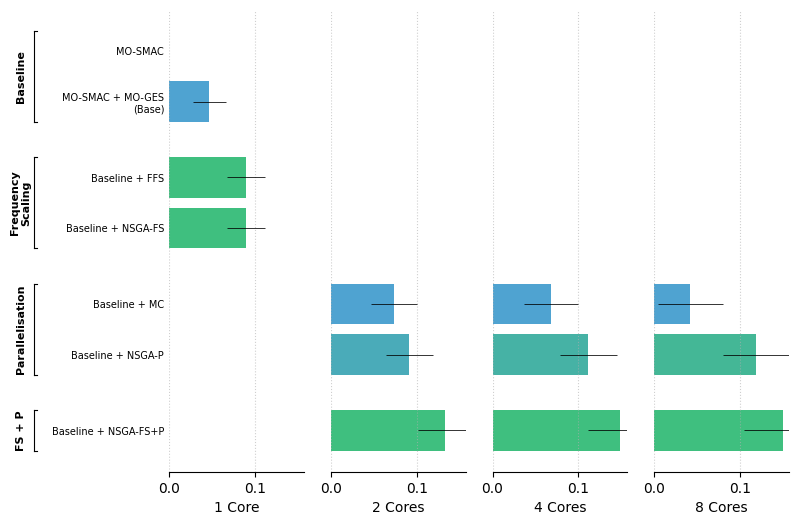

In [236]:
plot_combined3(metric_name="hv_log", metric_rename="Mean Hypervolume\nImprovement (%)", save_path="./figures/combined/summary_hv_log_new.pdf")

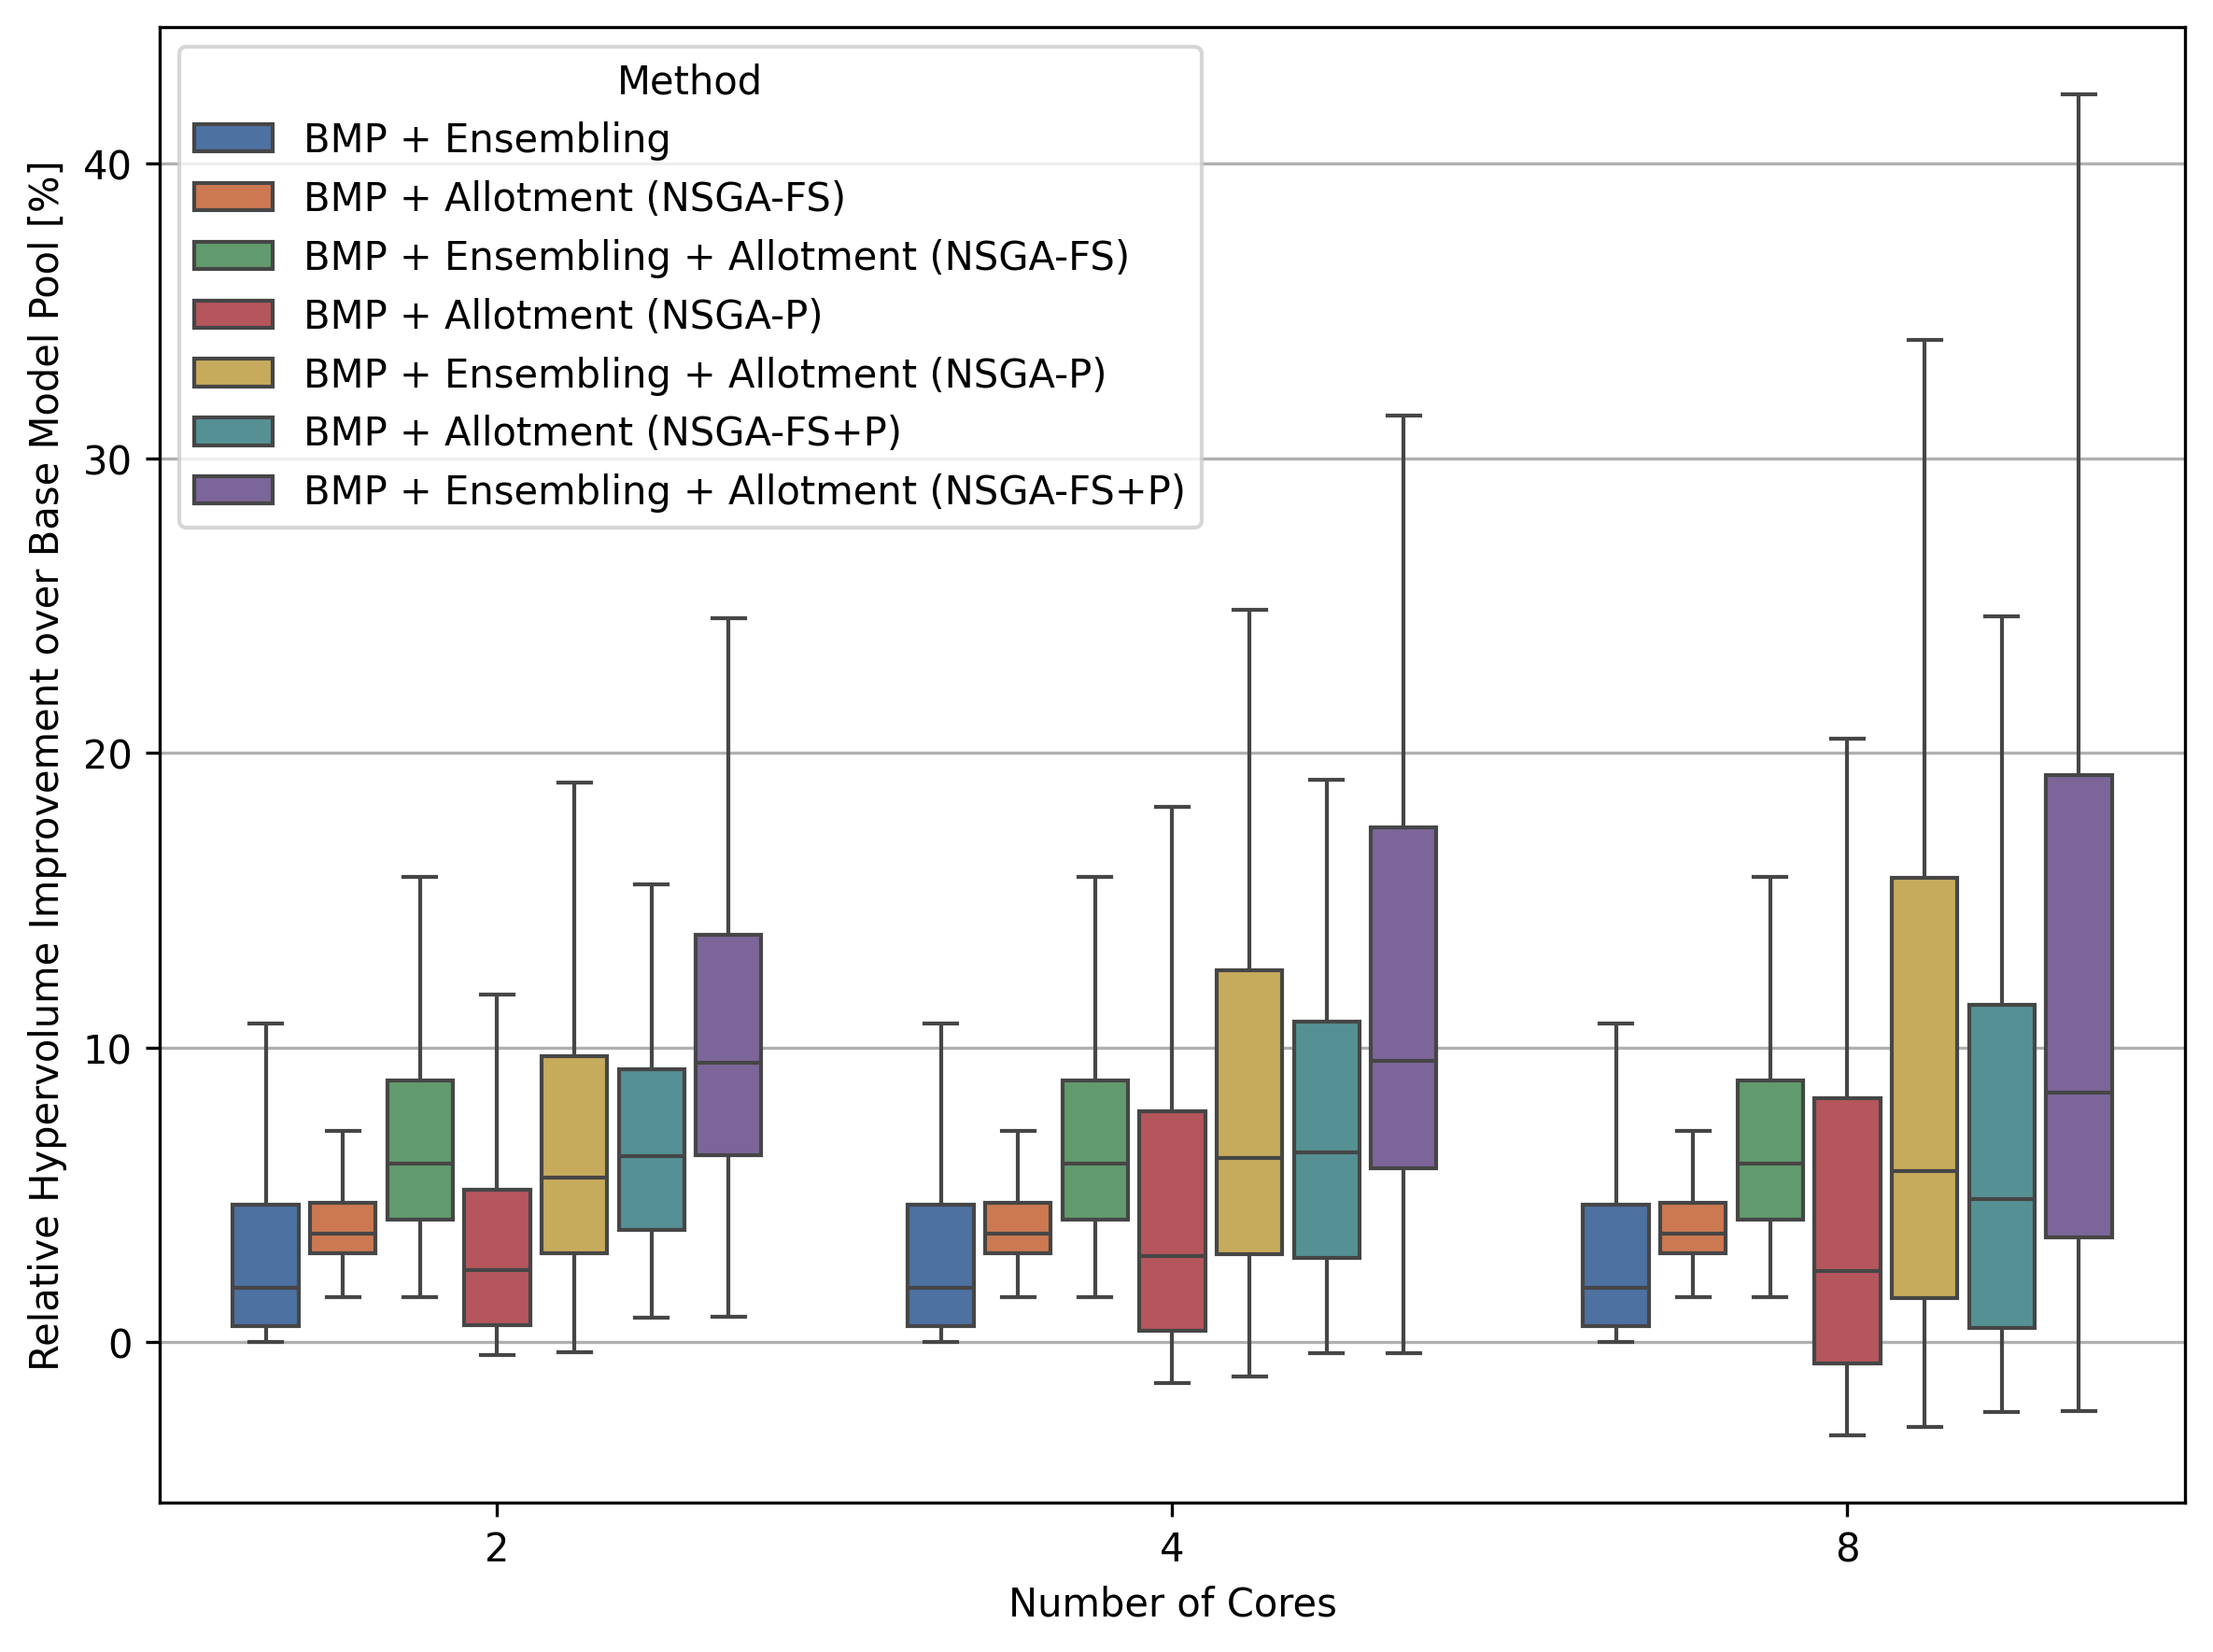

In [55]:
plot_combined("hv_log", ensembling_method="mo-ges", bmg="mo-smac", metric_rename="Hypervolume", save_path="./figures/combined/fs+parallel_allot_hv.pdf")

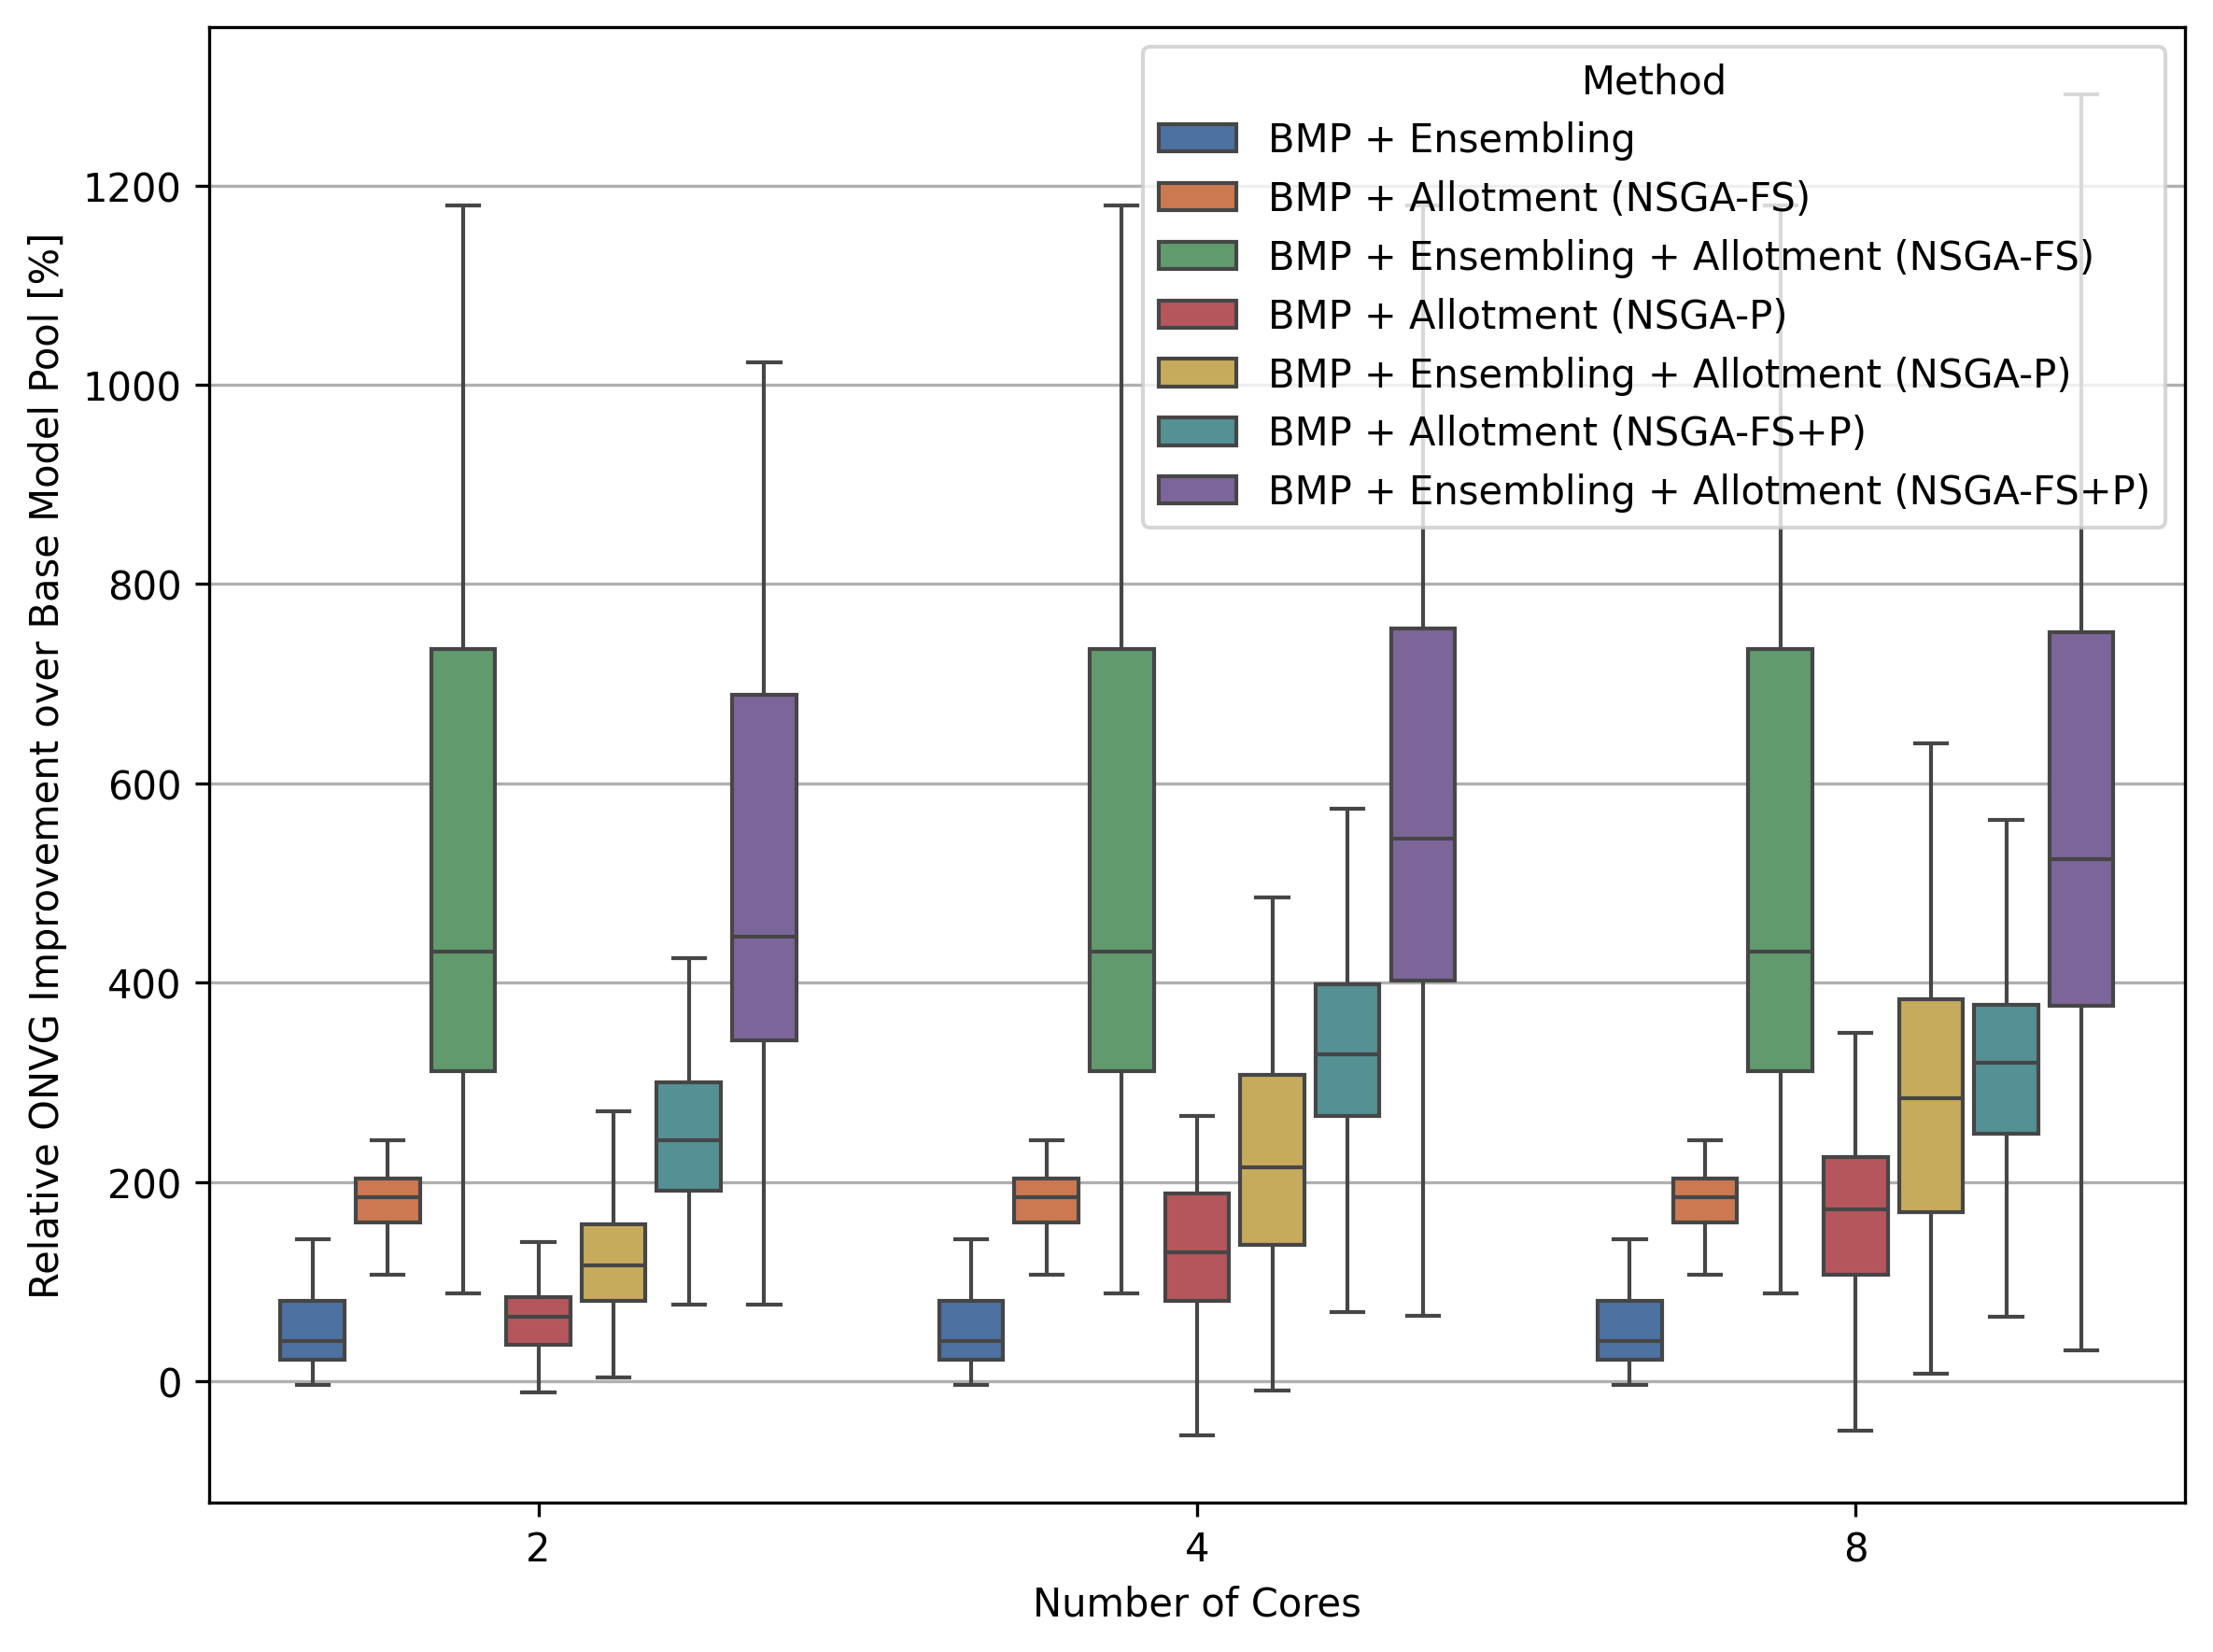

In [56]:
plot_combined("onvg", ensembling_method="mo-ges", bmg="mo-smac", metric_rename="ONVG", save_path="./figures/combined/fs+parallel_allot_onvg.pdf")

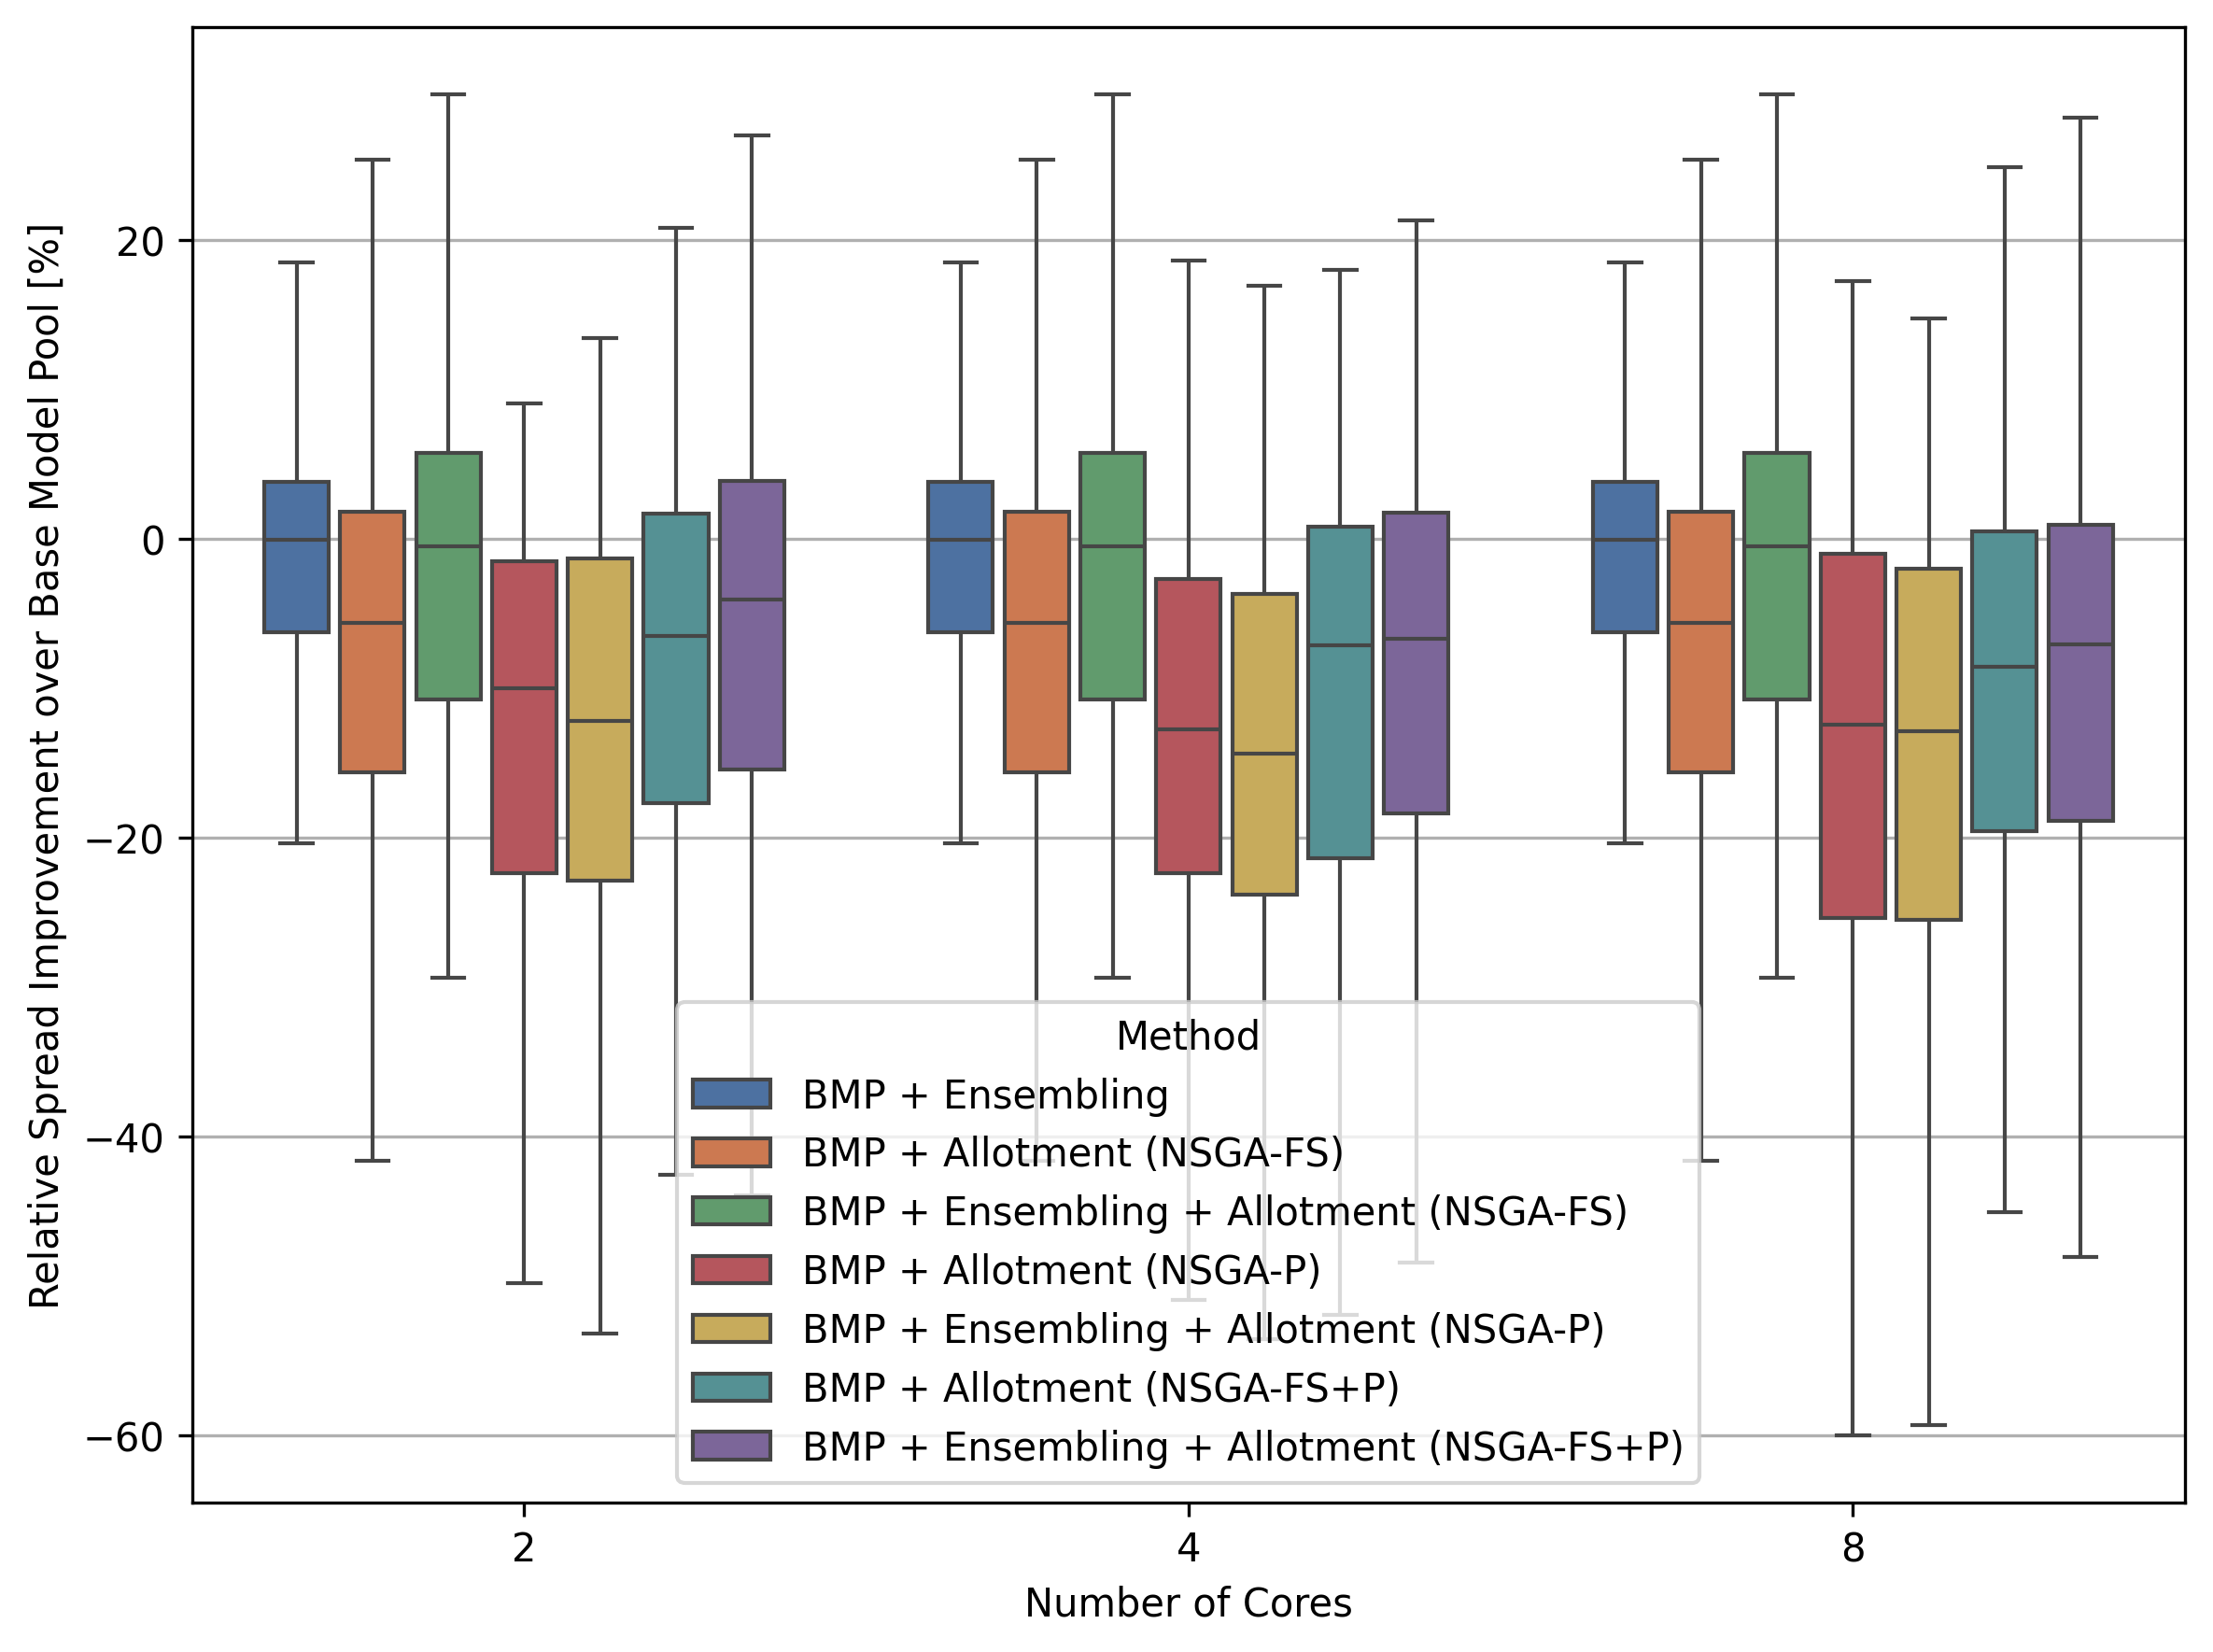

In [57]:
plot_combined("spread", ensembling_method="mo-ges", bmg="mo-smac", mode="min", save_path="./figures/combined/fs+parallel_allot_spread.pdf")

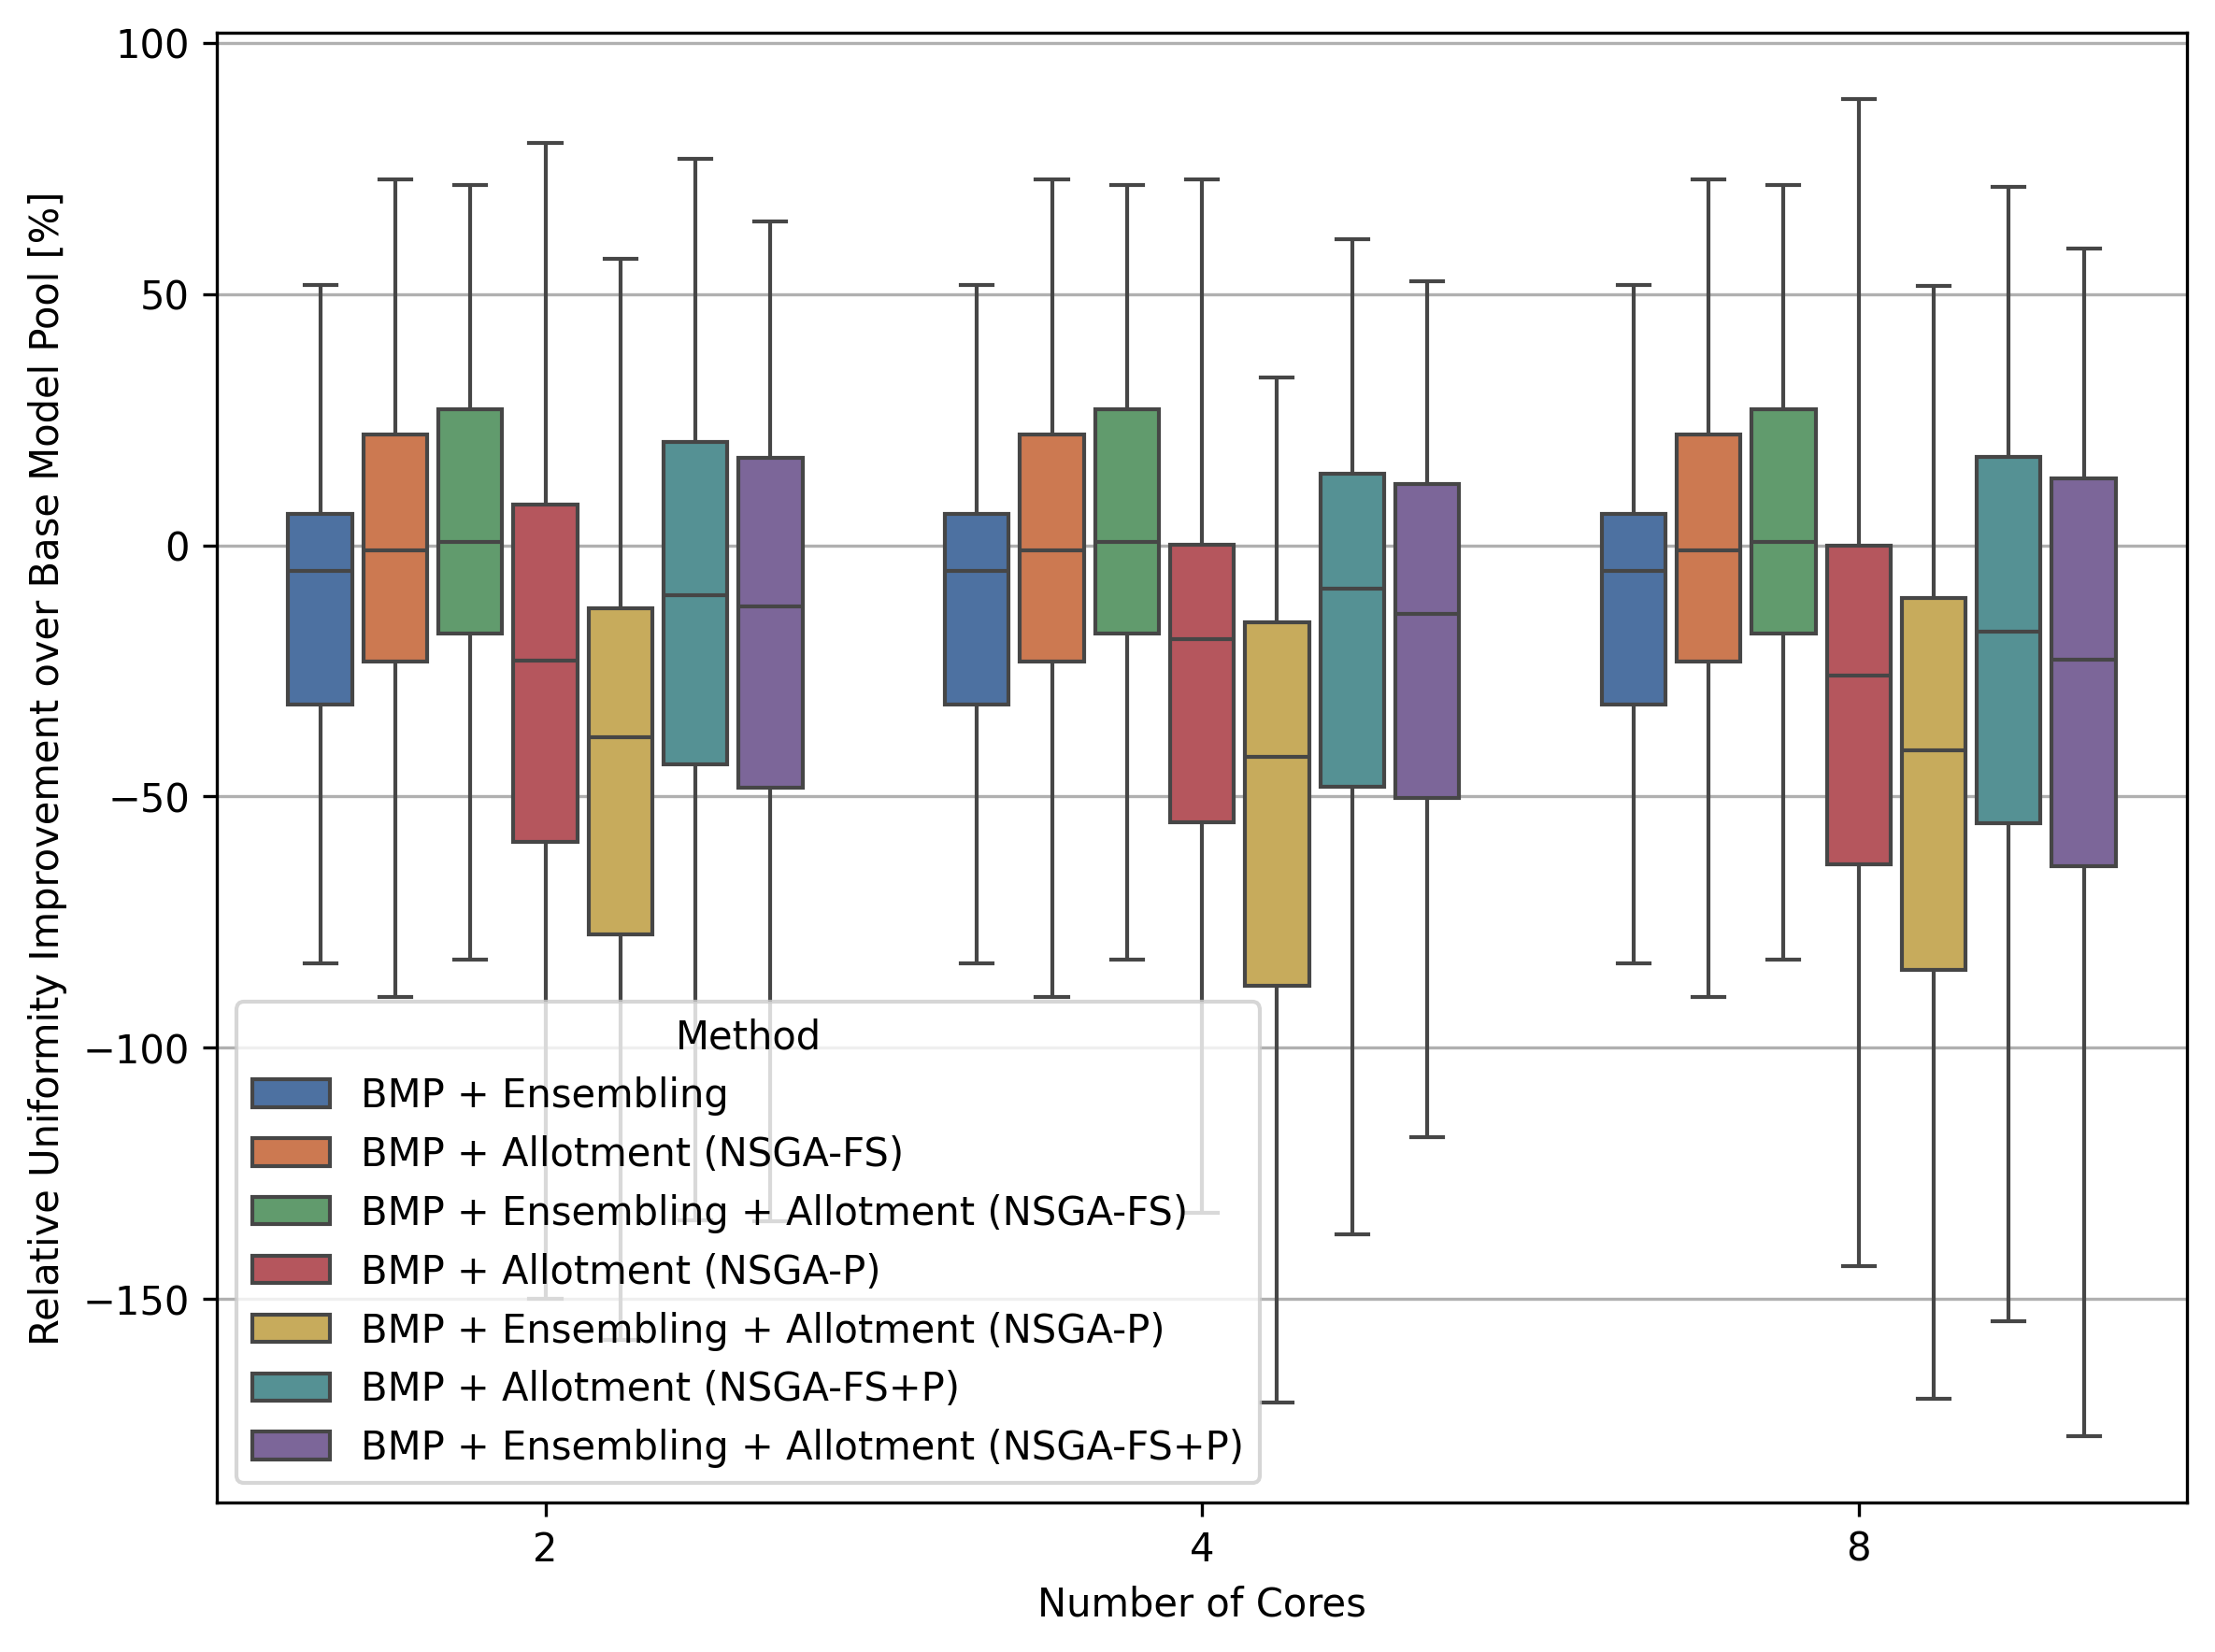

In [58]:
plot_combined("uniformity", ensembling_method="mo-ges", bmg="mo-smac", mode="min", save_path="./figures/combined/fs+parallel_allot_uniformity.pdf")

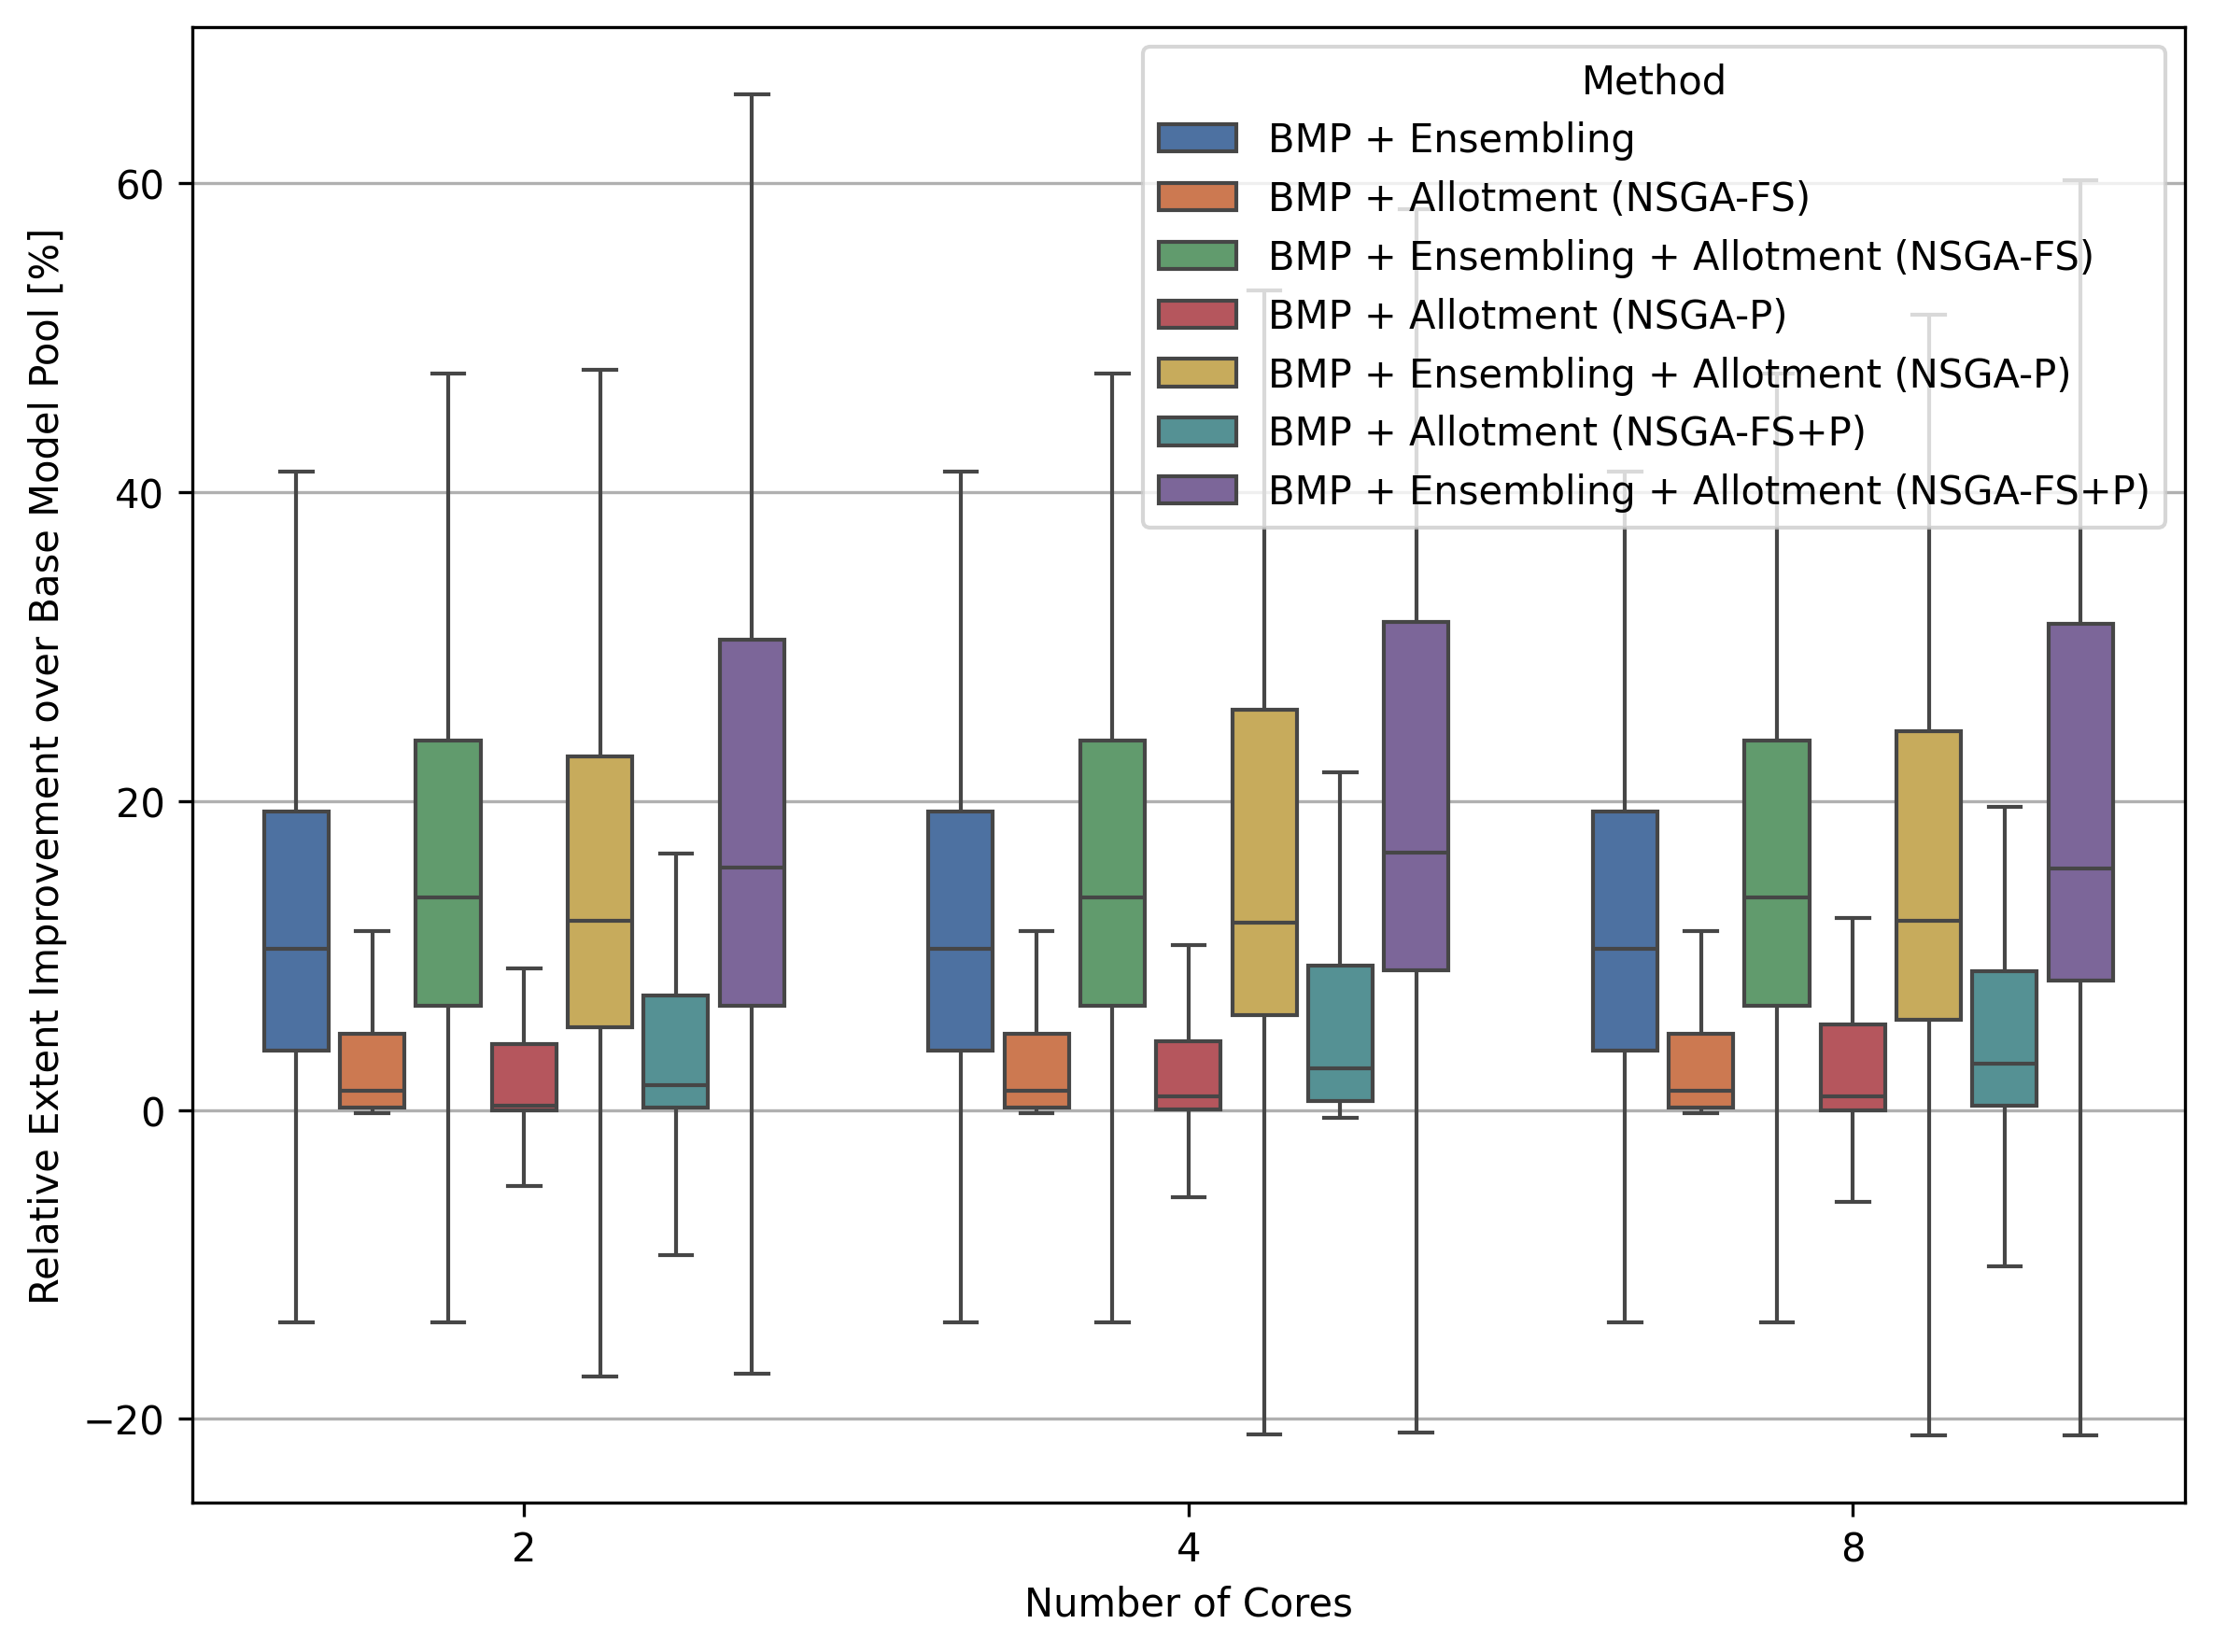

In [59]:
plot_combined("extent", ensembling_method="mo-ges", bmg="mo-smac",mode="min", save_path="./figures/combined/fs+parallel_allot_extent.pdf")

In [60]:
def plot_runtime(ensembling_method="mo-ges", bmg = "mo-smac", task_ids=None, relative=False, save_path=None):
    metric_indices = [METRICS_ORDER_BOTH.index(x) for x in ["runtime_ensembling", "runtime_bmp_allotment", "runtime_ens_allotment", "runtime_est_bmp_allotment_pf", "runtime_est_ens_allotment_pf"]]
    ensembling_method_idx = ENSEMBLING_METHODS.index(ensembling_method)
    bmg_idx = BMG_METHODS.index(bmg)
    
    group_member_labels = [
        "Allotment BMP (NSGA-FS+P)", "Allotment BMP + EP (NSGA-FS+P)",
        "Allotment BMP PF (NSGA-FS+P)", "Allotment BMP + EP PF (NSGA-FS+P)",
    ]
    
    group_data = []
    for n_cores in N_CORES_LIST:
        n_cores_idx = N_CORES_LIST.index(n_cores)
        
        data_nsga2_combined = results_both[:, :, bmg_idx, ensembling_method_idx, n_cores_idx, metric_indices]
        if task_ids is not None:
            task_id_indices = [TASK_IDS.index(tid) for tid in task_ids]
            data_nsga2_combined = data_nsga2_combined[task_id_indices, :, :]
        data_nsga2_combined = data_nsga2_combined.mean(axis=1)  # Average over seeds -> Shape: 104, 5
        results = np.zeros((data_nsga2_combined.shape[0], data_nsga2_combined.shape[1]))
        results[:, :data_nsga2_combined.shape[1]] = data_nsga2_combined
        results[:, 2] = data_nsga2_combined[:, 2] + data_nsga2_combined[:, 1]
        results[:, 4] = data_nsga2_combined[:, 4] + data_nsga2_combined[:, 3]
        
        if relative:
            results = results[:, 1:] / (results[:, 0:1] + 1e-12)
        else:
            results = results[:, 1:]
        
        for key, vals in zip(group_member_labels, results.T):
            for val in vals:
                group_data.append({
                    "Number of Cores": n_cores,
                    "Method": key,
                    "Runtime": val * (100 if relative else 1)
                })
    
    df = pd.DataFrame(group_data)
    df = df[df["Method"].isin(group_member_labels)]
            
    fig, ax = plt.subplots(figsize=(8, 6), dpi=DPI)
    sns.boxplot(
        data=df,
        x="Number of Cores",
        y="Runtime",
        hue="Method",
        palette=COLOR_LIST[:len(group_member_labels)],
        ax=ax,
        showfliers=True,
        gap=0.15
    )       
    
    # Print max values per method
    for method in group_member_labels:
        max_runtime = df[df["Method"] == method]["Runtime"].max()
        print(f"Max runtime for {method}: {max_runtime:.2f} {'%' if relative else 's'}")
    
    #ax.axhline(y=1.0, color='red', linestyle='--', label='Base Ensembling Runtime')
    #ax.grid(axis='y')
    ax.set_xlabel("Number of Cores")
    ax.set_yscale("log")
    if relative:
        ax.set_ylabel("Running Time Relative to Ensembling Running Time [%]")
    else:
        ax.set_ylabel("Running Time [s]")
    ax.grid(axis='y')
    #ax.set_ylabel(f"Relative {METRIC_MAP[metric_name] if metric_rename is None else metric_rename} Improvement over Base Model Pool [%]")
    ax.legend(title="Method")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=DPI, bbox_inches='tight')
    else:
        plt.show()

Max runtime for Allotment BMP (NSGA-FS+P): 3732.54 s
Max runtime for Allotment BMP + EP (NSGA-FS+P): 4192.57 s
Max runtime for Allotment BMP PF (NSGA-FS+P): 83.60 s
Max runtime for Allotment BMP + EP PF (NSGA-FS+P): 146.65 s


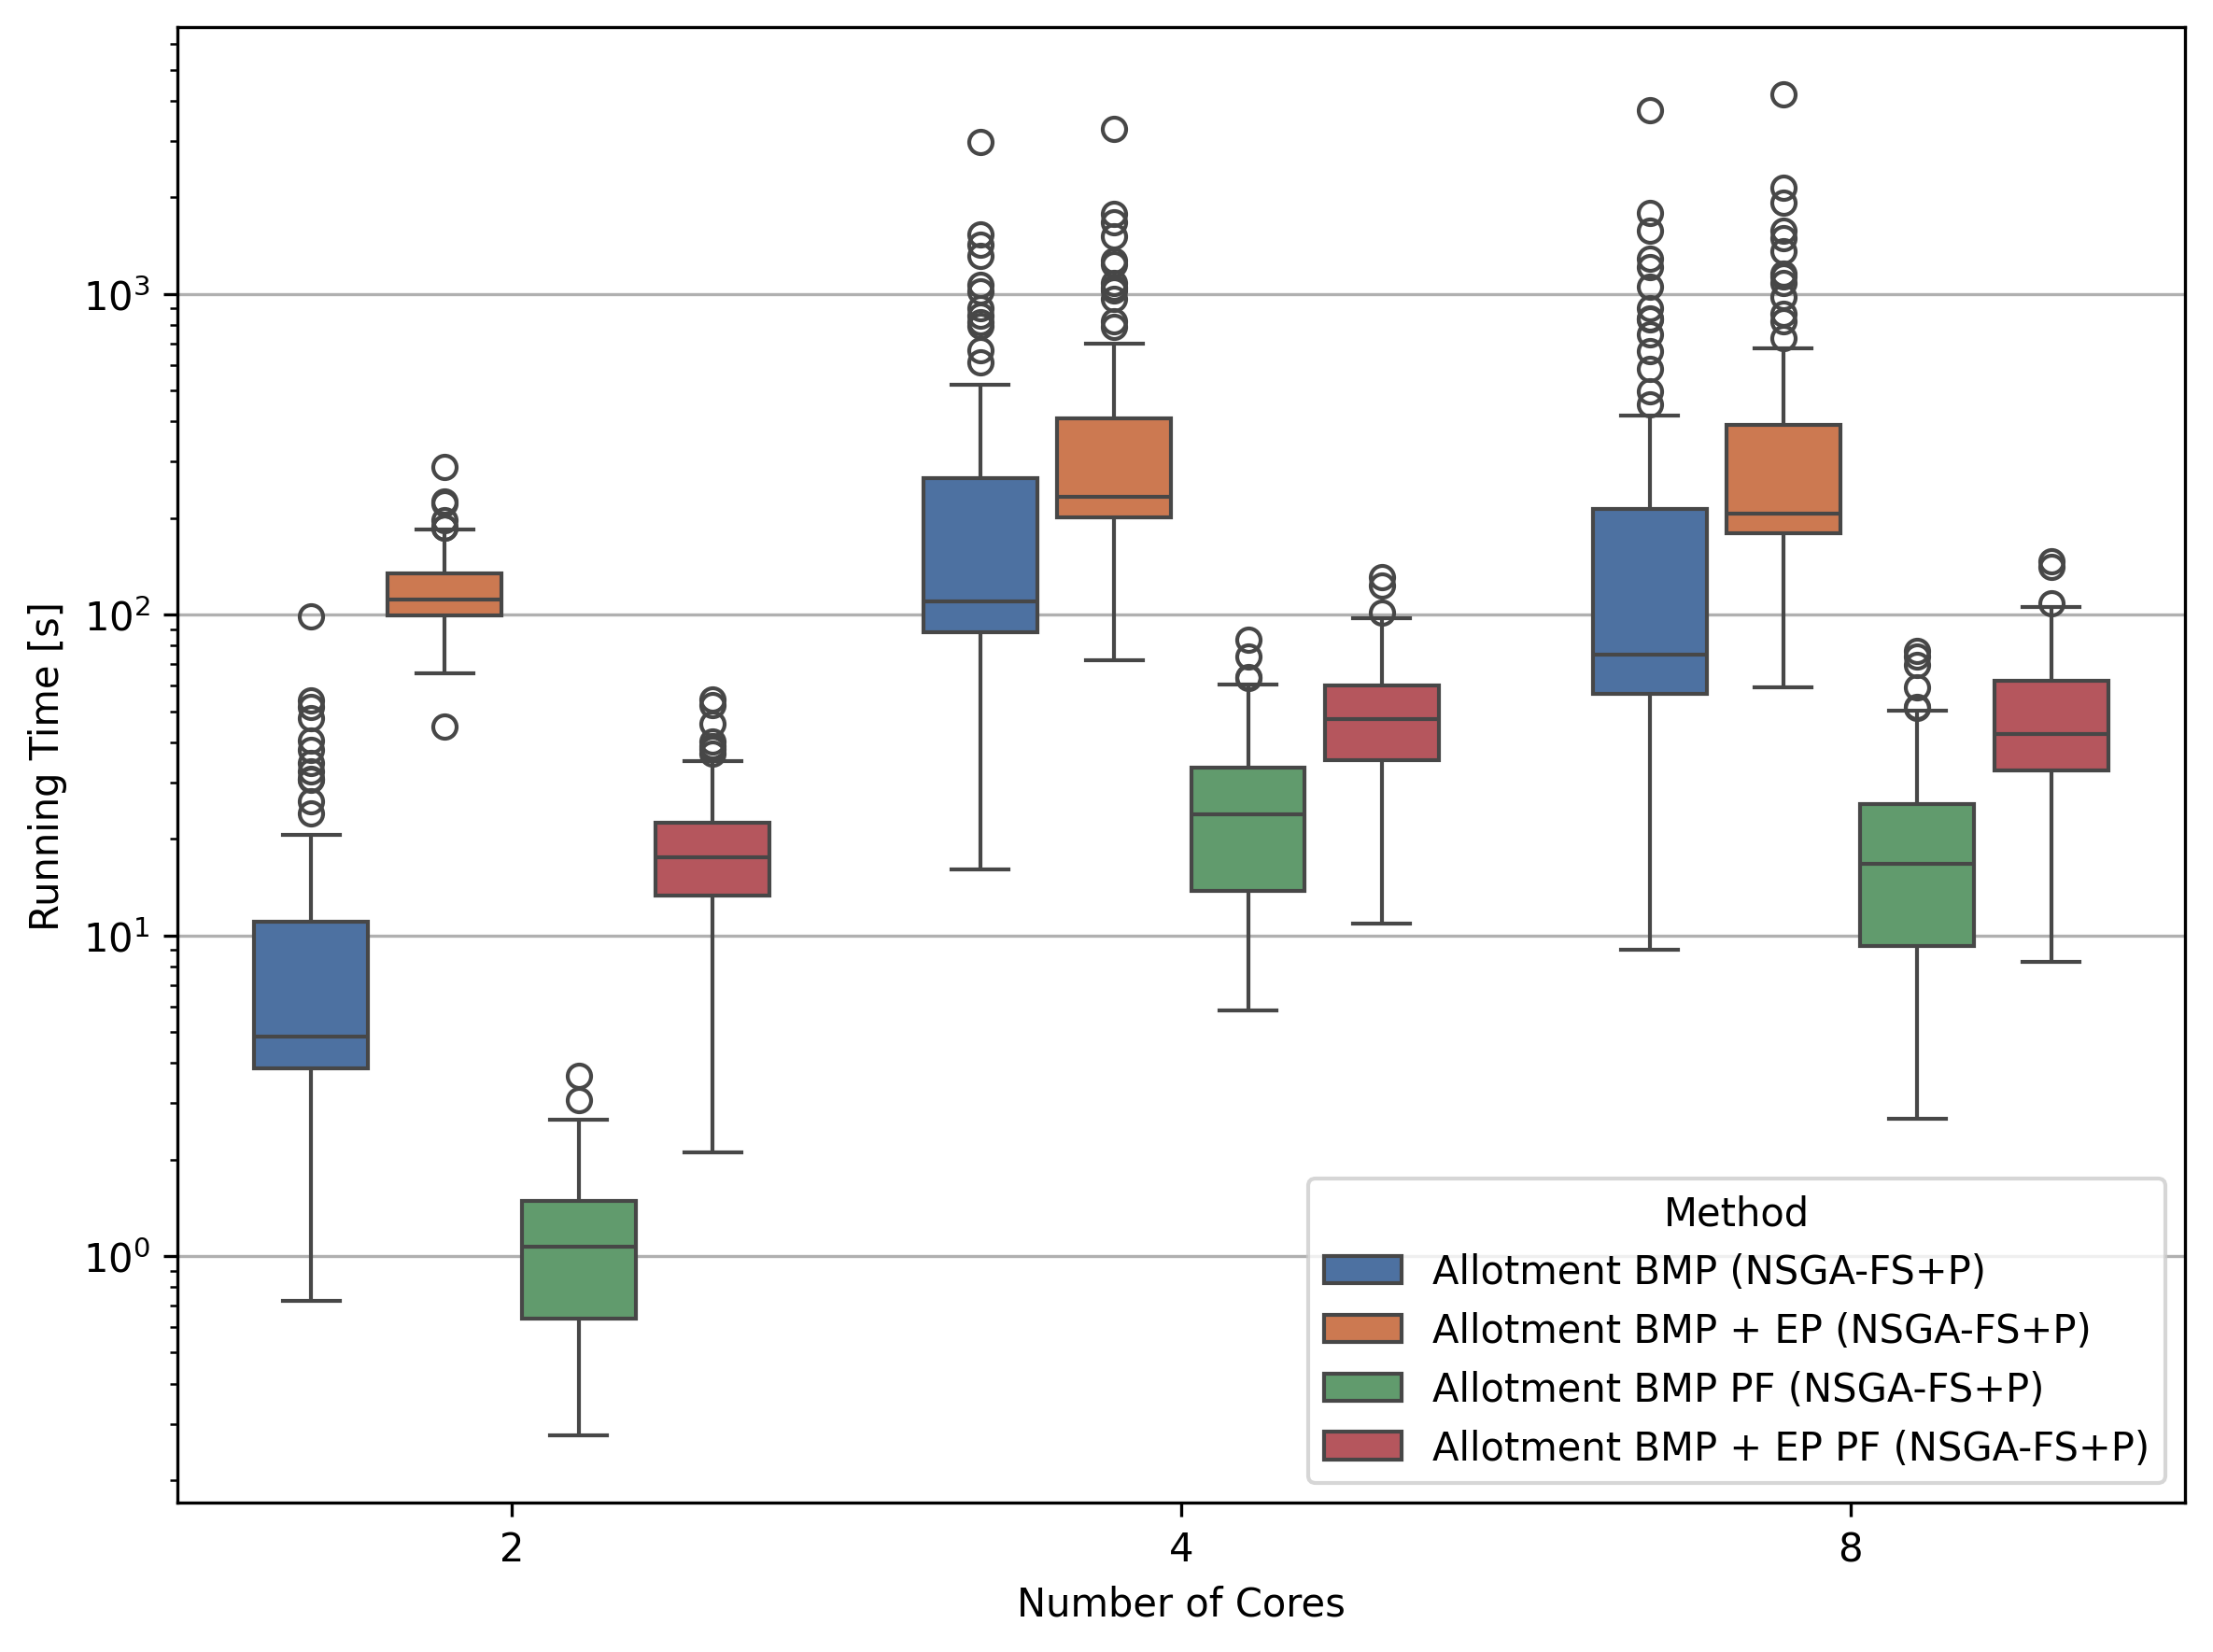

In [61]:
plot_runtime(ensembling_method="mo-ges", bmg="mo-smac", save_path="./figures/combined/fs+parallel_allot_runtime.pdf")

Plotting runtimes for group: regression with task IDs: [167210, 233211, 233212, 233213, 233214, 233215, 317614, 359929, 359930, 359931, 359932, 359933, 359934, 359935, 359936, 359937, 359938, 359939, 359940, 359941, 359942, 359943, 359944, 359945, 359946, 359948, 359949, 359950, 359951, 359952, 360932, 360933, 360945]
Max runtime for Allotment BMP (NSGA-FS+P): 1785.35 s
Max runtime for Allotment BMP + EP (NSGA-FS+P): 2149.04 s
Max runtime for Allotment BMP PF (NSGA-FS+P): 83.60 s
Max runtime for Allotment BMP + EP PF (NSGA-FS+P): 141.29 s


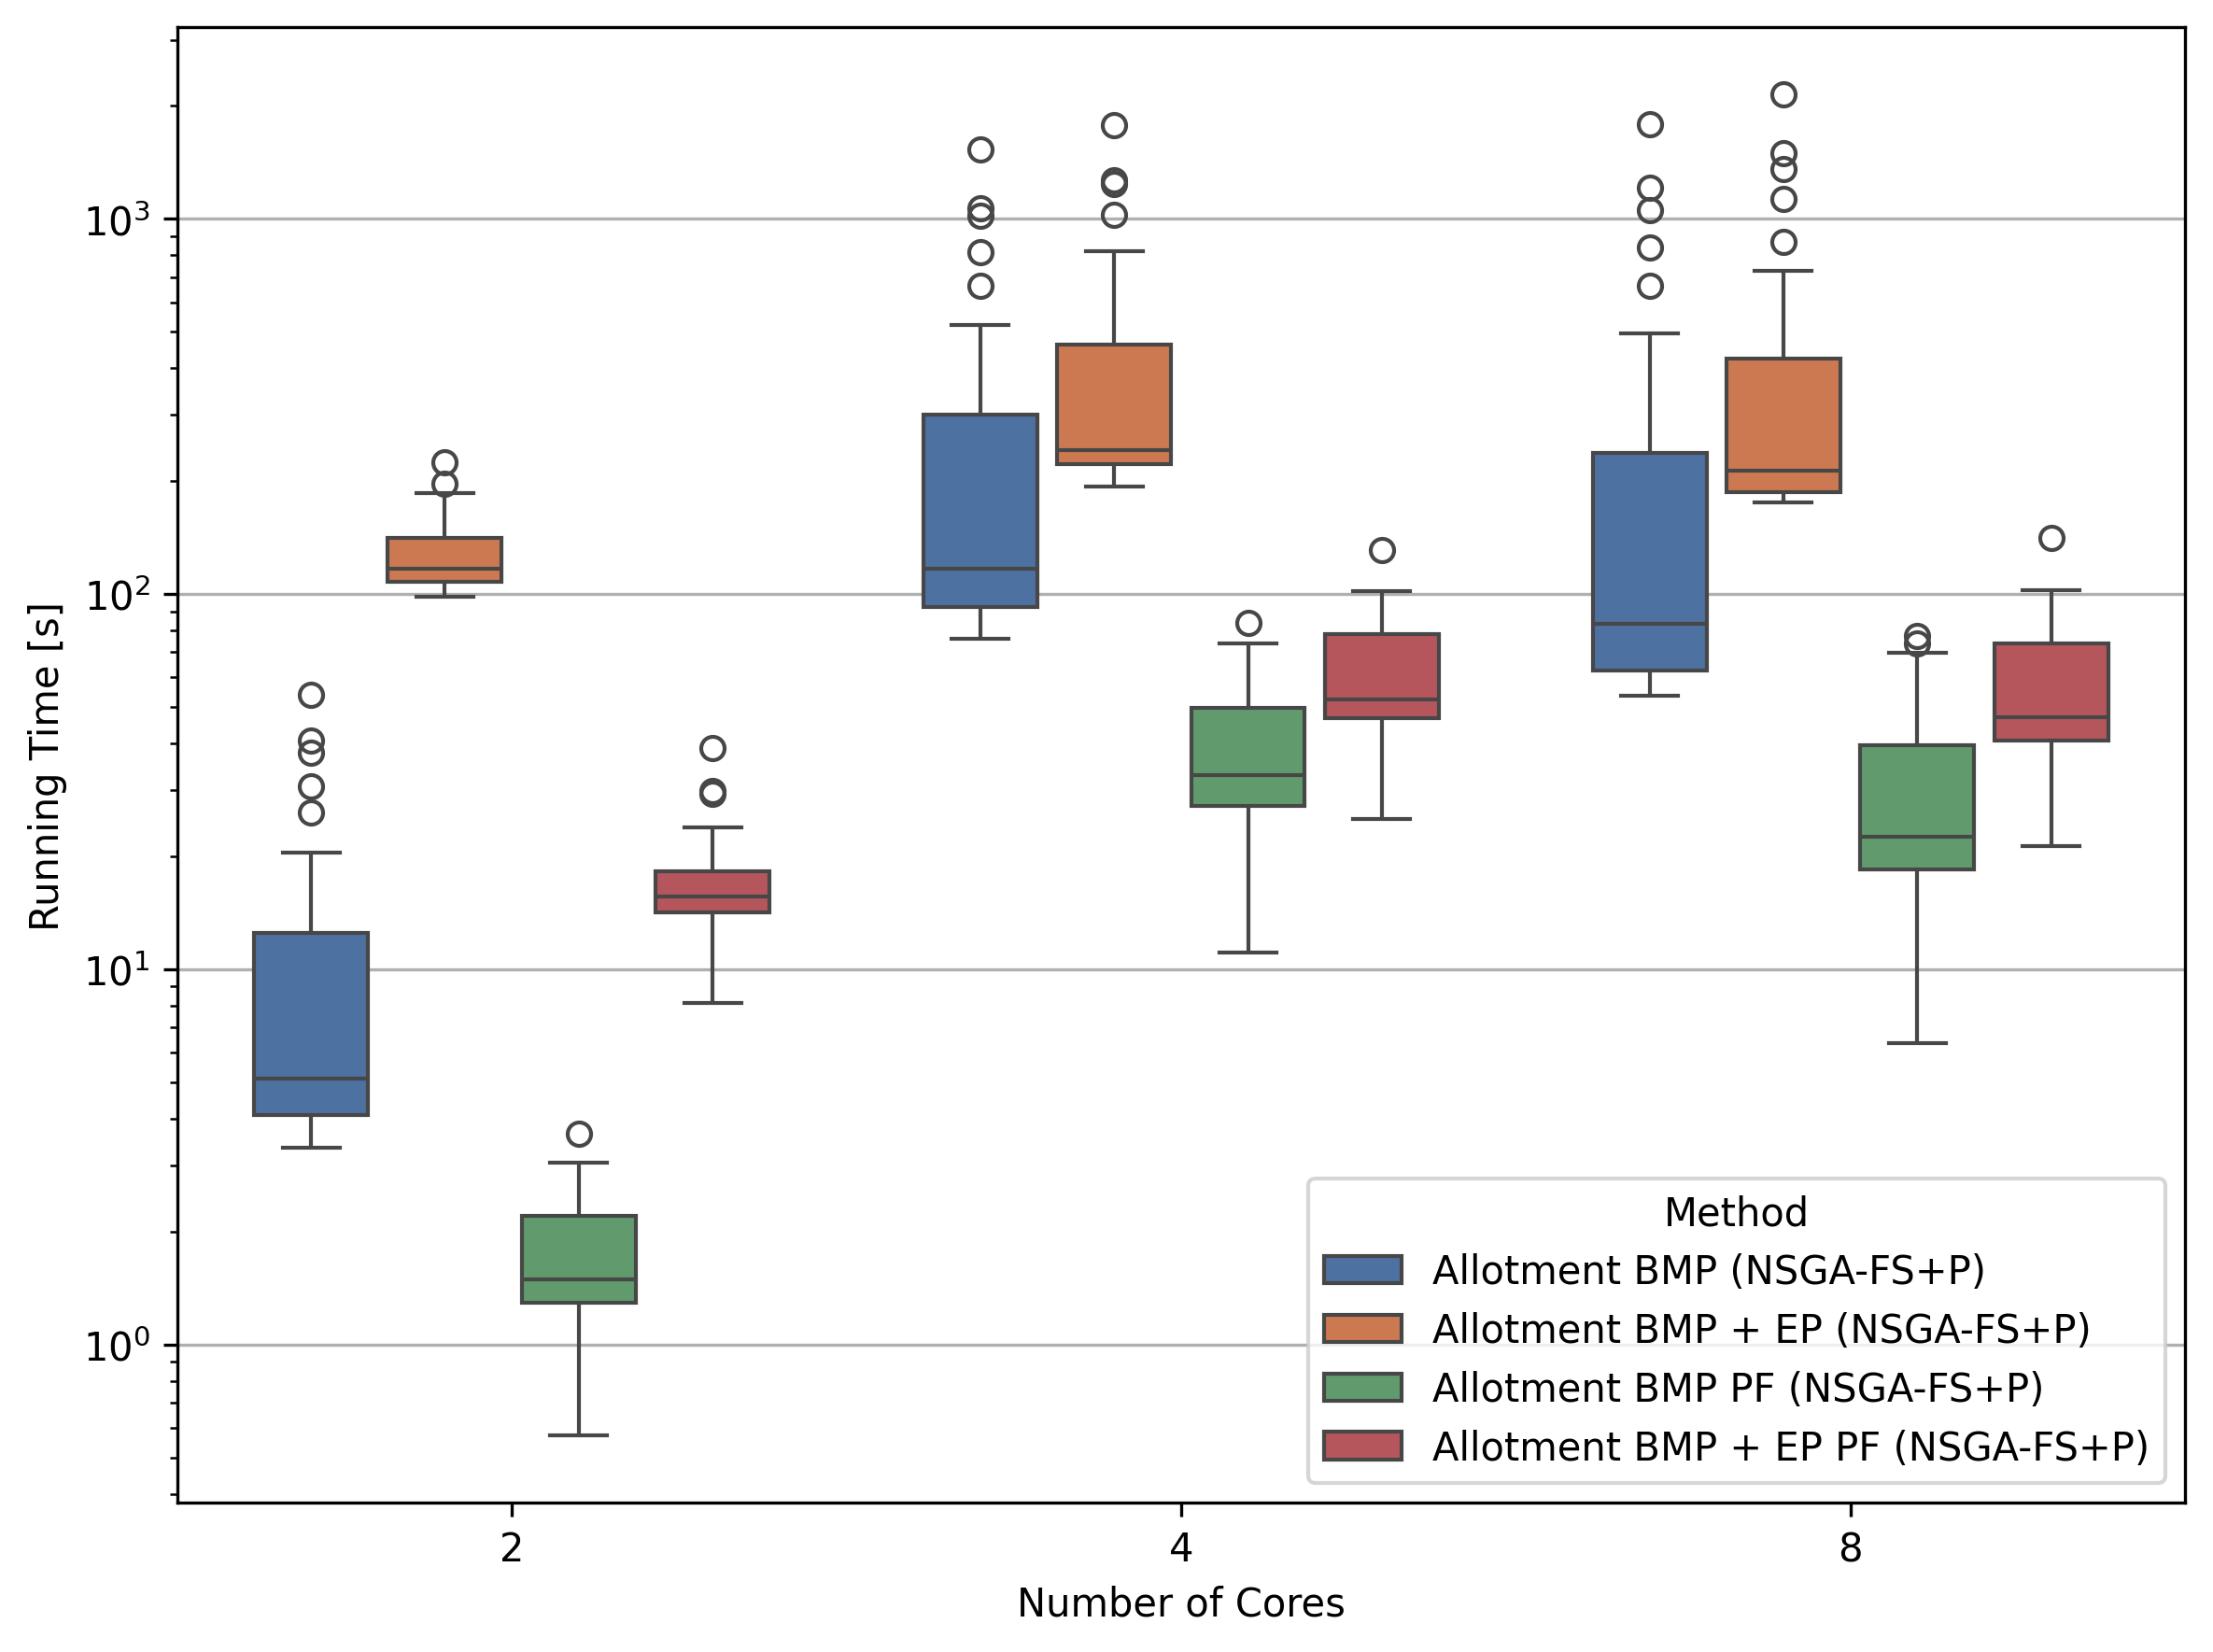

Plotting runtimes for group: binary with task IDs: [3945, 146818, 146820, 167120, 168350, 168757, 168868, 168911, 189354, 189356, 189922, 190137, 190392, 190410, 190411, 190412, 359955, 359956, 359958, 359962, 359965, 359966, 359967, 359968, 359971, 359972, 359973, 359975, 359979, 359980, 359982, 359983, 359988, 359989, 359990, 359991, 359992, 359994, 360113, 360114, 360975]
Max runtime for Allotment BMP (NSGA-FS+P): 3732.54 s
Max runtime for Allotment BMP + EP (NSGA-FS+P): 4192.57 s
Max runtime for Allotment BMP PF (NSGA-FS+P): 59.41 s
Max runtime for Allotment BMP + EP PF (NSGA-FS+P): 105.65 s


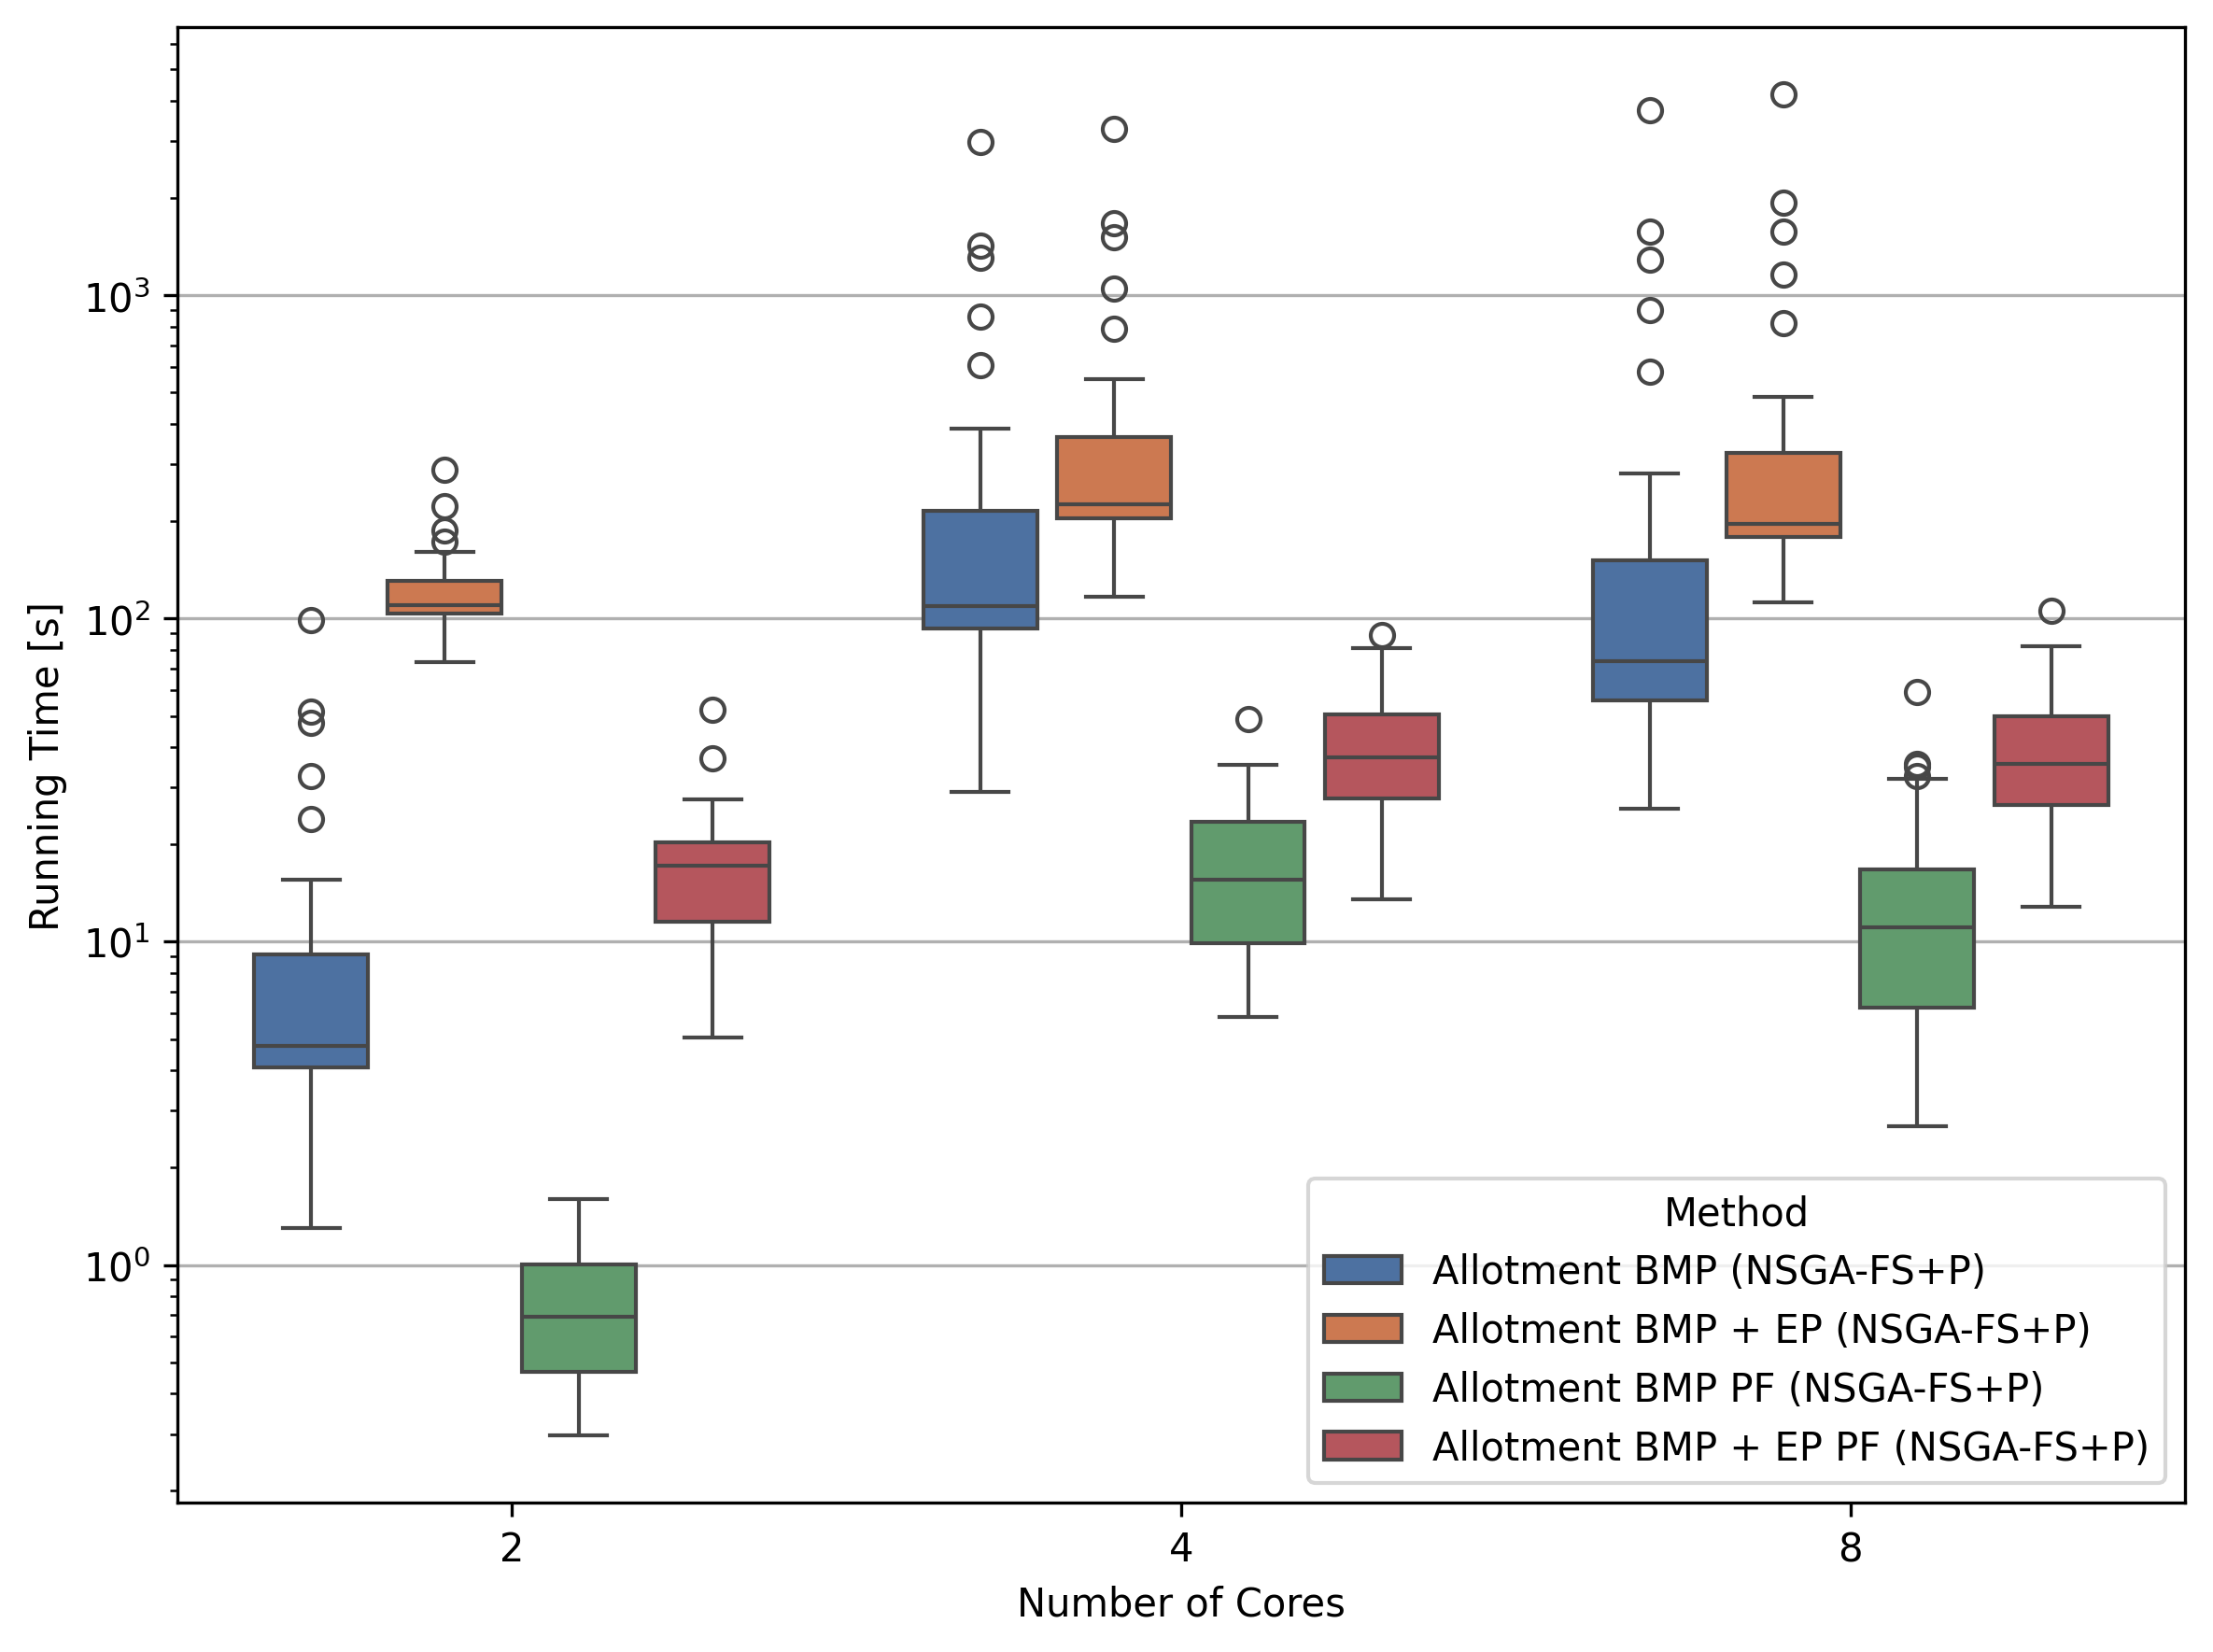

Plotting runtimes for group: multiclass with task IDs: [2073, 7593, 10090, 168784, 168909, 168910, 189355, 190146, 211979, 211986, 359953, 359954, 359957, 359959, 359960, 359961, 359963, 359964, 359969, 359970, 359974, 359976, 359977, 359981, 359984, 359985, 359986, 359987, 359993, 360112]
Max runtime for Allotment BMP (NSGA-FS+P): 904.85 s
Max runtime for Allotment BMP + EP (NSGA-FS+P): 1083.03 s
Max runtime for Allotment BMP PF (NSGA-FS+P): 53.45 s
Max runtime for Allotment BMP + EP PF (NSGA-FS+P): 146.65 s


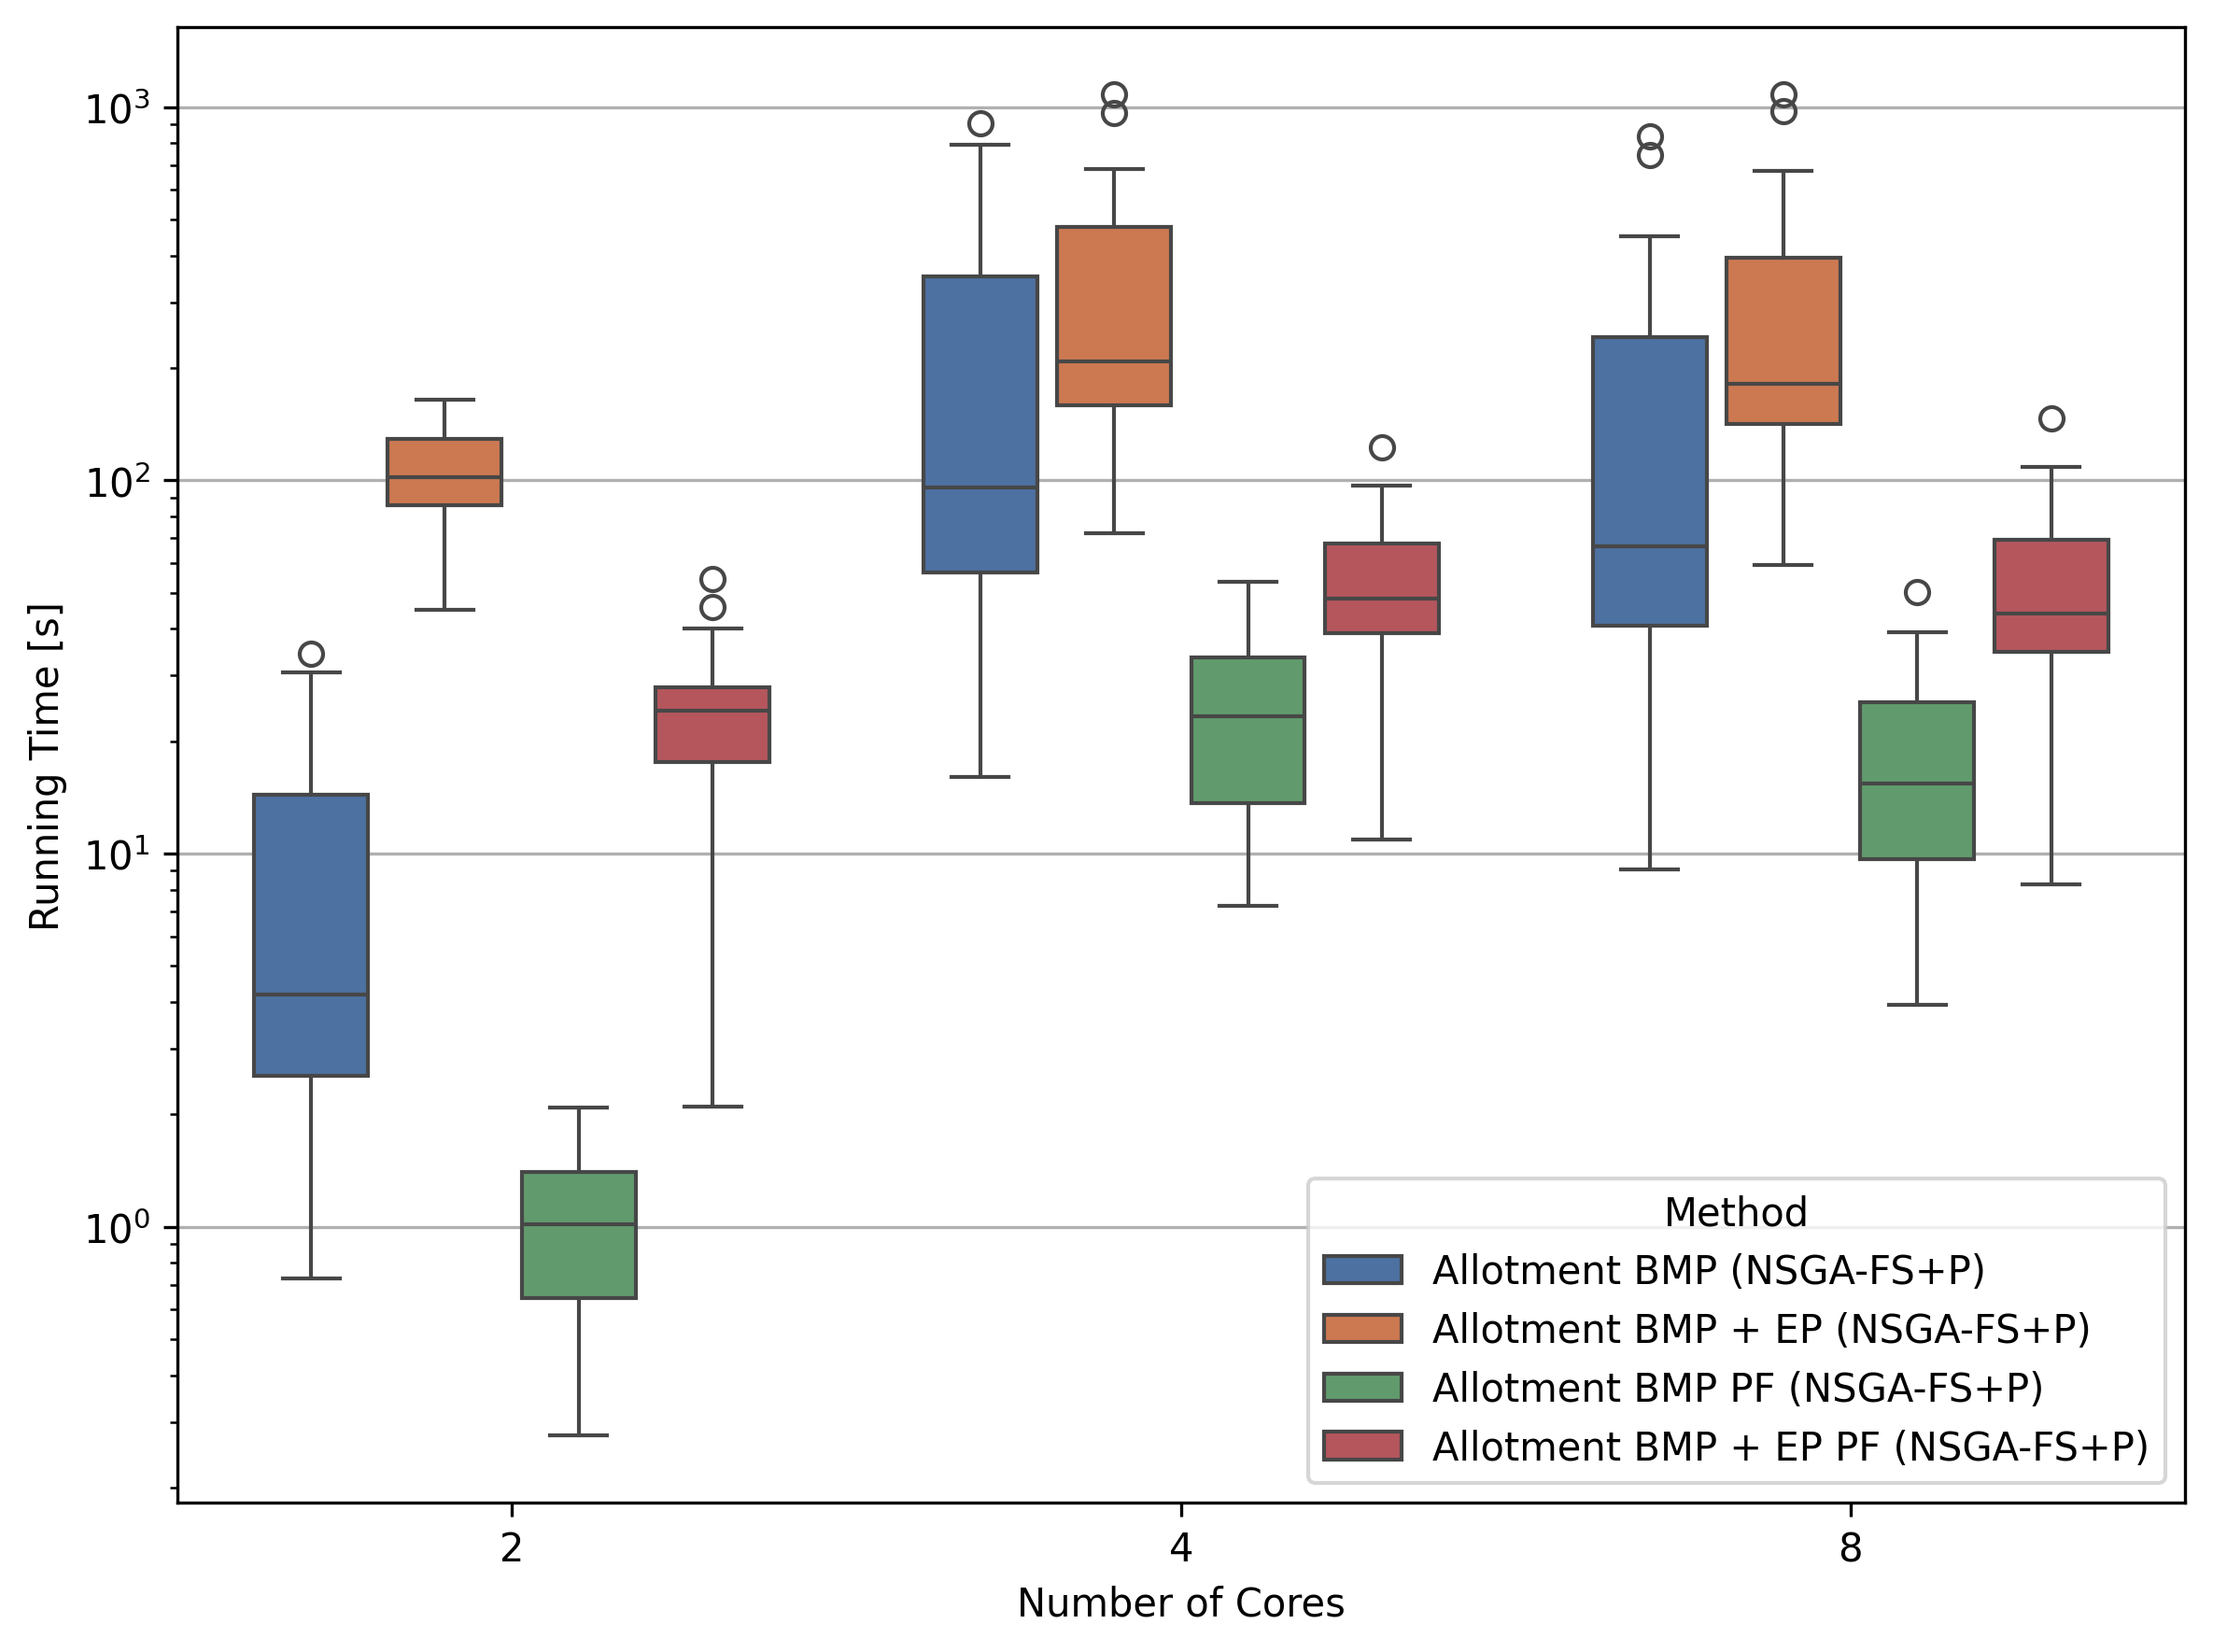

In [62]:
for group in ["regression", "binary", "multiclass"]:
    task_ids = get_group_task_ids(group)
    print(f"Plotting runtimes for group: {group} with task IDs: {task_ids}")
    plot_runtime(ensembling_method="mo-ges", bmg="mo-smac", task_ids=task_ids)